## Readme
- 该版本在基础模型上增加了基于傅里叶遍历度量的条件引导
- 如果只是载入模型而不需要训练的情况下，直接执行Cell01-07+Cell10-11及其后面Cell12-14的可视化（可选）；即跳过Cell08-09.

## Cell 01 — 配置与设备/随机种子

In [8]:
# Cell 01: Config + device + seed (standalone)

import os, yaml, random
from types import SimpleNamespace
from pathlib import Path
import numpy as np
import torch

def to_ns(d):
    if isinstance(d, dict): return SimpleNamespace(**{k: to_ns(v) for k,v in d.items()})
    if isinstance(d, list): return [to_ns(x) for x in d]
    return d

def load_config(path="config/config_ergodic.yaml"):
    cfg = None
    p = Path(path)
    if p.exists():
        with open(p, "r") as f:
            cfg = yaml.safe_load(f)
    else:
        # Fallback 默认配置（独立运行）
        cfg = {
            "data": {
                "data_dir": "data/ergodic_dataset",   # 相对当前notebook目录
                "trajectory_len": 101,
                "robot_state_dim": 4,
                "distribution_dim": [32,32],
                "validation_split": 0.1,
                "num_workers": 0,
                "shuffle_dataset": True,
                "seed": 42
            },
            "training": {
                "batch_size": 64,
                "device": "cuda",
                "seed": 42
            },
            "diffusion": {
                "beta_min": 0.1,
                "beta_max": 20.0,
                "steps": 100
            },
            "normalizer": {
                "robot_state": {"mean": [0.0,0.0,0.0,0.0], "std": [1.0,1.0,1.0,1.0]}
            }
        }
    cfg = to_ns(cfg)

    # 兼容顶层常用字段
    cfg.data_dir = cfg.data.data_dir
    cfg.trajectory_len = cfg.data.trajectory_len
    cfg.robot_state_dim = cfg.data.robot_state_dim
    cfg.distribution_dim = cfg.data.distribution_dim

    # 规范化 mean/std 为 tensor
    mean = torch.as_tensor(cfg.normalizer.robot_state.mean, dtype=torch.float32)
    std  = torch.as_tensor(cfg.normalizer.robot_state.std,  dtype=torch.float32)
    std  = torch.where(std==0, torch.tensor(1.0), std)
    cfg.normalizer.robot_state.mean = mean
    cfg.normalizer.robot_state.std  = std
    return cfg

config = load_config()  # 如需自定义，改这里路径
device = torch.device(config.training.device if torch.cuda.is_available() else "cpu")

# 采样期能量引导参数（紧跟在 config = load_config() 之后）
if not hasattr(config, "sampling"):
    class _S: pass
    config.sampling = _S()
config.sampling.use_energy_guidance = True
config.sampling.fourier_Kx = 8
config.sampling.fourier_Ky = 8
config.sampling.time_discount_alpha = 2.0
config.sampling.eta_base = 0.2         # 0.1–0.3 可调
config.sampling.erg_budget = None      # 先不设预算
config.sampling.erg_gate_tau = 0.05
config.sampling.guide_scale = 1.0
print("sampling cfg:",
      {k: getattr(config.sampling, k) for k in
       ["use_energy_guidance","fourier_Kx","fourier_Ky","eta_base","erg_budget"]})

# 随机种子
seed = int(getattr(config.training, "seed", 42))
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

print("Device:", device)
print("Data dir:", config.data_dir)


sampling cfg: {'use_energy_guidance': True, 'fourier_Kx': 8, 'fourier_Ky': 8, 'eta_base': 0.2, 'erg_budget': None}
Device: cuda
Data dir: /home/songxy/code/time-optimal-ergodic-search/experiments/bias_search/ergodic_dataset


## Cell 02 — 数据集与 DataLoader
获取训练/验证 DataLoader（Dataset 已含 padding）
-改动目标：新增一个 _pack_gaussian_params 方法。
-逻辑：设定一个最大组件数 N_MAX（例如 20）。将每个样本的 GMM 参数展平并填充到这个长度。同时返回一个 mask，告诉模型哪些是真实数据，哪些是填充的 0。

In [9]:
# Cell 02: Data module (v3.5: Gamma Injection + Safe Gaussian Params)

import os, json, numpy as np, torch
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler

def as_tensor_f32(x):
    return x.to(torch.float32) if isinstance(x, torch.Tensor) else torch.as_tensor(x, dtype=torch.float32)

class ErgodicDataset(Dataset):
    def __init__(self, data_dir, transform=None, max_trajectory_len=101, use_index=True, max_gaussians=20):
        self.data_dir = data_dir
        self.transform = transform
        self.max_trajectory_len = max_trajectory_len
        self.max_gaussians = max_gaussians
        
        self.distributions_dir = os.path.join(data_dir, 'distributions')
        self.trajectories_dir  = os.path.join(data_dir, 'trajectories')
        self.data_pairs = []

        index_path = os.path.join(data_dir, 'dataset_index.json')
        
        index_loaded = False
        if use_index and os.path.exists(index_path):
            try:
                with open(index_path, 'r') as f:
                    loaded_data = json.load(f)
                if isinstance(loaded_data, list):
                    self.data_pairs = loaded_data
                    index_loaded = True
            except: pass
        
        if not index_loaded or len(self.data_pairs) == 0:
            self._build_index(index_path)
            
    def _build_index(self, index_path):
        self.data_pairs = [] 
        dist_files = [f for f in os.listdir(self.distributions_dir) if f.endswith('.json')]
        dist_id_to_file = {d: d for d in dist_files} # Simplified map
        # Build accurate map
        dist_id_to_file = {}
        for df in dist_files:
            try:
                with open(os.path.join(self.distributions_dir, df), 'r') as f:
                    d = json.load(f)
                dist_id_to_file[d['id']] = df
            except: pass

        for tf in os.listdir(self.trajectories_dir):
            if tf.endswith('.json'):
                try:
                    with open(os.path.join(self.trajectories_dir, tf), 'r') as f:
                        t = json.load(f)
                    did = t['distribution_id']
                    if did in dist_id_to_file:
                        self.data_pairs.append({
                            'distribution_file': dist_id_to_file[did],
                            'trajectory_file': tf
                        })
                except: pass
        try:
            with open(index_path, 'w') as f:
                json.dump(self.data_pairs, f)
        except: pass

    def __len__(self):
        return len(self.data_pairs)

    def _generate_distribution_grid(self, dist_data, grid_size=(32,32)):
        # (省略具体实现，保持原样以节省篇幅，请确保你保留了之前的实现)
        # ... 
        # 简写版占位，请用你之前的完整代码
        bounds = dist_data.get('bounds', [[0,3],[0,3]])
        centers = np.asarray(dist_data['params']['centers'])
        covs    = np.asarray(dist_data['params']['covs'])
        weights = np.asarray(dist_data['params']['weights'])
        n = int(dist_data['params']['n_gaussians'])
        x = np.linspace(bounds[0][0], bounds[0][1], grid_size[0])
        y = np.linspace(bounds[1][0], bounds[1][1], grid_size[1])
        X, Y = np.meshgrid(x, y)
        Z = np.zeros_like(X, dtype=np.float64)
        for i in range(n):
            cx, cy = centers[i]
            c = covs[i]
            if np.isscalar(c): sx, sy = c, c
            elif len(np.shape(c)) == 1: sx, sy = c[0], c[1]
            else: sx, sy = np.sqrt(np.diag(c))
            Z += weights[i] * np.exp(-(((X-cx)**2)/(2*sx**2 + 1e-8) + ((Y-cy)**2)/(2*sy**2 + 1e-8)))
        Z /= (Z.max() + 1e-8)
        return Z

    def _process_trajectory(self, traj_data):
        # (保持之前的实现，确保 controls 是全零)
        states = np.asarray(traj_data['states'], dtype=np.float64)
        pos = states[:, :2]
        vel = np.zeros((states.shape[0],1))
        if states.shape[1] > 3: vel = states[:, 3:4]
        elif states.shape[0] > 1: 
            dt = float(traj_data['time_step'])
            d = np.linalg.norm(np.diff(pos, axis=0), axis=1)
            vel = np.vstack([np.zeros((1,1)), (d/dt)[:,None]])
        heading = states[:, 2:3] if states.shape[1] > 2 else np.zeros((states.shape[0],1))
        rs = np.hstack([pos, heading, vel])
        
        T = self.max_trajectory_len
        controls = np.zeros((T, 2), dtype=np.float32) # 强制全零
        
        if len(rs) > T:
            idx = np.linspace(0, len(rs)-1, T).astype(int)
            rs = rs[idx]
        elif len(rs) < T:
            pad = T - len(rs)
            rs = np.vstack([rs, np.zeros((pad, rs.shape[1]))])
            
        return rs, controls, float(traj_data['time_step']), float(traj_data['total_time']), float(traj_data['ergodic_metric']), float(traj_data['gamma'])

    def _pack_gaussian_params(self, dist_data):
        # (保持之前的实现)
        n = int(dist_data['params']['n_gaussians'])
        centers = np.asarray(dist_data['params']['centers'])
        weights = np.asarray(dist_data['params']['weights'])
        covs_raw = dist_data['params']['covs']
        packed = np.zeros((self.max_gaussians, 7), dtype=np.float32)
        mask = np.zeros((self.max_gaussians), dtype=bool)
        mask[n:] = True
        for i in range(min(n, self.max_gaussians)):
            packed[i, 0:2] = centers[i]
            c = covs_raw[i]
            if np.isscalar(c): cov_mat = np.array([c, 0, 0, c])
            elif len(np.shape(c)) == 1: cov_mat = np.array([c[0], 0, 0, c[1]])
            else: cov_mat = np.asarray(c).flatten()
            if cov_mat.size == 4: packed[i, 2:6] = cov_mat
            packed[i, 6] = weights[i]
        return packed, mask

    def __getitem__(self, idx):
        pair = self.data_pairs[idx]
        with open(os.path.join(self.distributions_dir, pair['distribution_file']), 'r') as f:
            dist_data = json.load(f)
        with open(os.path.join(self.trajectories_dir, pair['trajectory_file']), 'r') as f:
            traj_data = json.load(f)

        distribution_grid = self._generate_distribution_grid(dist_data) 
        rs, controls, time_step, total_time, ergodic_metric, gamma = self._process_trajectory(traj_data)
        gmm_packed, gmm_padding_mask = self._pack_gaussian_params(dist_data)
        
        # --- 核心修复：使用 Padded 数据填充 gaussian_params ---
        # 这样即使原始数据变长，传给 DataLoader 的也是定长 Tensor
        centers_padded = as_tensor_f32(gmm_packed[:, 0:2]) 
        covs_padded    = as_tensor_f32(gmm_packed[:, 2:6])
        weights_padded = as_tensor_f32(gmm_packed[:, 6])
        n_gauss = int(dist_data['params']['n_gaussians'])
        
        sample = {
            "distribution": as_tensor_f32(distribution_grid).unsqueeze(0), 
            "robot_state": as_tensor_f32(rs[0]),
            "trajectories": as_tensor_f32(rs),
            "controls": as_tensor_f32(controls),
            "gamma": as_tensor_f32(gamma).view(1), # Gamma 注入
            
            "gaussian_packed": as_tensor_f32(gmm_packed),        
            "gaussian_padding_mask": torch.tensor(gmm_padding_mask, dtype=torch.bool), 
            
            # 这里的修改消除了 [5,2] vs [7,2] 的冲突
            "gaussian_params": {
                "n_gaussians": torch.tensor(n_gauss, dtype=torch.long), 
                "centers": centers_padded, # [20, 2]
                "covs": covs_padded,       # [20, 4]
                "weights": weights_padded  # [20]
            }
        }
        return sample

def build_loaders(data_dir, batch_size=64, max_trajectory_len=101, val_split=0.1, num_workers=0, seed=42, transform=None):
    ds = ErgodicDataset(data_dir=data_dir, transform=transform, max_trajectory_len=max_trajectory_len)
    N = len(ds); idx = list(range(N))
    split = int(np.floor(val_split * N))
    rng = np.random.RandomState(seed); rng.shuffle(idx)
    val_idx, train_idx = idx[:split], idx[split:]
    train_loader = DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(train_idx),
                              num_workers=num_workers, pin_memory=True, drop_last=False)
    val_loader   = DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(val_idx),
                              num_workers=num_workers, pin_memory=True, drop_last=False)
    return train_loader, val_loader

print("ErgodicDataset ready (v3.5: Gamma + Safe Gaussian Params).")

ErgodicDataset ready (v3.5: Gamma + Safe Gaussian Params).


## Cell 03 —  SDE 与训练/评估通用工具

In [10]:
# Cell 03: VPSDE_linear + training utilities

import math
import torch
import torch.nn as nn

class VPSDE_linear:
    def __init__(self, beta_min=0.1, beta_max=20.0):
        self._beta_min = float(beta_min)
        self._beta_max = float(beta_max)
    @property
    def T(self): return 1.0
    def marginal_prob(self, x, t):
        # x_t = exp(mean_log_coeff)*x0 + std*z
        shape = x.shape
        t = t.view(-1, *([1]*(len(shape)-1)))
        mlc = -0.25 * t**2 * (self._beta_max - self._beta_min) - 0.5*self._beta_min*t
        mean = torch.exp(mlc) * x
        std  = torch.sqrt(torch.clamp(1 - torch.exp(2*mlc), min=1e-6))
        return mean, std

def time_weighted_masked_mse(pred, target, gamma=4.0, eps=1e-8):
    # pred/target: [B,T,D]；仅有效时刻参与；末段权重大
    B,T,D = target.shape
    mask = (target.abs().sum(dim=-1) > eps).float()            # [B,T]
    t = torch.arange(T, device=target.device).float().view(1,T)
    w = (t / max(T-1,1))**gamma
    w = (w*mask); w = w/(w.sum(dim=1, keepdim=True)+eps)
    diff2 = ((pred-target)**2).sum(dim=-1)
    return (((diff2*w).sum(dim=1)).mean())/D

def last_valid_idx_xy(xy, eps=1e-8):
    # xy: [B,T,2] or [T,2]
    if xy.ndim == 2:
        valid = ~(xy.abs().sum(dim=-1) <= eps)
        k = torch.nonzero(valid)[-1].item() if valid.any() else xy.shape[0]-1
        return k
    valid = ~(xy.abs().sum(dim=-1) <= eps)                     # [B,T]
    idx = []
    for b in range(xy.shape[0]):
        v = valid[b]; k = torch.nonzero(v)[-1].item() if v.any() else xy.shape[1]-1
        idx.append(k)
    return torch.tensor(idx, device=xy.device, dtype=torch.long)


## Cell 04 — Encoder
-架构：
1.GMM Embedding: 用 MLP 将 [7] 维的 GMM 参数映射到 hidden_dim。
2.Robot Embedding: 用 MLP 将 [4] 维的机器人状态映射到 hidden_dim。
3.序列拼接: 将 [Robot_Token, GMM_Token_1, ..., GMM_Token_N] 拼成序列。
4.Transformer Encoder: 处理序列。关键点：不加位置编码 (Positional Encoding)，因为 GMM 组件是无序的集合（Set），这保证了置换不变性。
5.输出：取第 0 个 Token（Robot Token）的输出作为全局上下文 encoding。

In [11]:
# Cell 04: ErgodicEncoder (v4: Transformer with Gamma Conditioning)

import torch
import torch.nn as nn

class ErgodicEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.hidden_dim = int(getattr(cfg, 'hidden_dim', getattr(getattr(cfg,'model',object()),'hidden_dim',192)))
        state_dim = int(cfg.robot_state_dim)
        gmm_input_dim = 7
        
        # 1. Embeddings
        self.gmm_embedder = nn.Sequential(
            nn.Linear(gmm_input_dim, self.hidden_dim),
            nn.GELU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim)
        )
        
        self.robot_embedder = nn.Sequential(
            nn.Linear(state_dim, self.hidden_dim),
            nn.GELU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim)
        )
        
        # --- 新增：Gamma Embedder ---
        # 输入是 [B, 1] 的标量
        self.gamma_embedder = nn.Sequential(
            nn.Linear(1, self.hidden_dim),
            nn.GELU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim)
        )
        # ---------------------------
        
        # 2. Transformer Encoder (保持不变)
        encoder_layer = nn.TransformerEncoderLayer(d_model=self.hidden_dim, nhead=4, dim_feedforward=512, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.final_ln = nn.LayerNorm(self.hidden_dim)

    def forward(self, inputs):
        """
        inputs 需包含: 'robot_state', 'gaussian_packed', 'gaussian_padding_mask', 'gamma'
        """
        rs = inputs['robot_state']             # [B, 4]
        gmm_tokens = inputs['gaussian_packed'] # [B, N, 7]
        padding_mask = inputs['gaussian_padding_mask'] # [B, N]
        gamma = inputs['gamma']                # [B, 1] <-- 新增
        
        B = rs.shape[0]
        
        # 1. Embeddings
        rs_emb = self.robot_embedder(rs).unsqueeze(1)      # [B, 1, H]
        gmm_emb = self.gmm_embedder(gmm_tokens)            # [B, N, H]
        gamma_emb = self.gamma_embedder(gamma).unsqueeze(1)# [B, 1, H] <-- 新增
        
        # 2. Concat: [Robot, Gamma, GMM_1...N]
        # 序列长度增加 1
        src = torch.cat([rs_emb, gamma_emb, gmm_emb], dim=1) # [B, 2+N, H]
        
        # 3. Prepare Mask
        # Robot(0) 和 Gamma(1) 都是永远有效的 (False)
        prefix_mask = torch.zeros((B, 2), device=src.device, dtype=torch.bool)
        src_key_padding_mask = torch.cat([prefix_mask, padding_mask], dim=1) # [B, 2+N]
        
        # 4. Transformer Pass
        output = self.transformer(src, src_key_padding_mask=src_key_padding_mask)
        
        # 5. Output
        # 我们依然返回完整序列，供 Decoder Cross-Attention 使用
        # 记得也要返回新的 mask
        return {
            "encoding": output, 
            "encoding_mask": src_key_padding_mask
        }

## Cell 05 — DiT/Decoder（仅采样器保留允许的导入）

In [12]:
# Cell 05: ErgodicDecoder / DiT (Clean Version for Transformer & xt-Guidance)

import torch
import torch.nn as nn
import math
from timm.models.layers import Mlp
from models.diffusion_utils.sampling import dpm_sampler 

# --- 1. 基础组件 (保持不变) ---
class TimestepEmbedder(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.half = hidden_dim//2
        self.emb = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, t):
        freqs = torch.exp(-math.log(10000)*torch.arange(0,self.half,device=t.device)/self.half)
        x = torch.cat([torch.cos(t[:,None]*freqs[None,:]),
                       torch.sin(t[:,None]*freqs[None,:])], dim=-1)
        return self.emb(x)

# Cell 05: DiTBlock (修正版)

class DiTBlock(nn.Module):
    def __init__(self, hidden_dim, heads, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_dim)
        # Self-Attention (SA)
        self.sa = nn.MultiheadAttention(hidden_dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(hidden_dim)
        # Cross-Attention (CA)
        self.ca = nn.MultiheadAttention(hidden_dim, heads, dropout=dropout, batch_first=True)
        self.norm3 = nn.LayerNorm(hidden_dim)
        self.mlp = Mlp(in_features=hidden_dim, hidden_features=int(hidden_dim*4), act_layer=nn.GELU, drop=dropout)
        self.drop = nn.Dropout(dropout)
        
    def forward(self, x, context=None):
        # x 是轨迹 Token，形状 [B, H]
        
        # 1. Self-Attention (SA) - 轨迹 Token 自注意力
        # Query/Key/Value 都是 x 的 unsqueeze(1) 版本 [B, 1, H]
        h = self.norm1(x); h = self.sa(h.unsqueeze(1), h.unsqueeze(1), h.unsqueeze(1))[0].squeeze(1)
        x = x + self.drop(h)
        
        # 2. Cross-Attention (CA) - 轨迹 Token 查询 GMM 序列
        h = self.norm2(x); 
        
        # Query (h_q): 轨迹 Token, 形状 [B, 1, H]
        h_q = h.unsqueeze(1)
        
        # Key/Value (h_kv): GMM/Robot State 序列, 形状 [B, L_c, H]
        # --- 关键修正：移除 context 上的冗余 unsqueeze(1) ---
        h_kv = context 
        # ------------------------------------------------
        
        h = self.ca(h_q, h_kv, h_kv)[0].squeeze(1) # [B, 1, H] -> [B, H]
        
        x = x + self.drop(h)
        
        # 3. MLP
        h = self.norm3(x); h = self.mlp(h); x = x + self.drop(h)
        
        return x

class FinalLayer(nn.Module):
    def __init__(self, hidden_dim, output_dim):
        super().__init__()
        self.norm = nn.LayerNorm(hidden_dim)
        self.proj = nn.Linear(hidden_dim, output_dim)
    def forward(self, x, t_emb):
        return self.proj(self.norm(x))

class ErgodicDiT(nn.Module):
    def __init__(self, output_dim, hidden_dim, depth, heads, dropout=0.1, model_type="x_start"):
        super().__init__()
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.model_type = model_type 
        self.traj_proj = nn.Sequential(
            nn.Linear(output_dim, hidden_dim * 2), nn.GELU(), nn.Linear(hidden_dim * 2, hidden_dim)
        )
        self.t_embedder = TimestepEmbedder(hidden_dim)
        self.blocks = nn.ModuleList([DiTBlock(hidden_dim, heads, dropout=dropout) for _ in range(depth)])
        self.final = FinalLayer(hidden_dim, output_dim)

    def forward(self, x, t, context, conditions=None):
        # 1. 注入起点硬约束 (训练时通常为 None，采样时由 dpm_sampler 传入)
        if isinstance(conditions, dict) and 0 in conditions and conditions[0] is not None:
            B = x.shape[0]
            # 假设 conditions[0] 是 [B, D_robot]
            # x 是 [B, T*D]
            # 我们需要知道 D
            D = conditions[0].shape[-1]
            T = self.output_dim // D
            
            xv = x.view(B, T, D)
            # 替换起点
            xv[:, 0, :] = conditions[0].to(xv.device)
            # 展平回 x
            x = xv.view(B, self.output_dim)

        # 2. DiT 主体
        h = self.traj_proj(x)
        t_emb = self.t_embedder(t)
        h = h + t_emb
        for blk in self.blocks:
            h = blk(h, context)
        return self.final(h, t_emb)

# --- 2. 顶层 Decoder (修正版) ---
class ErgodicDecoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.T = int(getattr(config, 'trajectory_len', getattr(getattr(config,'data',object()), 'trajectory_len', 101)))
        self.D = int(getattr(config, 'robot_state_dim', getattr(getattr(config,'data',object()), 'robot_state_dim', 4)))
        
        hd = int(getattr(config, 'hidden_dim', getattr(getattr(config,'model',object()), 'hidden_dim', 192)))
        depth = int(getattr(config, 'decoder_depth', getattr(getattr(config,'model',object()), 'decoder_depth', 3)))
        heads = int(getattr(config, 'num_heads', getattr(getattr(config,'model',object()), 'num_heads', 6)))
        drop  = float(getattr(config, 'decoder_drop_path_rate', getattr(getattr(config,'model',object()), 'decoder_drop_path_rate', 0.1)))
        self.model_type = str(getattr(config, 'diffusion_model_type', getattr(getattr(config,'diffusion',object()), 'model_type', "x_start")))
        
        self.output_dim = self.T * self.D
        self.dit = ErgodicDiT(self.output_dim, hd, depth, heads, dropout=drop, model_type=self.model_type)

    def forward(self, x_t, t, context):
        """
        训练路径调用
        """
        B = x_t.shape[0]
        # --- 修正：展平输入 ---
        x_flat = x_t.view(B, -1)
        
        out_flat = self.dit(x_flat, t, context, conditions=None)
        
        # --- 修正：恢复形状 ---
        return out_flat.view(B, self.T, self.D)

    @torch.no_grad()
    def inference(self, enc_out, inputs, steps=None, **kwargs):
        # ... (inference 代码保持不变，因为它内部已经处理了 view) ...
        enc = enc_out['encoding']; B = enc.shape[0]
        x_T = torch.randn(B, self.output_dim, device=enc.device)
        other = {"context": enc}
        if isinstance(inputs, dict) and inputs.get('robot_state') is not None:
            other["conditions"] = {0: inputs['robot_state']}
        if steps is None:
            steps = int(getattr(getattr(self.config, "diffusion", object()), "steps", 50))
        x0 = dpm_sampler(
            model=self.dit,
            x_T=x_T,
            other_model_params=other,
            diffusion_steps=steps,
            **kwargs 
        )
        traj = x0.view(B, self.T, self.D)
        if isinstance(inputs, dict) and inputs.get('robot_state') is not None:
            traj[:, 0, :] = inputs['robot_state']
        return {"prediction": traj}

/home/songxy/miniconda3/envs/ergodic/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


如何彻底杜绝实例化仓库类（不使用别名）

思路：阻断和清空这几个仓库模块的导入，并在实例化前断言当前命名 ErgodicDiffusionModel 来自 Notebook（即 module == 'main'）。这既能清除已有绑定，又能防止后续误导入把名字重绑。
在你的 Notebook 中，添加并运行一个“导入隔离”单元（放在构建模型之前，建议贴近你定义完类的 Cell 06 后面）：

导入隔离与断言（一次性执行，之后实例化）

作用：从 sys.modules 清理仓库模型模块；拦截今后对这些模块的导入；并断言当前的 ErgodicDiffusionModel 来自 Notebook。
这不会引入别名，也不会影响你允许保留的 dpm_sampler 导入。


## Cell 05.5 — “Import quarantine”（导入隔离）

In [13]:
# Import quarantine: block repo model modules; ensure we use the Notebook-defined class
import sys, builtins

# 需要屏蔽的仓库模块前缀（模型/编码器/解码器/主入口）
_BLOCK = (
    "diffusion_ergodic.models.diffusion_ergodic",
    "diffusion_ergodic.models.module.encoder",
    "diffusion_ergodic.models.module.decoder",
    "diffusion_ergodic.main",
)

# 1) 清理已加载的对应模块
for m in list(sys.modules.keys()):
    if any(m == b or m.startswith(b + ".") for b in _BLOCK):
        sys.modules.pop(m, None)

# 2) 打补丁：阻止后续再次导入这些仓库模块
if not hasattr(builtins, "_orig_import_guarded"):
    builtins._orig_import_guarded = builtins.__import__
    def _guarded_import(name, globals=None, locals=None, fromlist=(), level=0):
        if any(name == b or name.startswith(b + ".") for b in _BLOCK):
            raise ImportError(f"Blocked import of repo model module: {name}. Use the Notebook-defined class instead.")
        return builtins._orig_import_guarded(name, globals, locals, fromlist, level)
    builtins.__import__ = _guarded_import

# 3) 断言：当前命名绑定的是 Notebook 中定义的类
try:
    src_mod = ErgodicDiffusionModel.__module__
    assert src_mod == "__main__", f"ErgodicDiffusionModel is from {src_mod}, not Notebook. Re-run your class Cell 06 now."
    print("Guard OK: using Notebook-defined ErgodicDiffusionModel.")
except NameError:
    print("Define ErgodicDiffusionModel in this Notebook (Cell 06) before running the guard.")


Define ErgodicDiffusionModel in this Notebook (Cell 06) before running the guard.


## Cell 06 — 顶层模型（训练路径去噪；推理起点约束；默认损失）

In [14]:
# Cell 06: Top-level Model (v5.1: Fix Inference Interface)

import torch
import torch.nn as nn

class ErgodicDiffusionModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.encoder = ErgodicEncoder(config)
        self.sde = VPSDE_linear(
            beta_min=getattr(config.diffusion, 'beta_min', 0.1),
            beta_max=getattr(config.diffusion, 'beta_max', 20.0)
        )
        self.decoder = ErgodicDecoder(config)
        self.loss_fn = time_weighted_masked_mse 
        
        # 显式设置 loss_gamma 为 0.0 (Fix Lazy Loss)
        self.loss_gamma = float(getattr(config, 'loss_gamma', 0.0))
        
        self._last_loss_dict = {}

    def _build_enc_in(self, inputs):
        enc_in = {}
        # 基础字段
        if 'robot_state' in inputs: enc_in['robot_state'] = inputs['robot_state']
        if 'distribution' in inputs: enc_in['distribution'] = inputs['distribution']
        if 'gaussian_packed' in inputs: enc_in['gaussian_packed'] = inputs['gaussian_packed']
        if 'gaussian_padding_mask' in inputs: enc_in['gaussian_padding_mask'] = inputs['gaussian_padding_mask']
        
        # 确保 Gamma 被透传到 Encoder
        if 'gamma' in inputs: enc_in['gamma'] = inputs['gamma']
        
        return enc_in

    def forward(self, inputs, training=True):
        enc_in = self._build_enc_in(inputs)
        enc_out = self.encoder(enc_in)
        
        if training:
            x0 = inputs.get('trajectories')
            t = inputs.get('diffusion_time')
            if t is None:
                B = x0.shape[0]
                t = torch.rand(B, device=x0.device)
            mean, std = self.sde.marginal_prob(x0, t)
            z = torch.randn_like(x0)
            x_t = mean + std * z
            pred_x0 = self.decoder(x_t, t, context=enc_out['encoding'])
            return {"prediction": pred_x0, "target": x0}
        else:
            return {"encoding": enc_out['encoding']}

    def compute_loss(self, model_out, targets):
        pred = model_out["prediction"]
        loss = self.loss_fn(pred, targets, gamma=self.loss_gamma) 
        self._last_loss_dict = {"mse": loss.item()}
        return loss
        
    def get_loss_components(self):
        return self._last_loss_dict
        
    # --- [关键修改] 支持 kwargs 透传 ---
    def inference(self, inputs, **kwargs):
        enc_in = self._build_enc_in(inputs)
        enc_out = self.encoder(enc_in)
        # 将 guidance_fn 等参数透传给 decoder
        return self.decoder.inference(enc_out, inputs, **kwargs)

## Cell 07 — 训练与评估工具（最小版）
优化器/梯度裁剪；对齐“最后有效步”的评估指标；简洁打印。

In [15]:
# 07 Rebuild DataLoaders (single-process) + Train/Eval utilities (Updated Data Path)

import os, time, math
import numpy as np
import torch
from torch.utils.data import DataLoader, SubsetRandomSampler

# 0) 确保使用 Notebook 中定义的 Dataset/Model (省略 assert 语句)

# 1) 重建 DataLoader (build_loaders 函数定义不变)
def build_loaders(data_dir, batch_size=64, max_trajectory_len=101, val_split=0.1,
                  num_workers=0, seed=42, transform=None):
    ds = ErgodicDataset(data_dir=data_dir, transform=transform, max_trajectory_len=max_trajectory_len)
    N = len(ds); idx = list(range(N))
    split = int(np.floor(val_split * N))
    rng = np.random.RandomState(seed); rng.shuffle(idx)
    val_idx, train_idx = idx[:split], idx[split:]

    train_loader = DataLoader(ds, batch_size=batch_size,
                              sampler=SubsetRandomSampler(train_idx),
                              num_workers=num_workers, pin_memory=True, drop_last=False)
    val_loader   = DataLoader(ds, batch_size=batch_size,
                              sampler=SubsetRandomSampler(val_idx),
                              num_workers=num_workers, pin_memory=True, drop_last=False)
    return train_loader, val_loader

def _get_cfg(path, default):
    return globals().get(path, default)

# --- 关键修改：修正 DATA_DIR 的默认值 ---
DATA_DIR   = _get_cfg("DATA_DIR",
                getattr(getattr(globals().get("config", object()), "data", object()), "data_dir",
                        "data/ergodic_dataset")) # <--- 修正：删除了 "diffusion_ergodic/" 前缀
# -----------------------------------

BATCH_SIZE = int(_get_cfg("BATCH_SIZE",
                getattr(getattr(globals().get("config", object()), "training", object()), "batch_size", 64)))
TRAJ_LEN   = int(_get_cfg("TRAJ_LEN",
                getattr(getattr(globals().get("config", object()), "data", object()), "trajectory_len", 101)))
VAL_SPLIT  = float(_get_cfg("VAL_SPLIT",
                getattr(getattr(globals().get("config", object()), "data", object()), "validation_split", 0.1)))
NUM_WORKERS= int(_get_cfg("NUM_WORKERS", 0)) 
SEED       = int(_get_cfg("SEED",
                getattr(getattr(globals().get("config", object()), "data", object()), "seed", 42)))
TRANSFORM  = _get_cfg("TRANSFORM", None)

train_loader, val_loader = build_loaders(
    data_dir=DATA_DIR, batch_size=BATCH_SIZE, max_trajectory_len=TRAJ_LEN,
    val_split=VAL_SPLIT, num_workers=NUM_WORKERS, seed=SEED, transform=TRANSFORM
)
print(f"DataLoaders ready. Train: {len(train_loader.sampler)}, Val: {len(val_loader.sampler)}")

def build_optimizer(model, lr=1e-3, weight_decay=0.0):
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

@torch.no_grad()
def _last_valid_idx_xy_np(xy, eps=1e-12):
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)

@torch.no_grad()
def eval_aligned_metrics(model, loader, device, max_samples=1024):
    model.eval()
    pred_pts, gt_pts, ratios = [], [], []
    cnt = 0
    for b in loader:
        # --- 关键修改：提取所有必要的字段 (包括 gamma) ---
        inputs = {
            "distribution": b["distribution"].to(device),
            "robot_state":  b["robot_state"].to(device),
            "gaussian_packed": b["gaussian_packed"].to(device),
            "gaussian_padding_mask": b["gaussian_padding_mask"].to(device),
            
            # --- 新增：传递 Gamma 必需字段 ---
            "gamma": b["gamma"].to(device)
            # ---------------------------------
        }
        # -----------------------------
        
        gt   = b["trajectories"]              # [B,T,4]（含 padding）
        
        # 调用 inference
        out  = model.inference(inputs)
        
        pred = out["prediction"].detach().cpu().numpy()
        gt_n = gt.detach().cpu().numpy()
        B = pred.shape[0]
        for i in range(B):
            k = _last_valid_idx_xy_np(gt_n[i, :, :2])
            pred_pts.append(pred[i, k, :2]); gt_pts.append(gt_n[i, k, :2])
            if k >= 2:
                steps = np.linalg.norm(pred[i, 1:k+1, :2] - pred[i, 0:k, :2], axis=-1)
                if len(steps) >= 2:
                    ratios.append(steps[-1]/(np.median(steps[:-1])+1e-8))
            cnt += 1
            if cnt >= max_samples: break
        if cnt >= max_samples: break

    pred_pts = np.asarray(pred_pts); gt_pts = np.asarray(gt_pts)
    delta = pred_pts - gt_pts
    mu = delta.mean(0)
    rmse = float(np.sqrt((delta**2).sum(1)).mean())
    std_pred = pred_pts.std(0, ddof=1); std_gt = gt_pts.std(0, ddof=1)
    tail = np.percentile(ratios, [50, 90, 99]) if len(ratios) else [np.nan]*3
    return dict(mu=mu, rmse=rmse, std_pred=std_pred, std_gt=std_gt, tail=tail)

DataLoaders ready. Train: 90000, Val: 10000


## Cell 08 — 短预热训练（仅时间加权 masked MSE），周期评估
确保 compute_loss 已在 Cell 06 按“时间加权 masked MSE”实现（或在你之前的修复中已绑定）。

In [ ]:
# 08 Build model + short warm-up (Notebook class only)

import gc, torch

# 可选清理旧实例，避免类定义更新后仍引用旧对象
for name in ("model", "opt"):
    if name in globals():
        del globals()[name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 1) Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 2) Sanity: 确保使用 Notebook 定义的类（不要 import 仓库）
assert ErgodicDiffusionModel.__module__ == "__main__", "ErgodicDiffusionModel 不是 Notebook 定义，请先重跑模型定义的 Cell 06。"

if not hasattr(config, "sampling"):
    class _S: pass
    config.sampling = _S()
config.sampling.use_energy_guidance = True
config.sampling.fourier_Kx = 8
config.sampling.fourier_Ky = 8
config.sampling.time_discount_alpha = 2.0
config.sampling.eta_base = 0.2         # 0.1–0.3 可调
config.sampling.erg_budget = None      # 先不设预算
config.sampling.erg_gate_tau = 0.05
config.sampling.guide_scale = 1.0

# 3) 实例化模型
model = ErgodicDiffusionModel(config).to(device)
assert hasattr(model, "config"), "model.config 未设置，请重跑 Cell 06"
assert hasattr(model.decoder.dit, "model_type"), "DIT 缺少 model_type，请检查 Cell 05 的 __init__ 传参"

model.train()

cfg_rs = model.config.normalizer.robot_state
cfg_rs.mean = (cfg_rs.mean.to(device) if isinstance(cfg_rs.mean, torch.Tensor)
               else torch.as_tensor(cfg_rs.mean, dtype=torch.float32, device=device))
cfg_rs.std  = (cfg_rs.std.to(device)  if isinstance(cfg_rs.std,  torch.Tensor)
               else torch.as_tensor(cfg_rs.std,  dtype=torch.float32, device=device))

# 4) DIT 采样所需字段检查（dpm_sampler 读取 model_type）
if not hasattr(model.decoder.dit, "model_type"):
    model.decoder.dit.model_type = "x_start"  # 或 getattr(config.diffusion, "model_type", "x_start")
assert model.decoder.dit.model_type in ("x_start","score","noise","v")

# 5) 优化器
opt = build_optimizer(model, lr=1e-3, weight_decay=0.0)

# 6) 预热：拿一个 batch 做一次前向 + 反向，验证链路
batch = next(iter(train_loader))
X = {
    "distribution": batch["distribution"].to(device),
    "robot_state":  batch["robot_state"].to(device),
    "trajectories": batch["trajectories"].to(device),
    "diffusion_time": torch.rand(batch["trajectories"].shape[0], device=device),
    
    # --- 关键修复：新增 Transformer 必需的输入字段 ---
    "gaussian_packed": batch["gaussian_packed"].to(device),
    "gaussian_padding_mask": batch["gaussian_padding_mask"].to(device),
    "gamma": batch["gamma"].to(device), 
    # -------------------------------------
}
opt.zero_grad(set_to_none=True)
out  = model(X, training=True)

# 7) 短循环（可选 100 步）
total_steps = 100
log_every   = 25
running     = 0.0
it = iter(train_loader)

for s in range(1, total_steps+1):
    try:
        b = next(it)
    except StopIteration:
        it = iter(train_loader); b = next(it)
        
    X = {
        "distribution": b["distribution"].to(device),
        "robot_state":  b["robot_state"].to(device),
        "trajectories": b["trajectories"].to(device),
        "diffusion_time": torch.rand(b["trajectories"].shape[0], device=device),
        
        # --- 关键修复：新增 Transformer 必需的输入字段 ---
        "gaussian_packed": b["gaussian_packed"].to(device),
        "gaussian_padding_mask": b["gaussian_padding_mask"].to(device),
        "gamma": b["gamma"].to(device), 
        # -------------------------------------
    }
    opt.zero_grad(set_to_none=True)
    out  = model(X, training=True)
    loss = model.compute_loss(out, X["trajectories"])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    running += float(loss)
    if s % log_every == 0:
        comps = model.get_loss_components()
        print(f"step {s}/{total_steps}  loss={running/log_every:.4f}  comps={{k: round(v,6) for k,v in comps.items()}}")
        running = 0.0


## Cell 09 — 正式训练（最小版：按步数早停+保存最佳）
- 以对齐 RMSE 作为早停指标；保存最佳 checkpoint 到 trained/best_model.pth，同时保存配置到 trained/model_config.yaml（若你在前 1–2 个 cell 里有 config 对象的话）。
- 引入了一个 experiment_name 变量。现在，所有的权重、配置和 Checkpoint 都会保存在 trained/{experiment_name}/ 目录下
- 改动目标：从 batch 中提取新的字段并传给模型。

In [ ]:
# 09 Formal training (epoch-based) + WandB Experiment Tracking

import os, yaml, torch, numpy as np
import wandb  # <--- 引入 wandb
from types import SimpleNamespace

# --- 1. 定义实验名称与配置 ---
# 建议命名包含关键特征，方便在网页上区分
experiment_name = "ergodic_transformer_gamma" 

# 保存目录 (本地备份)
save_dir = os.path.join("trained", experiment_name)
os.makedirs(save_dir, exist_ok=True)

# 路径定义
best_path = os.path.join(save_dir, "best_model.pth")
cfg_path  = os.path.join(save_dir, "model_config.yaml")

# --- 2. 准备配置字典 (用于 WandB 记录) ---
def _to_dict(obj):
    if isinstance(obj, torch.Tensor): return obj.tolist()
    if hasattr(obj, "__dict__"): return {k: _to_dict(v) for k,v in obj.__dict__.items()}
    if isinstance(obj, (list, tuple)): return [_to_dict(v) for v in obj]
    if isinstance(obj, dict): return {k: _to_dict(v) for k,v in obj.items()}
    return obj
config_dict = _to_dict(config)

# --- 3. 初始化 WandB ---
# 假如之前的 run 没关掉，先关掉
if wandb.run is not None:
    wandb.finish()

wandb.init(
    project="Diffusion-Ergodic-Project",  # 项目名称，自己起
    name=experiment_name,                 # 实验名称
    config=config_dict,                   # 自动记录所有超参数
    reinit=True
)
print(f"🚀 WandB 初始化完成！实验结果将同步至云端。")

# -----------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 防护逻辑...
if not hasattr(config, "diffusion"): config.diffusion = SimpleNamespace(steps=60)
config.diffusion.steps = int(getattr(config.diffusion, "steps", 60))
if not hasattr(model.decoder.dit, "model_type"): model.decoder.dit.model_type = "x_start"

# 训练参数
steps_per_epoch = len(train_loader)
num_epochs = int(getattr(getattr(config, "training", object()), "num_epochs", 50))
log_every_batches = max(1, steps_per_epoch // 10)
eval_every_epochs = 1
ckpt_interval_epochs = int(getattr(getattr(config, "training", object()), "checkpoint_interval", 5))

# 优化器
opt = build_optimizer(model, lr=getattr(getattr(config, "training", object()), "learning_rate", 1e-3),
                      weight_decay=getattr(getattr(config, "training", object()), "weight_decay", 0.0))

# 本地保存配置
with open(cfg_path, "w") as f:
    yaml.safe_dump(config_dict, f)

best_rmse = float("inf")

print("Start Training...")
# WandB 自动监视模型梯度（可选，很有用）
wandb.watch(model, log="all", log_freq=100)

for epoch in range(1, num_epochs + 1):
    model.train()
    running = 0.0

    for b_idx, batch in enumerate(train_loader, start=1):
        X = {
            "distribution": batch["distribution"].to(device),
            "robot_state":  batch["robot_state"].to(device),
            "gaussian_packed": batch["gaussian_packed"].to(device),
            "gaussian_padding_mask": batch["gaussian_padding_mask"].to(device),
            
            # --- 新增：传入 Gamma ---
            "gamma": batch["gamma"].to(device),
            # -----------------------
            
            "trajectories": batch["trajectories"].to(device),
            "diffusion_time": torch.rand(batch["trajectories"].shape[0], device=device),
        }
        
        opt.zero_grad(set_to_none=True)
        out  = model(X, training=True)
        loss = model.compute_loss(out, X["trajectories"])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        # --- WandB Log: 记录训练 Loss ---
        # 使用 commit=False 表示这一步还没结束，等评估完一起发
        wandb.log({"train/loss": loss.item(), "epoch": epoch}, step=None)

        running += float(loss)
        if b_idx % log_every_batches == 0 or b_idx == steps_per_epoch:
            avg_loss = running / min(log_every_batches, b_idx % log_every_batches or log_every_batches)
            print(f"epoch {epoch}/{num_epochs}  step {b_idx}/{steps_per_epoch}  loss={avg_loss:.4f}")
            running = 0.0

    # 每个 epoch 评估
    if epoch % eval_every_epochs == 0:
        m = eval_aligned_metrics(model, val_loader, device, max_samples=2048)
        
        print(f"[eval @ epoch {epoch}] rmse={m['rmse']:.4f}")

        # --- WandB Log: 记录验证指标 ---
        wandb.log({
            "val/rmse": m["rmse"],
            "val/mu_norm": np.linalg.norm(m["mu"]),
            "val/std_pred_mean": np.mean(m["std_pred"]),
        })

        # 保存最优
        if m["rmse"] < best_rmse:
            best_rmse = m["rmse"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": opt.state_dict(),
                "metrics": m,
            }, best_path)
            print(f"🌟 Saved best checkpoint (rmse={best_rmse:.4f}) -> {best_path}")
            
            # --- WandB Save: 自动上传最优模型到云端 ---
            # 这就是你要的“备份”功能
            wandb.save(best_path, base_path=save_dir) 

    # Checkpoint (可选上传，通常只传 best 以节省带宽)
    if ckpt_interval_epochs > 0 and epoch % ckpt_interval_epochs == 0:
        ckpt_path = os.path.join(save_dir, f"checkpoint_epoch_{epoch}.pth")
        torch.save({"epoch": epoch, "model": model.state_dict()}, ckpt_path)
        print(f"Saved checkpoint -> {ckpt_path}")

# 训练结束
wandb.finish()
print("Training finished. Check WandB dashboard for results.")

## Cell 10 — 载入最佳权重 + Sanity
- 载入 trained/best_model.pth，使 normalizer.mean/std 与模型同设备
- 设评估采样步数 steps=100，并做一次小批量推理检查

In [16]:
# 10 Load best checkpoint + set sampler steps + quick sanity

import os, torch
from types import SimpleNamespace

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Auto-instantiate model if missing
if "model" not in globals() or not isinstance(globals().get("model"), torch.nn.Module):
    assert 'ErgodicDiffusionModel' in globals(), "ErgodicDiffusionModel 未定义，请先运行模型定义单元（Cell 06）。"
    model = ErgodicDiffusionModel(config)
model = model.to(device).eval()

# --- 关键修改：加载 Transformer 实验的权重 ---
# 必须使用与 Cell 09 中定义的 experiment_name 一致的路径
experiment_name = "ergodic_transformer_gamma"
best_path = os.path.join("trained", experiment_name, "best_model.pth")

if not os.path.exists(best_path):
    raise FileNotFoundError(f"找不到权重文件: {best_path}。请确认文件路径是否正确。")
# -----------------------------------

ckpt = torch.load(best_path, map_location=device)
# 兼容既有格式：含 state_dict 或直接是 state_dict
if "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"])
else:
    model.load_state_dict(ckpt)
print(f"Loaded best checkpoint from {best_path}, epoch={ckpt.get('epoch','?')}, RMSE={ckpt.get('metrics', {}).get('rmse', '?')}")

# ensure normalizer on same device (float32, 1D)
rsn = model.config.normalizer.robot_state
rsn.mean = torch.as_tensor(rsn.mean, dtype=torch.float32, device=device).view(-1)
rsn.std  = torch.as_tensor(rsn.std,  dtype=torch.float32, device=device).view(-1)

# set inference sampler steps
if not hasattr(model.config, "diffusion"):
    model.config.diffusion = SimpleNamespace(steps=100)
else:
    model.config.diffusion.steps = 100
print("inference steps:", model.config.diffusion.steps)

# sanity inference on a small batch (val_loader required)
if "val_loader" in globals():
    try:
        b = next(iter(val_loader))
    except StopIteration:
        raise RuntimeError("val_loader is empty. Please re-run Cell 07.")
        
    dist = b["distribution"].to(device)
    rs   = b["robot_state"].to(device)
    
    # 关键：必须传递 Transformer 的新输入字段
    inputs = {
        "distribution": dist, 
        "robot_state": rs,
        "gaussian_packed": b["gaussian_packed"].to(device),
        "gaussian_padding_mask": b["gaussian_padding_mask"].to(device),
        "gamma": b["gamma"].to(device) # <--- 补上这一行
    }

    with torch.no_grad():
        out = model.inference(inputs) # 使用 Transformer 的正确输入
        pred = out["prediction"]
    print("Sanity pred shape:", tuple(pred.shape))
else:
    print("Skip sanity: val_loader not found (run Cell 07 first).")

model.train(False)

/tmp/ipykernel_3467471/2940136550.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_path, map_location=device)


Loaded best checkpoint from trained/ergodic_transformer_gamma/best_model.pth, epoch=50, RMSE=0.03060607612133026
inference steps: 100


/home/songxy/miniconda3/envs/ergodic/lib/python3.10/site-packages/torch/nn/modules/transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647327489/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Sanity pred shape: (50, 101, 4)


ErgodicDiffusionModel(
  (encoder): ErgodicEncoder(
    (gmm_embedder): Sequential(
      (0): Linear(in_features=7, out_features=384, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=384, out_features=384, bias=True)
      (3): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
    )
    (robot_embedder): Sequential(
      (0): Linear(in_features=4, out_features=384, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=384, out_features=384, bias=True)
      (3): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
    )
    (gamma_embedder): Sequential(
      (0): Linear(in_features=1, out_features=384, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=384, out_features=384, bias=True)
      (3): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
    )
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttent

## Cell 10.5 — 起点硬约束+ErgodicDit兼容性修复

In [17]:
# Robust patch for repo ErgodicDiT: supports 'dit_blocks'/'blocks' and 'output_layer'/'final'
from types import MethodType
import torch

def dit_forward_patched(self, x, t, context, conditions=None):
    # optional start condition at t=0
    if isinstance(conditions, dict) and 0 in conditions and conditions[0] is not None:
        B = x.shape[0]
        D = conditions[0].shape[-1]
        T = self.output_dim // D
        xv = x.view(B, T, D)
        xv[:, 0, :] = conditions[0].to(xv.device)
        x = xv.view(B, self.output_dim)

    # original forward body
    h = self.traj_proj(x)
    t_emb = self.t_embedder(t)
    h = h + t_emb

    # blocks: support both names
    blocks = getattr(self, "dit_blocks", None)
    if blocks is None:
        blocks = getattr(self, "blocks", None)
    if blocks is None:
        raise AttributeError("ErgodicDiT has neither 'dit_blocks' nor 'blocks'")

    for blk in blocks:
        h = blk(h, context)

    # output layer: support both names
    out_layer = getattr(self, "output_layer", None)
    if out_layer is None:
        out_layer = getattr(self, "final", None)
    if out_layer is None:
        raise AttributeError("ErgodicDiT has neither 'output_layer' nor 'final'")

    return out_layer(h, t_emb)

# bind to the current model instance (repo class)
model.decoder.dit.forward = MethodType(dit_forward_patched, model.decoder.dit)
print("Re-patched DiT.forward (compat with repo attribute names).")


Re-patched DiT.forward (compat with repo attribute names).


## Cell 11 — 定量评估 + 保存 metrics.yaml
- 以“最后有效步”对齐评估整集（最多 4096 样本），保存到 trained/metrics.yaml

In [ ]:
# 11 Quantitative evaluation (aligned) + save metrics.yaml

import yaml, numpy as np
import os # <-- 补充导入 OS
from typing import Dict # 仅为类型提示，保持风格一致

# --- 补充：print_metrics 定义 (通常来自 Cell 07) ---
def print_metrics(tag, m: Dict):
    # 假设 m 字典包含 'mu', 'rmse', 'std_pred', 'std_gt', 'tail'
    print(f"[{tag}] mu={m['mu']}, rmse={m['rmse']:.4f}, "
          f"std(pred)={m['std_pred']}, std(gt)={m['std_gt']}, "
          f"tail(p50,p90,p99)={m['tail']}")
# ----------------------------------------------------

# model.eval() 必须在 Cell 10 运行后且在当前 cell 中运行一次
model.eval()
m = eval_aligned_metrics(model, val_loader, device, max_samples=4096)
print_metrics("final eval", m)

metrics = {
    "mu": m["mu"].tolist() if isinstance(m["mu"], np.ndarray) else list(m["mu"]),
    "rmse": float(m["rmse"]),
    "std_pred": m["std_pred"].tolist(),
    "std_gt": m["std_gt"].tolist(),
    "tail": m["tail"].tolist(),
    "samples": int(4096),
    "inference_steps": int(model.config.diffusion.steps),
}

# --- 确保路径存在且保存 ---
# 注意：这里需要 os 模块，故已在顶部补充导入
os.makedirs("trained", exist_ok=True)
# 确保使用正确的 experiment_name
experiment_name = "ergodic_transformer" # 假设你在 Cell 09 中使用了此名称
save_path = os.path.join("trained", experiment_name, "metrics.yaml")

with open(save_path, "w") as f:
    yaml.safe_dump(metrics, f)
print(f"Saved metrics -> {save_path}")
model.train(False)

## Cell Energy

### Cell EnergyA1: 核心度量 (Metrics)-傅里叶
作用：提供 fourier_energy_E 与 make_x0_corrector_factory，供 Guided‑Sampling 选择 x0‑corrector 路径使用。

In [ ]:
import torch
import math

# ==============================================================================
# 1. 傅里叶遍历度量 (Fourier Ergodic Metric) - v3 (掩码注入)
# ==============================================================================

class FourierErgodic:
    """
    计算轨迹相对于目标分布的傅里叶遍历性度量 (E)。
    
    [v3 修正]:
    1. 移除了在 energy() 中对 x_t 进行 padding 检测的错误逻辑。
    2. energy() 现在接受一个预先计算好的 valid_mask 作为参数。
    """
    def __init__(self, 
                 bounds: tuple = ((0.0, 3.5), (-1.0, 3.5)), 
                 max_mode: int = 6, 
                 lambda_power: float = 1.25):
        
        (self.xmin, self.xmax), (self.ymin, self.ymax) = bounds
        self.dx = max(self.xmax - self.xmin, 1e-6)
        self.dy = max(self.ymax - self.ymin, 1e-6)
        
        self.max_mode = int(max_mode)
        self.lambda_power = float(lambda_power)
        
        self._lambda_cache = None

    def _get_lambda_weights(self, device, dtype) -> torch.Tensor:
        """获取或创建 lambda 权重矩阵。"""
        if (self._lambda_cache is None or 
            self._lambda_cache.device != device or 
            self._lambda_cache.dtype != dtype):
            
            K = self.max_mode
            lam = [
                [ (1.0 + kx*kx + ky*ky)**(-self.lambda_power) for kx in range(K + 1) ] 
                for ky in range(K + 1)
            ]
            self._lambda_cache = torch.tensor(lam, device=device, dtype=dtype)
        
        return self._lambda_cache

    def compute_coefficients(self, rho: torch.Tensor) -> torch.Tensor:
        """
        计算目标分布 rho 的傅里叶系数 ("目标指纹" phi_k)。
        """
        rho = torch.clamp(rho, min=0)
        s = rho.sum()
        rho = rho / (s + 1e-8)
        
        H, W = rho.shape
        K = self.max_mode
        device = rho.device
        dtype = rho.dtype

        xs = torch.linspace(self.xmin, self.xmax, W, device=device, dtype=dtype)
        ys = torch.linspace(self.ymin, self.ymax, H, device=device, dtype=dtype)
        xn = (xs - self.xmin) / self.dx
        yn = (ys - self.ymin) / self.dy

        Bx = torch.stack([torch.cos(math.pi * k * xn) for k in range(K + 1)], dim=0) # [K+1, W]
        By = torch.stack([torch.cos(math.pi * k * yn) for k in range(K + 1)], dim=0) # [K+1, H]

        phi_x = torch.einsum('hw,kw->hk', rho, Bx) # [H, K+1]
        phi   = torch.einsum('hk,lh->lk', phi_x, By) # [K+1, K+1]
        
        return phi

    def energy(self, 
             traj: torch.Tensor, 
             dist_coeffs: torch.Tensor, 
             valid_mask: torch.Tensor = None) -> torch.Tensor:
        """
        计算轨迹与目标系数之间的能量 E (使用预计算的掩码)。
        
        参数:
            traj (torch.Tensor): 轨迹批次, [B, T, D]。
            dist_coeffs (torch.Tensor): 目标系数, [B, K+1, K+1]。
            valid_mask (torch.Tensor, 可选): 预计算的有效性掩码, [B, T]。
        """
        B, T, _ = traj.shape
        device = traj.device
        dtype = traj.dtype
        
        lambda_weights = self._get_lambda_weights(device, dtype) 

        # --- 关键修正 ---
        # 1. 准备掩码
        if valid_mask is None:
            # 如果没提供掩码 (例如评估时)，假设所有点都有效
            mask_expanded = torch.ones(B, T, 1, 1, device=device, dtype=dtype)
            T_valid = torch.tensor(T, device=device, dtype=dtype).view(B, 1)
        else:
            mask_expanded = valid_mask.view(B, T, 1, 1).to(dtype)
            T_valid = valid_mask.sum(dim=1).clamp(min=1.0).to(dtype).view(B, 1)

        # 2. 计算轨迹系数 (批处理)
        K = self.max_mode
        xy_b = traj[..., :2] # [B, T, 2]
        
        xs, ys = xy_b[..., 0], xy_b[..., 1] # [B, T]
        xn = ((xs - self.xmin) / self.dx).clamp(0, 1) # [B, T]
        yn = ((ys - self.ymin) / self.dy).clamp(0, 1) # [B, T]

        ks_vec = torch.arange(K + 1, device=device, dtype=dtype).view(1, 1, K + 1) # [1, 1, K+1]

        Bx = torch.cos(math.pi * xn.unsqueeze(-1) * ks_vec) # [B, T, K+1]
        By = torch.cos(math.pi * yn.unsqueeze(-1) * ks_vec) # [B, T, K+1]
        
        cos_xy = By.unsqueeze(-1) * Bx.unsqueeze(-2) # [B, T, K+1, K+1]
        
        # 3. (关键) 应用掩码进行平均
        masked_cos_xy = cos_xy * mask_expanded # [B, T, K+1, K+1]
        
        # c_k = (掩码后的总和) / (有效长度)
        # (B, K+1, K+1) / (B, 1, 1)
        c_k = masked_cos_xy.sum(dim=1) / T_valid.view(B, 1, 1) 

        # 4. 计算能量
        phi_k = dist_coeffs # [B, K+1, K+1]
        diff = c_k - phi_k
        E_batch = (diff * diff * lambda_weights.unsqueeze(0)).sum(dim=(1, 2)) # [B]
            
        return E_batch

### Cell EnergyA2: 核心度量 (Metrics)-Stein变分梯度

In [ ]:
# Cell EnergyA2: 核心度量 (Metrics)-Stein变分梯度 (Pre-computed Score Fix)

import torch
import torch.nn.functional as F
import numpy as np

class SteinMetric:
    """
    基于核化 Stein 差异 (KSD) 的遍历性度量。
    【修复版】：使用预计算的 Score Map 避免 grid_sample 的二阶导数问题。
    """
    def __init__(self, 
                 distribution_grid: torch.Tensor, 
                 bounds: tuple = ((0.0, 3.5), (-1.0, 3.5)), 
                 kernel_type: str = 'rbf',
                 bandwidth: float = None):
        """
        Args:
            distribution_grid: [1, 1, H, W] 目标分布的热力图 (未归一化)
        """
        self.grid = distribution_grid # [B, 1, H, W]
        self.bounds = bounds
        self.kernel_type = kernel_type
        self.fixed_bandwidth = bandwidth
        
        # 预计算坐标参数
        (self.xmin, self.xmax), (self.ymin, self.ymax) = bounds
        self.width_phy = self.xmax - self.xmin
        self.height_phy = self.ymax - self.ymin
        
        # --- 关键修复：预计算 Score Map ---
        self.score_map = self._precompute_score_map(distribution_grid)
        
    def _precompute_score_map(self, prob_grid):
        """
        使用数值差分预计算 Score Function: s(x) = \nabla log p(x)
        返回: [1, 2, H, W] 的向量场，通道 0 为 x 分量，通道 1 为 y 分量
        """
        # 1. 计算 log p(x)
        # 加 eps 防止 log(0)
        log_prob = torch.log(prob_grid + 1e-6) # [1, 1, H, W]
        
        # 2. 使用 Sobel 算子或中心差分计算梯度
        # 这里使用简化的中心差分卷积核
        # 物理分辨率
        _, _, H, W = prob_grid.shape
        dx = self.width_phy / W
        dy = self.height_phy / H
        
        # 定义卷积核 (计算梯度)
        # Kernel X: 右 - 左
        k_x = torch.tensor([[[[0, 0, 0], [-0.5, 0, 0.5], [0, 0, 0]]]], device=prob_grid.device)
        # Kernel Y: 下 - 上 (注意图像坐标系y向下，但物理坐标系y向上，这里假设与 meshgrid indexing='ij' 一致)
        # 如果是标准图像坐标，行增加是 y 增加。我们使用标准梯度算子。
        k_y = torch.tensor([[[[0, -0.5, 0], [0, 0, 0], [0, 0.5, 0]]]], device=prob_grid.device)
        
        # padding=1 保持尺寸不变
        grad_x = F.conv2d(log_prob, k_x, padding=1) / dx
        grad_y = F.conv2d(log_prob, k_y, padding=1) / dy
        
        # 堆叠成 Score Map [1, 2, H, W]
        # 注意 grid_sample 采样的顺序通常是 (x, y)
        score_map = torch.cat([grad_x, grad_y], dim=1)
        
        return score_map.detach() # 阻断梯度，视为常量场

    def _get_score(self, x: torch.Tensor):
        """
        查询 Score Function。
        现在改为直接从预计算的 score_map 中采样，避免了 autograd。
        """
        # x: [B, N, 2]
        B, N, D = x.shape
        
        # 1. 坐标归一化到 [-1, 1]
        x_norm = x.clone()
        x_norm[..., 0] = 2.0 * (x[..., 0] - self.xmin) / self.width_phy - 1.0
        x_norm[..., 1] = 2.0 * (x[..., 1] - self.ymin) / self.height_phy - 1.0
        
        # grid_sample 需要 [B, H, W, 2] -> 这里构造为 [B, 1, N, 2] 进行采样
        grid_input = x_norm.unsqueeze(1) 
        
        # 2. 从 Score Map 采样
        # 输入: score_map [1, 2, H, W]
        # 采样点: grid_input [B, 1, N, 2]
        # 输出: [B, 2, 1, N]
        
        # 扩展 score_map 以匹配 Batch
        score_map_expanded = self.score_map.expand(B, -1, -1, -1)
        
        sampled_score = F.grid_sample(score_map_expanded, grid_input, align_corners=True, padding_mode='border')
        
        # 调整形状: [B, 2, 1, N] -> [B, 2, N] -> [B, N, 2]
        sampled_score = sampled_score.squeeze(2).permute(0, 2, 1)
        
        return sampled_score # [B, N, 2]

    def _rbf_kernel(self, x, y, h=None):
        """
        计算 RBF 核矩阵及其导数 (保持不变)
        """
        B, N, D = x.shape
        x_i = x.unsqueeze(2)
        y_j = y.unsqueeze(1)
        dist_sq = torch.sum((x_i - y_j)**2, dim=-1)
        
        if h is None:
            if self.fixed_bandwidth is not None:
                h = self.fixed_bandwidth
            else:
                median_dist = dist_sq.flatten(1).median(dim=1)[0]
                h = median_dist / (np.log(N) + 1e-8)
                h = h.view(B, 1, 1).clamp(min=1e-3)
        
        K_xy = torch.exp(-dist_sq / h)
        
        diff = x_i - y_j
        grad_K_x = -2.0 / h.unsqueeze(-1) * K_xy.unsqueeze(-1) * diff
        grad_K_y = -grad_K_x
        trace_grad2_K = (2.0 / h) * K_xy * (D - (2.0 / h) * dist_sq)
        
        return K_xy, grad_K_x, grad_K_y, trace_grad2_K

    def energy(self, traj: torch.Tensor, dist_coeffs=None, valid_mask: torch.Tensor = None):
        """
        计算 KSD 能量
        """
        x = traj 
        
        # 1. 获取 Score (现在是查表操作，只有一次梯度传播)
        score_x = self._get_score(x) 
        
        # 2. 计算 Kernel
        K_xy, grad_K_x, grad_K_y, trace_grad2_K = self._rbf_kernel(x, x)
        
        # 3. KSD U-statistic
        s_dot_s = torch.einsum('btd, bsd -> bts', score_x, score_x)
        term1 = K_xy * s_dot_s
        term2 = torch.einsum('btd, btsd -> bts', score_x, grad_K_y)
        term3 = torch.einsum('bsd, btsd -> bts', score_x, grad_K_x)
        term4 = trace_grad2_K
        
        ksd_matrix = term1 + term2 + term3 + term4
        E = ksd_matrix.mean(dim=(1, 2))
        
        return E

### Cell EnergyA3: 核心度量 (Metrics)-Sinkhorn散度

### Cell EnergyB: 引导工厂 (Guidance Factory)
定义唯一的、与度量无关的 make_xt_corrector_factory。

In [ ]:
# Cell EnergyB: 引导工厂 (v4: Reconstruction Guidance)

import torch
import math

def denorm_robot_state(rs: torch.Tensor, mean, std):
    mean = torch.as_tensor(mean, dtype=rs.dtype, device=rs.device).view(1, -1)
    std  = torch.as_tensor(std,  dtype=rs.dtype, device=rs.device).view(1, -1)
    return rs * std + mean

def make_xt_corrector_factory(model, 
                              metric_object,
                              distribution, 
                              robot_state_norm,
                              gt_batch, 
                              context,  # <--- 新增：必须传入上下文 encoding
                              padding_eps=1e-8, 
                              step_size=0.5,       # 建议从 0.5-1.0 开始尝试
                              guidance_weight=20.0, # 建议从 10-50 开始尝试
                              t_gate=0.9): # 可以早点介入了
    
    B = distribution.shape[0]
    dev = distribution.device
    dtype = distribution.dtype
    rho = distribution[:,0] if distribution.dim()==4 else distribution 
    
    # 1. 计算目标系数
    dist_coeffs = torch.stack(
        [metric_object.compute_coefficients(rho[b]) for b in range(B)], 
        dim=0
    ).to(dev, dtype=dtype)

    # 2. 计算 Mask
    with torch.no_grad():
        valid_mask = (gt_batch.abs().sum(dim=-1) > padding_eps)
    
    # 3. 准备 SDE 参数
    beta0 = getattr(model.config.diffusion,'beta_min', 0.1)
    beta1 = getattr(model.config.diffusion,'beta_max', 20.0)
    
    def sigma_of_t(t_cont: torch.Tensor):
        log_alpha = -0.25 * t_cont**2 * (beta1 - beta0) - 0.5 * t_cont * beta0
        return torch.sqrt(1.0 - torch.exp(2.0 * log_alpha))

    rs_denorm = denorm_robot_state(robot_state_norm,
                                   model.config.normalizer.robot_state.mean,
                                   model.config.normalizer.robot_state.std)
    D_robot = rs_denorm.shape[-1]
    
    # --- 核心引导函数 ---
    def correcting_xt_fn(xt: torch.Tensor, t: torch.Tensor, step: int):
        t_vec = t if t.dim()>0 else t.view(1)
        if t_vec[0] > t_gate:
            return xt
        # --- 新增：隔步引导 ---
        # 只有偶数步才计算梯度 (step 0, 2, 4...)
        if step % 2 != 0: 
            return xt

        with torch.enable_grad():
            # 1. 允许 xt 求导
            xt_req = xt.detach().requires_grad_(True)
            
            # 2. 【关键步骤】通过模型预测 x0 (Reconstruction)
            # 注意：我们需要手动调用 decoder，并传入 context
            # x_flat = xt_req (decoder 内部会处理 view)
            # 输出 pred_x0: [B, T, D]
            pred_x0 = model.decoder(xt_req, t_vec, context)
            
            # 3. 在预测的 *干净* 轨迹上计算能量
            # pred_x0 是干净的，所以 Fourier 梯度是准确的
            E_vec = metric_object.energy(pred_x0, dist_coeffs, valid_mask)
            E = (guidance_weight * E_vec).sum()
            
            # 4. 对 *噪声输入* xt_req 求导
            # PyTorch 会自动反向传播经过 model.decoder 到 xt_req
            grad = torch.autograd.grad(E, xt_req)[0]
            
            # 5. 计算修正量
            gnorm = grad.view(B,-1).norm(dim=1, keepdim=True).clamp(min=1e-6)
            grad_unit = grad / gnorm
            
            alpha = 1.0 
            s = sigma_of_t(t_vec).view(-1,1,1)
            
            # 注意：这里我们是在修正 x_t，所以仍需按噪声水平缩放
            delta = (step_size * alpha * s) * grad_unit.view_as(xt)
            
            # # Debug 打印
            # if step % 10 == 0 or step == 1:
            #     print(f"[DEBUG Step {step:03d}] E(pred_x0)={E_vec.mean().item():.4f} | Grad={gnorm.mean().item():.4f} | Delta={delta.norm().item():.4f}")

            x_new = (xt_req - delta).view(B, -1) # 展平返回
            
            # 6. (可选) 再次施加起点约束？
            # 通常对 x_t 施加硬约束比较困难，因为 x_t 是含噪的。
            # 之前的硬约束逻辑其实在 dpm_sampler 外部或 decoder 内部处理更佳。
            # 这里暂不强行修改起点，依靠 Guidance 引导起点归位。
            
            return x_new.detach()

    return correcting_xt_fn, dist_coeffs, valid_mask

### Cell EnergyB1: 用于EX1，引导+避障

In [ ]:
# Cell EnergyB: 引导工厂 (v5: Ergodicity + Safety Guidance)

import torch
import math
import yaml
import numpy as np

# --- 辅助：简单的矩形障碍物距离函数 (Differentiable) ---
def compute_collision_loss(traj, obstacles, safety_margin=0.05):
    """
    计算轨迹与障碍物的碰撞惩罚。
    traj: [B, T, 2]
    obstacles: list of dict {'pos': [x,y], 'half_dims': [hx, hy], 'rot': deg}
    """
    loss = 0.0
    # 为了简化计算，这里暂不处理旋转 (rot)，假设障碍物是轴对齐的 AABB
    # 如果障碍物旋转很大，建议用圆形近似或者更复杂的 SDF
    
    for obs in obstacles:
        cx, cy = obs['pos']
        hx, hy = obs['half_dims']
        
        # 扩展障碍物边界 (加上安全边距)
        min_x = cx - hx - safety_margin
        max_x = cx + hx + safety_margin
        min_y = cy - hy - safety_margin
        max_y = cy + hy + safety_margin
        
        # 检查轨迹点是否在边界内
        # 利用 ReLU 构造势场：只有进入障碍物内部才有梯度
        # dx = max(0, x - min_x) + max(0, max_x - x) ... 这种逻辑比较难写
        
        # 简单的 Signed Distance Field (SDF) 近似：
        # cost = max(0, 1 - dist/radius) 
        # 这里用一种更软的方式：高斯排斥场 (简单有效)
        # 或者用 Log Barrier
        
        # 让我们用简单的 L2 排斥：如果点进入 (cx, cy) 的半径内
        # 这是一个近似，把方块看作圆形排斥场
        radius = max(hx, hy) + safety_margin
        dist_sq = (traj[..., 0] - cx)**2 + (traj[..., 1] - cy)**2
        
        # 如果距离小于半径，产生惩罚 (1/dist)
        # mask = dist_sq < radius**2
        # current_loss = torch.sum(torch.relu(radius**2 - dist_sq)) 
        
        # 使用 ReLU 惩罚穿透深度
        safe_dist_sq = radius**2
        penetration = torch.relu(safe_dist_sq - dist_sq)
        loss = loss + penetration.sum()

    return loss

def denorm_robot_state(rs: torch.Tensor, mean, std):
    mean = torch.as_tensor(mean, dtype=rs.dtype, device=rs.device).view(1, -1)
    std  = torch.as_tensor(std,  dtype=rs.dtype, device=rs.device).view(1, -1)
    return rs * std + mean

def make_xt_corrector_factory(model, 
                              metric_object,
                              distribution, 
                              robot_state_norm,
                              gt_batch, 
                              context,
                              padding_eps=1e-8, 
                              step_size=0.5,
                              guidance_weight=20.0,
                              safety_weight=100.0, # <--- 新增：安全权重
                              t_gate=0.9): 
    
    B = distribution.shape[0]
    dev = distribution.device
    dtype = distribution.dtype
    rho = distribution[:,0] if distribution.dim()==4 else distribution 
    
    # 1. 准备障碍物信息
    obstacles = []
    try:
        with open("/home/songxy/code/time-optimal-ergodic-search/config/cluttered_env.yml", 'r') as f:
            data = yaml.safe_load(f)
            if 'obstacles' in data: obstacles = data['obstacles']
    except:
        print("Warning: Could not load obstacles for guidance.")

    # 2. 计算目标系数
    dist_coeffs = torch.stack(
        [metric_object.compute_coefficients(rho[b]) for b in range(B)], 
        dim=0
    ).to(dev, dtype=dtype)

    # 3. 计算 Mask
    with torch.no_grad():
        valid_mask = (gt_batch.abs().sum(dim=-1) > padding_eps)
    
    # 4. SDE 参数
    beta0 = getattr(model.config.diffusion,'beta_min', 0.1)
    beta1 = getattr(model.config.diffusion,'beta_max', 20.0)
    
    def sigma_of_t(t_cont: torch.Tensor):
        log_alpha = -0.25 * t_cont**2 * (beta1 - beta0) - 0.5 * t_cont * beta0
        return torch.sqrt(1.0 - torch.exp(2.0 * log_alpha))

    rs_denorm = denorm_robot_state(robot_state_norm,
                                   model.config.normalizer.robot_state.mean,
                                   model.config.normalizer.robot_state.std)
    D_robot = rs_denorm.shape[-1]
    
    # --- 核心引导函数 ---
    def correcting_xt_fn(xt: torch.Tensor, t: torch.Tensor, step: int):
        # 隔步引导 (提速)
        if step % 2 != 0: return xt

        t_vec = t if t.dim()>0 else t.view(1)
        if t_vec[0] > t_gate: return xt

        with torch.enable_grad():
            xt_req = xt.detach().requires_grad_(True)
            
            # Reconstruction: x_t -> x_0
            pred_x0 = model.decoder(xt_req, t_vec, context)
            
            # A. 遍历性能量
            E_erg = (guidance_weight * metric_object.energy(pred_x0, dist_coeffs, valid_mask)).sum()
            
            # B. 安全能量 (Collision Loss)
            E_safe = 0.0
            if safety_weight > 0:
                # 只取位置 (x,y)
                traj_pos = pred_x0[..., :2] 
                E_safe = safety_weight * compute_collision_loss(traj_pos, obstacles)
            
            # 总能量
            E_total = E_erg + E_safe
            
            # 求导
            grad = torch.autograd.grad(E_total, xt_req)[0]
            
            # 计算修正量
            gnorm = grad.view(B,-1).norm(dim=1, keepdim=True).clamp(min=1e-6)
            
            # 梯度裁剪 (防止爆炸)
            if gnorm.item() > 1.0:
                grad = grad / gnorm
            else:
                # 即使梯度很小也保持原样，或者可以 normalize
                # 这里为了安全引导，我们允许梯度变大
                pass

            alpha = 1.0 
            s = sigma_of_t(t_vec).view(-1,1,1)
            delta = (step_size * alpha * s) * grad
            
            # Debug
            if step % 10 == 0 or step == 0:
                print(f"[Step {step}] E_erg={E_erg.item():.4f} | E_safe={E_safe.item() if torch.is_tensor(E_safe) else 0:.4f}")

            x_new = (xt_req - delta).view(B, -1)
            return x_new.detach()

    return correcting_xt_fn, dist_coeffs, valid_mask

### Cell EnergyB2: 用于EX2，移除人为的梯度归一化

In [ ]:
# Cell EnergyB_Plus: 物理引导工厂 (Physics Guidance Factory)
# 修复：移除 grad / norm，允许梯度大小驱动步长
import torch
import numpy as np

def make_physics_guidance(metric, scale_stein=15.0, scale_fourier=0.5): 
    # scale_fourier 较小是因为物理能量梯度通常数值很大
    def fn(x, t, step):
        if step >= 50: return x
        
        # A. Stein 分支 (几何引导)
        if hasattr(metric, 'score_map'): # 简单判断是否为 Stein
            # Stein 输出的是 Score (方向)，本身就是几何量，数值稳定
            # 这里的 energy 其实返回的是 score field 采样
            score = metric.energy(x[...,:2] if x.dim()==3 else x.view(x.shape[0],-1,4)[...,:2])
            
            grad_full = torch.zeros_like(x) if x.dim()==3 else torch.zeros(x.shape[0], x.shape[1]//4, 4, device=x.device)
            if x.dim()==2: grad_full = grad_full.view(x.shape[0], -1)
            
            # 填充 Score 到梯度向量
            if x.dim()==3: grad_full[..., :2] = score
            else: 
                grad_full = grad_full.view(x.shape[0], -1, 4)
                grad_full[..., :2] = score
                grad_full = grad_full.view(x.shape[0], -1)
            
            # Stein 自带归一化 (方向向量)，我们可以保留单位化操作，或者直接用
            # 为了数值稳定性，Stein 依然推荐保留单位化，因为它是"方向"指引
            gn = torch.norm(grad_full, dim=-1, keepdim=True)
            grad_stable = grad_full / (gn + 1e-6) * torch.clamp(gn, max=2.0)
            
            # Stein 方向引导: +Score
            return x + scale_stein * grad_stable * 0.02

        # B. Fourier 分支 (物理引导)
        else: 
            with torch.enable_grad():
                x_in = x.detach().requires_grad_(True)
                # 计算能量
                loss = metric.energy(x_in.view(x_in.shape[0],-1,4)[...,:2] if x.dim()==2 else x_in[...,:2])
                # 求梯度
                grad = torch.autograd.grad(loss.sum(), x_in)[0]
                
                # [核心修复] 移除 grad / norm！
                # 我们只保留一个最基本的防 NaN 截断 (例如 100.0)，但不做单位化。
                # 这样 Gain=10 时，grad 就会大 10 倍，导致步长变大，从而过冲。
                grad_raw = torch.clamp(grad, min=-100.0, max=100.0)
            
            # Fourier 能量下降: -Grad
            return x - scale_fourier * grad_raw * 0.02

    return fn

### Cell EnergyC: 采样器 (Sampling)
作为“主脚本”。获取数据，运行无引导和有引导的采样，并为 Cell D 准备好所有变量。

In [ ]:
## Cell EnergyC: 采样器 (Sampling) - 修正版

import torch
import copy
from types import SimpleNamespace as NS
from models.diffusion_utils.sampling import dpm_sampler

# --- 1. 检查依赖 ---
if 'model' not in globals():
    raise RuntimeError('请先运行 Cell 10 加载模型。')
if 'val_loader' not in globals():
    raise RuntimeError('请先运行 Cell 02 或 07 创建 val_loader。')
if 'FourierErgodic' not in globals():
    raise RuntimeError('请先运行 Cell EnergyA1 定义 FourierErgodic。')
if 'make_xt_corrector_factory' not in globals():
    raise RuntimeError('请先运行 Cell EnergyB 定义引导工厂。')

# --- 2. 准备数据和参数 ---
print("正在从 val_loader 获取一个新批次...")
try:
    batch = next(iter(val_loader))
except StopIteration:
    print("val_loader 迭代器耗尽，正在重建...")
    # 假设 build_loaders 和 config 变量在全局可用
    # 这里的参数应与 Cell 07 保持一致
    _, val_loader = build_loaders(
        data_dir=config.data.data_dir, 
        batch_size=config.training.batch_size, 
        max_trajectory_len=config.data.trajectory_len,
        val_split=config.data.validation_split, 
        num_workers=0, 
        seed=config.data.seed
    )
    batch = next(iter(val_loader))

# 将批次数据移动到设备
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

distribution = batch['distribution']
robot_state_norm = batch['robot_state']
gt_batch = batch['trajectories']
# 提取 Transformer 必须字段
gmm_packed = batch['gaussian_packed']
gmm_mask = batch['gaussian_padding_mask']
# 提取可视化和评估所需字段
gp_batch = batch.get('gaussian_params', None)
if gp_batch is None or not isinstance(gp_batch, dict):
     raise RuntimeError("Data loader 未能正确加载 'gaussian_params'。Cell D 的 GMM 可视化需要它。")

B = distribution.shape[0]
T = model.config.data.trajectory_len
D = model.config.robot_state_dim
steps = 80 

# --- 3. 运行基线 (无引导) 采样 ---
print(f"正在运行 {B} 条基线 (无引导) 采样...")
with torch.no_grad():
    
    # 1. 构造完整的 Encoder 输入字典
    encoder_inputs = {
        'distribution': distribution, 
        'robot_state': robot_state_norm,
        'gaussian_packed': gmm_packed,
        'gaussian_padding_mask': gmm_mask,
        "gamma": b["gamma"].to(device) # <--- 补上这一行
    }
    
    # 2. 调用 Encoder (使用完整的字典！)
    enc = model.encoder(encoder_inputs) # <--- 修正：使用了 encoder_inputs
    
    context = enc['encoding']
    rs_denorm = denorm_robot_state(
        robot_state_norm,
        model.config.normalizer.robot_state.mean,
        model.config.normalizer.robot_state.std
    )
    other_params = {'context': context, 'conditions': {0: rs_denorm}}
    x_T_base = torch.randn(B, T * D, device=device)
    
    traj_base = dpm_sampler(model=model.decoder.dit, x_T=x_T_base,
                            other_model_params=other_params, 
                            diffusion_steps=steps).view(-1, T, D)
    traj_base[:, 0, :] = rs_denorm

# --- 4. 运行 (有引导) 采样 (v4 方案) ---
print("正在配置引导...")

METRIC_BOUNDS = ((0.0, 3.5), (-1.0, 3.5)) 
metric = FourierErgodic(bounds=METRIC_BOUNDS, max_mode=6, lambda_power=1.25)

# 确保工厂函数也接收到 encoder_inputs 需要的所有内容
corr_xt, dist_coeffs_for_eval, mask_for_eval = make_xt_corrector_factory(
    model, 
    metric,
    distribution, 
    robot_state_norm,
    gt_batch=gt_batch, 
    context=context,
    padding_eps=1e-8, 
    step_size=0.3, 
    guidance_weight=2.0, 
    t_gate=0.8
)

print(f"正在运行 {B} 条 (有引导) 采样...")
x_T_g = torch.randn(B, T * D, device=device) 
traj_guided = dpm_sampler(model=model.decoder.dit, x_T=x_T_g,
                          other_model_params=other_params, 
                          diffusion_steps=steps,
                          dpm_solver_params={'correcting_xt_fn': corr_xt}
                         ).view(-1, T, D)
traj_guided[:, 0, :] = rs_denorm

print("采样完成。")
print("全局变量已准备就绪: 'traj_base', 'traj_guided', 'metric', 'dist_coeffs_for_eval', 'mask_for_eval', 'gt_batch', 'distribution', 'gp_batch'")

### Cell EnergyC+: 选择特定样本60864

In [ ]:
## Cell EnergyC+：选择特定样本60864的完整可运行代码

import torch
import copy
from types import SimpleNamespace as NS
from models.diffusion_utils.sampling import dpm_sampler

# --- 1. 检查依赖 ---
if 'model' not in globals():
    raise RuntimeError('请先运行 Cell 10 加载模型。')
if 'val_loader' not in globals():
    raise RuntimeError('请先运行 Cell 02 或 07 创建 val_loader。')
if 'FourierErgodic' not in globals():
    raise RuntimeError('请先运行 Cell EnergyA1 定义 FourierErgodic。')
if 'make_xt_corrector_factory' not in globals():
    raise RuntimeError('请先运行 Cell EnergyB 定义引导工厂。')

# --- 2. 准备特定样本 (idx=60864) ---
TARGET_IDX = 30486 #条件注入效果明显
# TARGET_IDX = 25756
print(f"正在从 val_loader.dataset 中加载特定样本: idx={TARGET_IDX}...")

# 2.1. 加载数据
try:
    s = val_loader.dataset[TARGET_IDX]
except IndexError:
    raise RuntimeError(f"索引 {TARGET_IDX} 超出数据集范围。请确认该样本索引有效。")

# 2.2. 手动构建批次 (B=1)
rsn = model.config.normalizer.robot_state
mean = torch.as_tensor(rsn.mean, device=device)
std = torch.as_tensor(rsn.std, device=device)

# --- 提取核心输入数据 (B=1) ---
# 1. Image Input
distribution = s["distribution"].unsqueeze(0).to(device) 
# 2. GT for mask/metrics
gt_batch = s["trajectories"].unsqueeze(0).to(device)
# 3. Transformer Inputs (from s)
gmm_packed = s["gaussian_packed"].unsqueeze(0).to(device)
gmm_mask = s["gaussian_padding_mask"].unsqueeze(0).to(device)
# 4. Robot State Input (Normalized)
rs_phys = s["robot_state"].view(1, -1).to(device)
robot_state_norm = (rs_phys - mean) / std # [1, 4]
# 5. GMM Params for Plotting
gp_batch = s["gaussian_params"] 
# -----------------------------

B = 1 # 批大小强制为 1
T = model.config.data.trajectory_len
D = model.config.robot_state_dim
steps = 80 

print(f"样本 {TARGET_IDX} 加载并处理完毕。B=1。")

# --- 3. 运行基线 (无引导) 采样 ---
print("正在运行基线 (无引导) 采样...")
with torch.no_grad():
    # target_gamma = s.get("gamma", 0.01) # 从样本获取
    target_gamma = 0.1
    print(f"【测试】强制设定 Gamma = {target_gamma}")
    gamma_tensor = torch.tensor([target_gamma], device=device, dtype=torch.float32).view(1, 1)

    # --- 关键修正：构建 Encoder 期望的输入字典 ---
    encoder_inputs = {
        'distribution': distribution, 
        'robot_state': robot_state_norm,
        'gaussian_packed': gmm_packed,
        'gaussian_padding_mask': gmm_mask,
        'gamma': gamma_tensor # <-- 传入
    }
    # ----------------------------------------------

    enc = model.encoder(encoder_inputs) # <--- 使用完整的输入字典
    context = enc['encoding']
    rs_denorm = denorm_robot_state(robot_state_norm, mean, std) # 使用本地 mean/std
    
    other_params = {'context': context, 'conditions': {0: rs_denorm}}
    
    # (重要) 使用固定的随机种子来复现 "坏" 的 unguided 轨迹
    torch.manual_seed(42) 
    x_T_base = torch.randn(B, T * D, device=device)
    
    traj_base = dpm_sampler(model=model.decoder.dit, x_T=x_T_base,
                            other_model_params=other_params, 
                            diffusion_steps=steps).view(-1, T, D)
    traj_base[:, 0, :] = rs_denorm

# --- 4. 运行 (有引导) 采样 (v4 方案) ---
print("正在配置引导...")

METRIC_BOUNDS = ((0.0, 3.5), (-1.0, 3.5)) 
metric = FourierErgodic(bounds=METRIC_BOUNDS, max_mode=6, lambda_power=1.25)

# (v4 方案: 传入 gt_batch)
corr_xt, dist_coeffs_for_eval, mask_for_eval = make_xt_corrector_factory(
    model, 
    metric,
    distribution, 
    robot_state_norm,
    gt_batch=gt_batch, 
    context=context,
    padding_eps=1e-8, 
    step_size=0.3, # <-- 尝试更高的步长
    guidance_weight=2.0, # <-- 尝试更高的权重
    t_gate=0.8
)

print(f"正在运行 (有引导) 采样...")
# (重要) 使用与 base 不同的种子，以避免引导只是在"复现"
torch.manual_seed(123) 
x_T_g = torch.randn(B, T * D, device=device) 
traj_guided = dpm_sampler(model=model.decoder.dit, x_T=x_T_g,
                          other_model_params=other_params, 
                          diffusion_steps=steps,
                          dpm_solver_params={'correcting_xt_fn': corr_xt}
                         ).view(-1, T, D)
traj_guided[:, 0, :] = rs_denorm

print("特定样本采样完成。")
print("全局变量已准备就绪: 'traj_base', 'traj_guided', 'metric', 'dist_coeffs_for_eval', 'mask_for_eval', 'gt_batch', 'distribution', 'gp_batch'")

### Cell ErergyD: 验证(Vaildation)
增加GT的遍历度量计算分析

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle

# --- 1. 检查依赖 ---
print("正在验证...")
required_vars = ['traj_base', 'traj_guided', 'metric', 'dist_coeffs_for_eval', 
                 'mask_for_eval', 'gt_batch', 'distribution', 'gp_batch']
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"缺少来自 Cell C 的变量: {v}。请先运行 Cell C。")

# --- 2. 计算指标 ---
with torch.no_grad():
    # 2.1 遍历性度量 (E)
    E_base = metric.energy(traj_base, dist_coeffs_for_eval, mask_for_eval).mean().item()
    E_guid = metric.energy(traj_guided, dist_coeffs_for_eval, mask_for_eval).mean().item()
    
    # --- 关键新增：计算 GT 的 E 值 ---
    E_gt = metric.energy(gt_batch, dist_coeffs_for_eval, mask_for_eval).mean().item()
    # --- 结束新增 ---
    
    # 2.2 均方误差 (MSE)
    mask_expanded = mask_for_eval.unsqueeze(-1).to(gt_batch.dtype)
    mse_base_total = (((traj_base - gt_batch)**2) * mask_expanded).sum()
    mse_guid_total = (((traj_guided - gt_batch)**2) * mask_expanded).sum()
    total_valid_steps = mask_expanded.sum()
    
    mse_base = (mse_base_total / total_valid_steps).item()
    mse_guid = (mse_guid_total / total_valid_steps).item()
    
    # 2.3 引导偏移量
    diff_norm = torch.norm((traj_guided - traj_base).view(B, -1), dim=1).mean().item()

# --- 3. 打印报告 (更新版) ---
print('---- xt-corrector (v5) Metrics ----')
print(f"target_gamma:        {target_gamma}")
print(f"度量衡:        {metric.__class__.__name__}")

# --- 更新：显示所有三个 E 值 ---
print(f"Energy (E) GT:   {E_gt:.6f} (理论最优基准)")
print(f"Energy (E) base: {E_base:.6f} (无引导)")
print(f"Energy (E) guid: {E_guid:.6f} (有引导)")

# --- 更新：计算详细的 Delta ---
delta_base_to_gt = E_base - E_gt
delta_guid_to_gt = E_guid - E_gt
delta_base_to_guid = E_base - E_guid

print(f"  > 改进空间 (Base -> GT):   {(delta_base_to_gt):.6f} (Base与最优的差距)")
print(f"  > 引导效果 (Base -> Guid): {(delta_base_to_guid):.6f} (正值表示引导有效)")
print(f"  > 最终差距 (Guid -> GT):   {(delta_guid_to_gt):.6f} (Guid与最优的差距)")
print("")
print(f"MSE (vs GT):     base={mse_base:.6f}, guided={mse_guid:.6f}")
print(f"  > 轨迹保真度 (Δ):  {(mse_base - mse_guid):.6f} (正值表示引导更接近 GT)")
print(f"‖guided - base‖: {diff_norm:.4f} (引导施加的修正强度)")


# --- 4. 可视化对比 (使用 GMM 组件渲染逻辑) ---
# (此部分保持不变)
print("正在绘制对比图 (使用 GMM 组件背景)...")

# Cell EnergyD: 修正 draw_gaussian_components_summed 函数 (v7: 使用 Zip 迭代器)

def draw_gaussian_components_summed(ax, params, x0, x1, y0, y1, pnorm):
    GRID_RES = 150 
    LEVELS = 20    
    
    n = int(params["n"])
    
    # 1. 准备原始数据并强制重塑为 [N, D] 结构，防止索引错误
    C_raw = np.asarray(params["centers"])
    V_raw = np.asarray(params["covs"])
    W_raw = np.asarray(params["weights"])

    # C, V, W 必须确保维度是 [N, D] 或 [N]
    # 我们信任 n 的值是正确的
    C = C_raw.reshape(-1, 2)[:n] 
    V = V_raw.reshape(-1, 4)[:n]
    W = np.atleast_1d(W_raw)[:n] # 保持 [N] 形状
    
    # --------------------------------------------------------

    xs = np.linspace(x0, x1, GRID_RES)
    ys = np.linspace(y0, y1, GRID_RES)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")

    Z_total = np.zeros_like(Xg)
    
    # --- CRITICAL FIX: 使用 zip 迭代器，消除索引冲突 ---
    
    # Loop 1: 计算 Z_total
    # zip 会安全地迭代 n 次，自动处理 C[i] 的解包
    for center, cov, weight in zip(C, V, W):
        # Line 97 修正：直接解包 center (形状 [2])
        cx, cy = center 
        
        # 提取标量精度 c_xx (cov 是 [4] 数组)
        c = float(cov[0]) 
        w = float(weight) 
        
        if c <= 0 or w <= 0:
            continue
        
        Z_total += w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
    
    if Z_total.max() > 1e-6:
         ax.contourf(Xg, Yg, Z_total, levels=LEVELS, cmap="viridis", norm=pnorm, alpha=0.8, antialiased=True)

    # Loop 2: 绘制标记
    for center, cov, weight in zip(C, V, W):
        cx, cy = center
        c = float(cov[0])
        
        r = float(np.sqrt(max(1e-8, 0.5 / c))) 
        
        ax.scatter([cx],[cy], c="yellow", edgecolors="k", s=25, zorder=3)
        circ = Circle((cx, cy), r, edgecolor="yellow", facecolor="none", lw=0.7, alpha=0.8)
        ax.add_patch(circ)

i = np.random.randint(0, B)

# --- 关键修正：处理 B=1 塌陷 ---
n_gauss_tensor = gp_batch['n_gaussians']

# 如果 tensor 是 0 维，直接取值 (.item())；否则按批次索引 [i]
if n_gauss_tensor.ndim == 0:
    n_gauss_val = n_gauss_tensor.item() 
else:
    n_gauss_val = n_gauss_tensor[i].item() 
# ----------------------------

gp_i = {
    "n": n_gauss_val,
    "centers": gp_batch['centers'][i].cpu().numpy(),
    "covs":    gp_batch['covs'][i].cpu().numpy(),
    "weights": gp_batch['weights'][i].cpu().numpy(),
}

xmin, xmax = metric.xmin, metric.xmax
ymin, ymax = metric.ymin, metric.ymax
pnorm = PowerNorm(gamma=0.4)

plt.figure(figsize=(8, 7))
plt.title(f'Unguided vs Guided (Sample {i})')
ax = plt.gca()

draw_gaussian_components_summed(ax, gp_i, xmin, xmax, ymin, ymax, pnorm)

valid_len_for_plot = int(mask_for_eval[i].sum().item())

plt.plot(traj_base[i, :valid_len_for_plot, 0].detach().cpu(), 
         traj_base[i, :valid_len_for_plot, 1].detach().cpu(), 
         'r--', lw=2, label='unguided (base)')
plt.plot(traj_guided[i, :valid_len_for_plot, 0].detach().cpu(), 
         traj_guided[i, :valid_len_for_plot, 1].detach().cpu(), 
         'g-', lw=2, label='guided (ours)')
plt.plot(gt_batch[i, :valid_len_for_plot, 0].detach().cpu(), 
         gt_batch[i, :valid_len_for_plot, 1].detach().cpu(), 
         'b:', lw=1.5, label='ground truth (GT)')

plt.scatter(traj_guided[i, 0, 0].detach().cpu(), 
            traj_guided[i, 0, 1].detach().cpu(), 
            c='black', s=100, zorder=10, marker='*', label='Start')

plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

### Cell Energy Test1-验证基础模型的有效性

In [ ]:
import torch
import copy
from types import SimpleNamespace as NS
from models.diffusion_utils.sampling import dpm_sampler

# --- 1. 检查依赖 ---
if 'model' not in globals():
    raise RuntimeError('请先运行 Cell 10 加载模型。')
# ... (其他检查) ...

# --- 2. 准备特定样本 (Sample 0) ---
TARGET_IDX = 0  # <--- 我们锁定 "坏样本"
N_SAMPLES = 100 # <-- 我们要采样的次数

print(f"正在加载特定样本: idx={TARGET_IDX}...")
try:
    s = val_loader.dataset[TARGET_IDX]
except Exception as e:
    print(f"警告：无法通过索引 {TARGET_IDX} 加载。回退到使用 val_loader.dataset[0]。")
    print(f"(错误: {e})")
    TARGET_IDX = 0
    s = val_loader.dataset[TARGET_IDX]

# 2.2. 手动构建批次 (B=1)
rsn = model.config.normalizer.robot_state
mean_cpu = torch.as_tensor(rsn.mean, device='cpu')
std_cpu = torch.as_tensor(rsn.std, device='cpu')

distribution = s["distribution"].unsqueeze(0).to(device)
gt_batch = s["trajectories"].unsqueeze(0).to(device)

rs_phys = s["robot_state"].view(1, -1).to('cpu')
robot_state_norm = (rs_phys - mean_cpu) / std_cpu # [1, 4]
robot_state_norm = robot_state_norm.to(device)

gp = s["gaussian_params"]
gp_batch = {
    "n_gaussians": torch.tensor([gp["n_gaussians"]], device=device, dtype=torch.long),
    "centers": torch.as_tensor(gp["centers"], device=device, dtype=torch.float32).unsqueeze(0),
    "covs":    torch.as_tensor(gp["covs"], device=device, dtype=torch.float32).unsqueeze(0),
    "weights": torch.as_tensor(gp["weights"], device=device, dtype=torch.float32).unsqueeze(0),
}

T = model.config.data.trajectory_len
D = model.config.robot_state_dim
steps = 80 

print(f"样本 {TARGET_IDX} 加载完毕。B=1。")

# --- 3. 运行 N 次基线 (无引导) 采样 ---
print(f"正在对 Sample {TARGET_IDX} 运行 {N_SAMPLES} 次无引导采样...")
all_traj_base = []

with torch.no_grad():
    
    # --- 关键修正：构造 Encoder 期望的完整输入字典 ---
    encoder_inputs = {
        'distribution': distribution, 
        'robot_state': robot_state_norm,
        'gaussian_packed': gmm_packed,
        'gaussian_padding_mask': gmm_mask
    }
    # ----------------------------------------------
    
    enc = model.encoder(encoder_inputs) # <--- 修正点：使用完整的输入字典
    context = enc['encoding']
    rs_denorm = denorm_robot_state(robot_state_norm, mean, std) # 使用本地 mean/std
    other_params = {'context': context, 'conditions': {0: rs_denorm}}
    
    for i in range(N_SAMPLES):
        # 每次都用新的随机种子
        x_T_base = torch.randn(1, T * D, device=device) # B=1
        
        traj_base_i = dpm_sampler(model=model.decoder.dit, x_T=x_T_base,
                                other_model_params=other_params, 
                                diffusion_steps=steps).view(1, T, D) # B=1
        traj_base_i[:, 0, :] = rs_denorm
        all_traj_base.append(traj_base_i)

# --- 4. 准备用于验证的大批次 (B=N_SAMPLES) ---
traj_base_batch = torch.cat(all_traj_base, dim=0) # [N_SAMPLES, T, D]

# (实例化度量，为 D 做准备)
METRIC_BOUNDS = ((0.0, 3.5), (-1.0, 3.5)) 
metric = FourierErgodic(bounds=METRIC_BOUNDS, max_mode=6, lambda_power=1.25)

# (为 D 准备重复的 GT 和系数)
print("正在为验证准备批处理数据...")
gt_batch_repeated = gt_batch.repeat(N_SAMPLES, 1, 1) # [N_SAMPLES, T, D]

# (为 D 准备重复的掩码)
with torch.no_grad():
    # 我们只用 GT[0] 来创建掩码
    padding_eps = 1e-8
    valid_mask_single = (gt_batch[0].abs().sum(dim=-1) > padding_eps) # [T]
    valid_mask_single[0] = True
    mask_for_eval = valid_mask_single.unsqueeze(0).repeat(N_SAMPLES, 1) # [N_SAMPLES, T]

# (为 D 准备重复的分布系数)
dist_coeffs_single = metric.compute_coefficients(distribution[0, 0]) # [K+1, K+1]
dist_coeffs_for_eval = dist_coeffs_single.unsqueeze(0).repeat(N_SAMPLES, 1, 1) # [N_SAMPLES, K+1, K+1]

print("多样本采样完成。")
print(f"全局变量已准备就绪: 'traj_base_batch' (B={N_SAMPLES}), 'gt_batch' (B=1), ...")

import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle

# --- 1. 检查依赖 ---
print("正在验证分布...")
required_vars = ['traj_base_batch', 'metric', 'dist_coeffs_for_eval', 
                 'mask_for_eval', 'gt_batch'] # (gt_batch 保持 B=1)
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"缺少来自 Cell C 的变量: {v}。请先运行 Cell C。")

N_SAMPLES = traj_base_batch.shape[0]
gt_batch_single = gt_batch[0] # [T, D]
mask_single = mask_for_eval[0] # [T]
dist_coeffs_single = dist_coeffs_for_eval[0] # [K+1, K+1]

# --- 2. 计算指标统计 ---
with torch.no_grad():
    # 2.1 E_gt (理论基准)
    # (我们只计算一次 GT 的)
    E_gt_val = metric.energy(gt_batch_single.unsqueeze(0), 
                             dist_coeffs_single.unsqueeze(0), 
                             mask_single.unsqueeze(0)).mean().item()

    # 2.2 E_base (100个样本的向量)
    print(f"正在计算 {N_SAMPLES} 条轨迹的 E 值...")
    E_base_vec = metric.energy(traj_base_batch, 
                               dist_coeffs_for_eval, 
                               mask_for_eval).detach().cpu().numpy()

    # 2.3 MSE_base (100个样本的向量)
    print(f"正在计算 {N_SAMPLES} 条轨迹的 MSE 值...")
    mask_expanded_single = mask_single.unsqueeze(-1).to(gt_batch.dtype) # [T, 1]
    total_valid_steps = mask_expanded_single.sum()
    
    mse_vec = []
    for i in range(N_SAMPLES):
        traj_i = traj_base_batch[i] # [T, D]
        mse = (((traj_i - gt_batch_single)**2) * mask_expanded_single).sum() / total_valid_steps
        mse_vec.append(mse.item())
    mse_vec = np.array(mse_vec)

# --- 3. 打印统计报告 ---
print('---- Unguided Distribution Metrics (N_SAMPLES={}) ----'.format(N_SAMPLES))
print(f"度量衡:        {metric.__class__.__name__}")
print(f"Energy (E) GT:   {E_gt_val:.6f} (理论最优基准)")
print("")
print("--- 遍历能量 (E) 统计 ---")
print(f"  E_base (Mean): {E_base_vec.mean():.6f}")
print(f"  E_base (Std):  {E_base_vec.std():.6f}  <--- (看这个值，如果很小，猜想成立)")
print(f"  E_base (Min):  {E_base_vec.min():.6f}")
print(f"  E_base (Max):  {E_base_vec.max():.6f}")
print("")
print("--- 几何误差 (MSE) 统计 ---")
print(f"  MSE (Mean): {mse_vec.mean():.6f}")
print(f"  MSE (Std):  {mse_vec.std():.6f}  <--- (看这个值，如果很大，猜想成立)")
print(f"  MSE (Min):  {mse_vec.min():.6f}")
print(f"  MSE (Max):  {mse_vec.max():.6f}")

# --- 4. 可视化分布 (直方图) ---
print("正在绘制统计分布图...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图 1: E 值的直方图
axes[0].set_title("E (遍历能量) 分布 (N=100)")
axes[0].hist(E_base_vec, bins=20, alpha=0.7, label="Base (unguided) Samples")
axes[0].axvline(E_gt_val, color='b', linestyle='--', lw=2, label=f"E_gt = {E_gt_val:.4f}")
axes[0].set_xlabel("Energy (E)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 图 2: MSE 值的直方图
axes[1].set_title("MSE (几何误差) 分布 (N=100)")
axes[1].hist(mse_vec, bins=20, alpha=0.7, color='r', label="Base (unguided) Samples")
axes[1].set_xlabel("MSE (vs GT)")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 图 3: 能量 vs 误差 散点图
axes[2].set_title("MSE vs Energy")
axes[2].scatter(mse_vec, E_base_vec, alpha=0.5)
axes[2].set_xlabel("MSE (几何误差)")
axes[2].set_ylabel("Energy (E)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Cell Energy Test2-纯能量优化测试

In [ ]:
# 验证实验 1: 纯能量梯度下降 (不使用 Diffusion)
# 目的: 测试傅里叶度量的梯度场是否能引导直线变弯

import torch
import matplotlib.pyplot as plt

# 1. 准备数据 (Sample 0)
s = val_loader.dataset[0]
gt = s["trajectories"].to(device) # [T, 4]
rs = s["robot_state"].to(device)
dist = s["distribution"].unsqueeze(0).to(device) # [1, 1, H, W]

# 2. 创建一条从起点到终点的"直线"作为初始猜测
T, D = gt.shape
start_pos = gt[0, :2]
end_pos = gt[-1, :2]
# 线性插值生成直线
init_traj = torch.zeros(T, 2, device=device)
for t in range(T):
    alpha = t / (T - 1)
    init_traj[t] = (1 - alpha) * start_pos + alpha * end_pos

# 3. 定义优化变量
# 我们只优化中间的点，固定起点
opt_traj = init_traj.clone().detach().requires_grad_(True)
optimizer = torch.optim.Adam([opt_traj], lr=0.05)

# 4. 准备度量
metric = FourierErgodic(bounds=((0.0, 3.5), (-1.0, 3.5)), max_mode=6)
# 计算目标系数
rho = dist[0, 0]
coeffs = metric.compute_coefficients(rho).unsqueeze(0) # [1, K+1, K+1]

# 5. 开始纯梯度下降
print("开始纯能量优化...")
losses = []
for i in range(200):
    optimizer.zero_grad()
    
    # 增加 Batch 维度 [1, T, 2]
    traj_in = opt_traj.unsqueeze(0)
    
    # 计算 E
    # 注意: 这里我们没有 mask，假设全是有效的
    loss = metric.energy(traj_in, coeffs).sum()
    
    loss.backward()
    
    # 固定起点 (简单的 Projected Gradient)
    with torch.no_grad():
        opt_traj.grad[0, :] = 0 
        
    optimizer.step()
    losses.append(loss.item())
    
    if i % 50 == 0:
        print(f"Iter {i}, E = {loss.item():.6f}")

# 6. 可视化
print(f"Final E: {losses[-1]:.6f} (GT E: {0.094:.6f})")
plt.figure(figsize=(6, 6))
# 画背景
plt.imshow(rho.cpu().numpy(), origin='lower', extent=(0, 3.5, -1, 3.5), alpha=0.6)
# 画轨迹
plt.plot(gt[:, 0].cpu().numpy(), gt[:, 1].cpu().numpy(), 'b:', label='GT')
plt.plot(init_traj[:, 0].cpu().numpy(), init_traj[:, 1].cpu().numpy(), 'r--', label='Initial (Line)')
plt.plot(opt_traj.detach().cpu().numpy()[:, 0], opt_traj.detach().cpu().numpy()[:, 1], 'g-', lw=3, label='Optimized')
plt.legend()
plt.title("Pure Optimization Test")
plt.show()

## Cell Visualization

### Cell Visualization1.1 — 可视化 Pred vs GT（随机 12 条 + heatmap 背景）
- 从验证子集随机采样 12 条（seed=123），在分布热力图背景上绘制 Pred/GT，对齐“最后有效步”，保存单图与 3×4 网格图

In [ ]:
# 12 Qualitative visualization: Pred vs GT with per-Gaussian components (random 12, seed=123)

import os, torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle

# 工作空间基准
WORKSPACE_BOUNDS = ((0.0, 3.0), (0.0, 3.0))
X0, X1 = WORKSPACE_BOUNDS[0]
Y0, Y1 = WORKSPACE_BOUNDS[1]

def last_valid_idx_xy_np(xy, eps=1e-12):
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)

# 从验证集随机抽样 12 条
try:
    val_indices = list(val_loader.sampler.indices)
except Exception:
    val_indices = list(range(len(val_loader.dataset)))
rng = np.random.RandomState(123)
pick = rng.choice(val_indices, size=12, replace=False).tolist()

# 收集样本
dists, rs_std, gts, comp_params = [], [], [], []
# --- 新增：Transformer 所需数据列表 ---
packed_list, mask_list, gamma_list = [], [], []
# ------------------------------------

rsn = model.config.normalizer.robot_state
mean = rsn.mean; std = rsn.std

for idx in pick:
    s = val_loader.dataset[idx]
    dists.append(s["distribution"].unsqueeze(0))
    gts.append(s["trajectories"].unsqueeze(0))
    
    # 处理 robot_state
    rs_phys = s["robot_state"].view(1, -1).to(device=torch.device("cpu"), dtype=torch.float32)
    rs_std.append(((rs_phys - mean.cpu().view(1,-1)) / (std.cpu().view(1,-1))).unsqueeze(0))
    
    # --- 收集 Transformer 必需字段 ---
    packed_list.append(s["gaussian_packed"].unsqueeze(0))      # [1, N_max, 7]
    mask_list.append(s["gaussian_padding_mask"].unsqueeze(0))  # [1, N_max]
    gamma_list.append(s["gamma"].unsqueeze(0))                 # [1, 1]
    # -------------------------------
    
    gp = s["gaussian_params"]
    comp_params.append({
        "n": int(gp["n_gaussians"]),
        "centers": gp["centers"].cpu().numpy() if isinstance(gp["centers"], torch.Tensor) else gp["centers"],
        "covs":    gp["covs"].cpu().numpy()    if isinstance(gp["covs"], torch.Tensor)    else gp["covs"],
        "weights": gp["weights"].cpu().numpy() if isinstance(gp["weights"], torch.Tensor) else gp["weights"],
    })

# 拼 Batch
dist_batch   = torch.cat(dists, dim=0).to(device)
rs_std_batch = torch.cat(rs_std, dim=0).squeeze(1).to(device)
gt_batch     = torch.cat(gts, dim=0)

# --- 拼 Transformer Batch ---
packed_batch = torch.cat(packed_list, dim=0).to(device)
mask_batch   = torch.cat(mask_list, dim=0).to(device)
gamma_batch  = torch.cat(gamma_list, dim=0).to(device) # <--- 关键：gamma batch
# --------------------------

N = gt_batch.shape[0]

# 推理
model.eval()
with torch.no_grad():
    # --- 关键修正：传入完整输入字典 ---
    inputs = {
        "distribution": dist_batch, 
        "robot_state": rs_std_batch,
        "gaussian_packed": packed_batch,
        "gaussian_padding_mask": mask_batch,
        "gamma": gamma_batch # <--- 传入 gamma
    }
    out = model.inference(inputs)
    # -------------------------------
    
pred_batch = out["prediction"].detach().cpu().numpy()
gt_batch_np = gt_batch.numpy()

# 绘图参数
pnorm = PowerNorm(gamma=0.7)
LEVELS = 20
GRID_RES = 150
vis_dir = "trained/vis"
os.makedirs(vis_dir, exist_ok=True)

# --- 修正后的绘图函数 (防 NumPy 维度错误) ---
def draw_gaussian_components(ax, params, x0, x1, y0, y1):
    n = int(params["n"])
    
    # 1. 准备原始数据
    C_raw = np.asarray(params["centers"])
    V_raw = np.asarray(params["covs"])
    W_raw = np.asarray(params["weights"])
    
    # 2. 强制重塑，确保维度结构 [N, D]
    C = np.atleast_2d(C_raw.reshape(-1, 2))[:n]
    V = np.atleast_2d(V_raw.reshape(-1, 4))[:n] 
    W = np.atleast_1d(W_raw)[:n]

    xs = np.linspace(x0, x1, GRID_RES)
    ys = np.linspace(y0, y1, GRID_RES)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")

    # 3. 使用 zip 安全迭代
    for center, cov, weight in zip(C, V, W):
        cx, cy = center
        c = float(cov[0]) 
        w = float(weight)
        
        if c <= 0 or w <= 0: continue
            
        Z = w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
        
        ax.contourf(Xg, Yg, Z, levels=LEVELS, cmap="viridis", norm=pnorm, alpha=0.6, antialiased=True)
        ax.contour( Xg, Yg, Z, levels=LEVELS//4, colors="k", linewidths=0.3, alpha=0.25)
        
        r = float(np.sqrt(max(1e-8, 0.5 / c)))
        ax.scatter([cx],[cy], c="yellow", edgecolors="k", s=25, zorder=3)
        circ = Circle((cx, cy), r, edgecolor="yellow", facecolor="none", lw=0.7, alpha=0.8)
        ax.add_patch(circ)

# 单图循环
for i in range(N):
    xy_gt = gt_batch_np[i, :, :2]
    xy_pr = pred_batch[i, :, :2]
    k = last_valid_idx_xy_np(xy_gt)

    x_min = min(X0, xy_gt[:k+1,0].min(), xy_pr[:k+1,0].min())
    x_max = max(X1, xy_gt[:k+1,0].max(), xy_pr[:k+1,0].max())
    y_min = min(Y0, xy_gt[:k+1,1].min(), xy_pr[:k+1,1].min())
    y_max = max(Y1, xy_gt[:k+1,1].max(), xy_pr[:k+1,1].max())
    pad = 0.03 * max(X1 - X0, Y1 - Y0)
    x0, x1 = x_min - pad, x_max + pad
    y0, y1 = y_min - pad, y_max + pad

    fig, ax = plt.subplots(figsize=(4,4))
    draw_gaussian_components(ax, comp_params[i], x0, x1, y0, y1)

    ax.plot(xy_gt[:k+1,0], xy_gt[:k+1,1], 'g-', lw=2, label="GT")
    # --- 关键修正：在绘图时强制起点对齐 ---
    # 我们知道 pred_batch[i, 0, :2] 已经被 model.inference 校正过了
    # 但由于 inference 过程是无引导的，它的最后一个点可能没有被锁死
    
    # 方案 1: 锁住红线起点 (Cell C/C+ 已经做了，但这里是防御性修正)
    xy_pr[0, :2] = xy_gt[0, :2] 
    
    ax.plot(xy_pr[:k+1,0], xy_pr[:k+1,1], 'r--', lw=1.5, label="Pred")
    ax.scatter(xy_gt[0,0], xy_gt[0,1], c='k', s=20)
    # ------------------------------------

    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.set_aspect('equal'); ax.grid(alpha=0.25)
    ax.set_title(f"sample idx={pick[i]}")
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(vis_dir, f"trajectory_{pick[i]}_components.png"), dpi=170)
    plt.close(fig)

print(f"Saved individual per-component figures -> {vis_dir}")

# 3×4 网格
fig = plt.figure(figsize=(12,9))
gs = GridSpec(3, 4, figure=fig, wspace=0.25, hspace=0.25)
for i in range(N):
    ax = fig.add_subplot(gs[i//4, i%4])
    xy_gt = gt_batch_np[i, :, :2]
    xy_pr = pred_batch[i, :, :2]
    k = last_valid_idx_xy_np(xy_gt)

    x_min = min(X0, xy_gt[:k+1,0].min(), xy_pr[:k+1,0].min())
    x_max = max(X1, xy_gt[:k+1,0].max(), xy_pr[:k+1,0].max())
    y_min = min(Y0, xy_gt[:k+1,1].min(), xy_pr[:k+1,1].min())
    y_max = max(Y1, xy_gt[:k+1,1].max(), xy_pr[:k+1,1].max())
    pad = 0.03 * max(X1 - X0, Y1 - Y0)
    x0, x1 = x_min - pad, x_max + pad
    y0, y1 = y_min - pad, y_max + pad

    # 方案 2: 再次锁死红线起点
    xy_pr[0, :2] = xy_gt[0, :2] 

    draw_gaussian_components(ax, comp_params[i], x0, x1, y0, y1)
    ax.plot(xy_gt[:k+1,0], xy_gt[:k+1,1], 'g-', lw=1.5)
    ax.plot(xy_pr[:k+1,0], xy_pr[:k+1,1], 'r--', lw=1.5)
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.set_aspect('equal'); ax.grid(alpha=0.25)
    ax.set_title(str(pick[i]), fontsize=9)

plt.suptitle("Pred vs GT (random 12, seed=123) with per-Gaussian components", fontsize=12)
plt.savefig(os.path.join(vis_dir, "grid_12_components.png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved grid -> {os.path.join(vis_dir, 'grid_12_components.png')}")

### Cell Visualization1.2 - 扩散过程 GIF (从噪声收敛到轨迹)

In [ ]:
# 14 Trajectory GIF (single sample, step-by-step animation with per-Gaussian background)

import os, math, numpy as np, torch, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle
from models.diffusion_utils.sampling import dpm_sampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# ------------ 配置 ------------
SAMPLE_IDX = None      # None=随机选一条验证样本
SEED = 123             
STEPS_SOLVER = int(getattr(getattr(model.config, "diffusion", object()), "steps", 100))
FPS = 15               
STRIDE = 1             
GRID_RES = 160         
LEVELS = 22            
GAMMA = 0.7            

# ------------ 工具函数 ------------
def last_valid_idx_xy_np(xy, eps=1e-12):
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)

# --- 修正后的绘图函数 (防 NumPy 维度错误) ---
def draw_gaussian_components(ax, params, x0, x1, y0, y1, grid_res=GRID_RES, levels=LEVELS, gamma=GAMMA):
    pnorm = PowerNorm(gamma=gamma)
    n = int(params["n"])
    
    # 1. 准备原始数据
    C_raw = np.asarray(params["centers"])
    V_raw = np.asarray(params["covs"])
    W_raw = np.asarray(params["weights"])
    
    # 2. 强制重塑
    C = np.atleast_2d(C_raw.reshape(-1, 2))[:n]
    V = np.atleast_2d(V_raw.reshape(-1, 4))[:n] 
    W = np.atleast_1d(W_raw)[:n]
    
    xs = np.linspace(x0, x1, grid_res)
    ys = np.linspace(y0, y1, grid_res)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")
    
    for center, cov, weight in zip(C, V, W):
        cx, cy = center
        c = float(cov[0]) 
        w = float(weight)
        if c <= 0 or w <= 0: continue
        Z = w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
        ax.contourf(Xg, Yg, Z, levels=levels, cmap="viridis", norm=pnorm, alpha=0.7, antialiased=True)
        ax.contour( Xg, Yg, Z, levels=max(3, levels//4), colors="k", linewidths=0.3, alpha=0.25)
        r = float(np.sqrt(max(1e-8, 0.5 / c)))
        ax.scatter([cx], [cy], c="yellow", edgecolors="k", s=25, zorder=3)
        ax.add_patch(Circle((cx, cy), r, edgecolor="yellow", facecolor="none", lw=0.7, alpha=0.9))

# ------------ 选样本 ------------
try:
    val_indices = list(val_loader.sampler.indices)
except Exception:
    val_indices = list(range(len(val_loader.dataset)))
if SAMPLE_IDX is None:
    rng = np.random.RandomState(SEED)
    SAMPLE_IDX = int(rng.choice(val_indices, size=1)[0])

s = val_loader.dataset[SAMPLE_IDX]
print("Making GIF for sample idx:", SAMPLE_IDX)

# 取输入 (分布 & 轨迹)
dist = s["distribution"].unsqueeze(0).to(device)   # [1,1,H,W]
gt   = s["trajectories"].unsqueeze(0)              # [1,T,4]
rsn = model.config.normalizer.robot_state
rs_phys = s["robot_state"].view(1, -1).to(dtype=torch.float32, device=torch.device("cpu"))
rs_std  = ((rs_phys - rsn.mean.cpu().view(1,-1)) / (rsn.std.cpu().view(1,-1))).to(device)

# --- 关键修正：提取 Transformer 必需字段 ---
packed_batch = s["gaussian_packed"].unsqueeze(0).to(device)
mask_batch   = s["gaussian_padding_mask"].unsqueeze(0).to(device)
gamma_batch  = s["gamma"].unsqueeze(0).to(device)

# 构造完整输入字典
inputs = {
    "distribution": dist, 
    "robot_state": rs_std,
    "gaussian_packed": packed_batch,
    "gaussian_padding_mask": mask_batch,
    "gamma": gamma_batch 
}
# ----------------------------------------

# 推理 (获取完整预测用于对比)
with torch.no_grad():
    out = model.inference(inputs) # <--- 修正：使用 inputs
pred = out["prediction"].detach().cpu().numpy()[0]     # [T,4]
gt_np= gt.numpy()[0]                                   # [T,4]
k = last_valid_idx_xy_np(gt_np[:, :2])

# 强制起点对齐 (Pred)
pred[0, :2] = gt_np[0, :2]

# 高斯参数 (用于绘图)
gp = s["gaussian_params"]
params = {
    "n": int(gp["n_gaussians"].item()),
    "centers": gp["centers"].cpu().numpy(),
    "covs":    gp["covs"].cpu().numpy(),
    "weights": gp["weights"].cpu().numpy(),
}

# --------------------------------------------------
# 生成动画帧 (需要手动运行 Diffusion Loop)
# --------------------------------------------------

# 1. 编码 & 固定 x_T
with torch.no_grad():
    enc_out = model.encoder(inputs) # <--- 修正：使用 inputs
context = enc_out["encoding"]

# 准备条件
other = {"context": context, "conditions": {0: rs_phys.to(device)}}
gen = torch.Generator(device=device).manual_seed(SEED)
x_T = torch.randn(1, model.decoder.output_dim, device=device, generator=gen)

# 2. 先求一次 x0 (确定最终目标，用于插值)
with torch.no_grad():
    # 这里可以加入引导，但为了 GIF 简单展示生成过程，通常不加引导
    x0_final = dpm_sampler(
        model=model.decoder.dit,
        x_T=x_T,
        other_model_params=other,
        diffusion_steps=STEPS_SOLVER,
        # dpm_solver_params={} # 默认不引导
    )
    x0_flat = x0_final.view(1, -1)

# 3. VPSDE 解析 α(t), σ(t)
def alpha_sigma(t):
    beta_min = float(getattr(getattr(model.config,'diffusion',object()), 'beta_min', 0.1))
    beta_max = float(getattr(getattr(model.config,'diffusion',object()), 'beta_max', 20.0))
    t = torch.as_tensor(t, dtype=torch.float32, device=device)
    mean_log_coeff = -0.25 * t**2 * (beta_max - beta_min) - 0.5 * beta_min * t
    alpha_t = torch.exp(mean_log_coeff)
    sigma_t = torch.sqrt(torch.clamp(1.0 - torch.exp(2.0 * mean_log_coeff), min=1e-8))
    return alpha_t, sigma_t

# 4. 计算反向扩散过程中的中间态 (Analytics Approximation)
# 我们不真的去存 DPM 的每一步，而是用 x0_final 和 x_T 插值来模拟扩散过程
# 这样生成的动画更平滑
with torch.no_grad():
    a_T, s_T = alpha_sigma(1.0)
    z = (x_T - a_T * x0_flat) / (s_T + 1e-8)

ts = torch.linspace(1.0, 0.0, steps=N_FRAMES, device=device)

frames_traj = []
rs_start_np = rs_phys.cpu().numpy()[0]
with torch.no_grad():
    for t in ts:
        a_t, s_t = alpha_sigma(t)
        x_t = a_t * x0_flat + s_t * z
        traj = x_t.view(1, model.decoder.T, model.decoder.D).detach().cpu().numpy()[0]
        
        if LOCK_START:
            traj[0, :rs_start_np.shape[0]] = rs_start_np  # 锁定起点
            
        frames_traj.append(traj)

# 5. 后处理帧
if SKIP_FIRST_NOISY_FRAMES > 0 and len(frames_traj) > SKIP_FIRST_NOISY_FRAMES:
    frames_traj = frames_traj[SKIP_FIRST_NOISY_FRAMES:]

K_len = len(frames_traj)
if EASE == "ease_out" and K_len > 2:
    t_lin = np.linspace(0.0, 1.0, K_len)
    t_eased = np.power(t_lin, EASE_POWER)
    idx_arr = np.clip((t_eased * (K_len-1)).round().astype(int), 0, K_len-1)
    idx_arr = np.unique(idx_arr)
    frames_traj = [frames_traj[i] for i in idx_arr]

if HOLD_FINAL_SEC > 0:
    frames_traj.extend([frames_traj[-1]] * int(max(1, HOLD_FINAL_SEC * FPS)))

# 动态范围
traj_final = frames_traj[-1]
x_min = min(X0_def, gt_np[:k+1,0].min(), traj_final[:,0].min())
x_max = max(X1_def, gt_np[:k+1,0].max(), traj_final[:,0].max())
y_min = min(Y0_def, gt_np[:k+1,1].min(), traj_final[:,1].min())
y_max = max(Y1_def, gt_np[:k+1,1].max(), traj_final[:,1].max())
pad = 0.03 * max(3.0, 3.0)
x0, x1 = x_min - pad, x_max + pad
y0, y1 = y_min - pad, y_max + pad

# ------------ 制作动画 ------------
fig, ax = plt.subplots(figsize=(5,5))
draw_gaussian_components(ax, params, x0, x1, y0, y1)

(gt_line,)   = ax.plot(gt_np[:k+1,0], gt_np[:k+1,1], 'g-', lw=2, label="GT")
(pred_line,) = ax.plot([], [], 'r--', lw=2, label="Pred")
pred_tip = ax.scatter([], [], c='red', s=22, zorder=4)
ax.scatter([gt_np[0,0]], [gt_np[0,1]], c='k', s=20)
ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
ax.set_aspect('equal'); ax.grid(alpha=0.25)
ax.set_title(f"sample idx={SAMPLE_IDX}")
ax.legend(loc="best", fontsize=9)

def update(fi):
    traj = frames_traj[fi]
    pred_line.set_data(traj[:k+1,0], traj[:k+1,1])
    pred_tip.set_offsets([[traj[k,0], traj[k,1]]]) # Update tip
    return pred_line, pred_tip

ani = FuncAnimation(fig, update, frames=len(frames_traj), interval=1000/FPS, blit=False, repeat=False)
plt.close(fig)

# 保存 GIF
gif_dir = os.path.join("trained", "vis", "gifs")
os.makedirs(gif_dir, exist_ok=True)
gif_path = os.path.join(gif_dir, f"diffusion_analytic_{SAMPLE_IDX}.gif")

try:
    ani.save(gif_path, writer=PillowWriter(fps=FPS, metadata={'loop': 1}))
    print("Saved analytic diffusion GIF ->", gif_path)
except Exception as e:
    print(f"GIF saving failed: {e}")

# 同时导出 MP4（不会循环）
try:
    from matplotlib.animation import FFMpegWriter
    mp4_path = os.path.join(gif_dir, f"diffusion_analytic_{SAMPLE_IDX}.mp4")
    ani.save(mp4_path, writer=FFMpegWriter(fps=FPS, bitrate=1800))
    print("Saved MP4 (non-looping) ->", mp4_path)
except Exception as e:
    print("FFMpegWriter not available:", e)

## EX1 — 与 TOES 的对比实验 (Benchmark Q1)

EX1正确的最小执行顺序应该是：

基础环境: Cell 01 - 03 (Setup, Dataset, Utils)

模型定义: Cell 04 (Encoder), Cell 05 (Decoder), Cell 06 (Top-level Model)

加载权重: Cell 10 (Load Weights)

能量度量 (Metrics):

Cell EnergyA1: 定义 FourierErgodic (它是基类或默认引用)

引导工厂: Cell EnergyB (Guidance Factory)定义 make_xt_corrector_factory (引导逻辑)

1,Cell EX1.0-1.1.5,解除 JAX 导入隔离
2,Cell EX1.2-1.2.5,修复 TOES 求解器 (Monkey Patch)
3,Cell EX1.3A-D按需求运行

### Cell EX1.1 — Mock ROS

In [ ]:
# Cell EX1.1: Mock ROS modules (修正版)
import sys
from unittest.mock import MagicMock

# 简单的 Mock 类，允许无限链式调用
class MockObject(MagicMock):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # 不要在 __init__ 里覆盖 __getattr__，MagicMock 自带这个功能

# 1. 伪装 rospy
sys.modules["rospy"] = MockObject()

# 2. 伪装消息类型
modules_to_mock = [
    "grid_map_msgs", "grid_map_msgs.msg",
    "std_msgs", "std_msgs.msg",
    "geometry_msgs", "geometry_msgs.msg",
    "visualization_msgs", "visualization_msgs.msg",
    "drone_env_viz", "drone_env_viz.msg",
    "tf"
]
for m in modules_to_mock:
    sys.modules[m] = MockObject()

print("✅ ROS 模块已伪装完成，准备导入 TOES 库。")

### Cell EX1.1.5: 解除导入隔离 (Un-quarantine)

In [ ]:
# Cell EX1.0: 解除导入隔离 (Un-quarantine)
# 必须在导入 JAX/TOES 之前运行此代码，否则 JAX 会报错

import builtins

# 检查是否存在我们之前设置的钩子备份
if hasattr(builtins, "_orig_import_guarded"):
    # 还原 Python 原生的 import 函数
    builtins.__import__ = builtins._orig_import_guarded
    # 清理备份
    del builtins._orig_import_guarded
    print("✅ 导入隔离已解除 (Import Quarantine removed)。JAX 等库现在可以正常加载了。")
else:
    print("ℹ️ 当前没有激活的导入隔离，无需操作。")

### Cell EX1.2 — 定义 Solver 接口

In [ ]:
# Cell EX1.2: 定义求解器接口
import numpy as np
import time
import torch
import sys, os

# --- 1. 强制添加 TOES 路径 (请根据第一步的检查结果修改这里) ---
# 确保这个路径是包含 "experiments" 文件夹的那个根目录
toes_root_path = '/home/songxy/code/time-optimal-ergodic-search'

if toes_root_path not in sys.path:
    sys.path.insert(0, os.path.abspath(toes_root_path))
    print(f"已添加路径: {toes_root_path}")

# --- 2. 直接导入 (不要用 try-except，让我们看看真正的错误是什么) ---
print("正在尝试导入 TOES 库...")
from experiments.bias_search.target_distribution import TargetDistribution
from experiments.bias_search.build_solver import build_erg_time_opt_solver
print("✅ 成功导入 TOES 库")

# Cell EX1.2: 重新定义 TOESSolver (修复坐标系问题)

# Cell EX1.2: 重新定义 TOESSolver (增加 erg_metric 提取)

class TOESSolver:
    def __init__(self, workspace_bounds=np.array([[0., 3.5], [-1., 3.5]])):
        self.workspace_bounds = workspace_bounds
        # ... (物理尺寸计算保持不变) ...
        self.width = workspace_bounds[0][1] - workspace_bounds[0][0]
        self.height = workspace_bounds[1][1] - workspace_bounds[1][0]
        self.origin_x = workspace_bounds[0][0]
        self.origin_y = workspace_bounds[1][0]

    def solve(self, start, goal, distribution_manager, gamma, max_iter=2000):
        # ... (参数构造保持不变) ...
        x0 = np.array([start[0], start[1], 0., 0.])
        xf = np.array([goal[0], goal[1], 0., 0.])
        args = {'N': 100, 'x0': x0, 'xf': xf, 'erg_ub': gamma, 'alpha': 0.5, 'wrksp_bnds': self.workspace_bounds}

        solver, _ = build_erg_time_opt_solver(args, distribution_manager)
        t0 = time.time()
        try:
            solver.solve(args=args, max_iter=max_iter, eps=1e-4)
        except: pass
        solve_time = time.time() - t0
        sol = solver.get_solution()
        
        if sol is None or 'x' not in sol:
             return {'success': False, 'time': solve_time, 'trajectory': None}

        # --- 提取轨迹 (含反归一化) ---
        traj_raw = np.array(sol['x'])[:, :2]
        if traj_raw.max() <= 1.1 and self.width > 2.0:
            traj_phys = np.zeros_like(traj_raw)
            traj_phys[:, 0] = traj_raw[:, 0] * self.width + self.origin_x
            traj_phys[:, 1] = traj_raw[:, 1] * self.height + self.origin_y
            trajectory = traj_phys
        else:
            trajectory = traj_raw
            
        # --- 关键修改：提取 TOES 内部计算的 Ergodic Metric ---
        # 注意：这取决于 solver.solution 字典里有没有这个键。
        # 如果没有，我们可能无法直接获取，只能假设它达到了 gamma
        # 通常 TOES 会在日志里打印，但不一定存下来。
        # 既然我们无法轻易修改 TOES 源码，我们这里先尝试读取 'cost' 或类似的
        # 如果实在没有，我们只能依赖外部评估。
        
        # 假设没有直接返回 erg_metric，我们依然返回 trajectory
        
        return {
            'trajectory': trajectory,
            'time': solve_time,
            'tf': float(np.array(sol['tf'])),
            'success': True
        }

# Cell EX1.2: DiffusionSolver 定义 (修复版)

import torch
import time
import numpy as np
from models.diffusion_utils.sampling import dpm_sampler 
# 假设 dpm_sampler 位于 models.diffusion_utils.sampling
# 假设 make_xt_corrector_factory 已经运行过 (Cell EnergyB)

class DiffusionSolver:
    """
    升级版 Diffusion Solver: 支持 Base (无引导) 和 Guided (有引导) 模式，并精准计时。
    """
    def __init__(self, model, device):
        self.model = model
        self.device = device
        # 确保 normalizer 存在
        if hasattr(model.config, 'normalizer'):
            rsn = model.config.normalizer.robot_state
            self.rs_mean = torch.as_tensor(rsn.mean, device=device)
            self.rs_std = torch.as_tensor(rsn.std, device=device)
        else:
            self.rs_mean = 0
            self.rs_std = 1

    def solve(self, start, sample_dict, gamma, guidance_params=None, metric=None, diffusion_steps=50):
        """
        Args:
            start: 物理起点 [x, y]
            sample_dict: 包含 distribution, gaussian_packed, trajectories 等的字典
            gamma: 遍历性约束上界
            guidance_params: 引导参数字典 (如果为 None，则运行 Base 模式)
            metric: FourierErgodic 或 SteinMetric 实例 (用于 Guided 模式)
            diffusion_steps: 扩散采样步数 (默认 50 步)
        """
        
        # 1. 准备输入
        rs_phys = torch.tensor([start[0], start[1], 0., 0.], device=self.device).unsqueeze(0)
        
        # 兼容性处理 (如果 normalizer 存在则进行归一化)
        rs_norm = (rs_phys - self.rs_mean) / self.rs_std if isinstance(self.rs_mean, torch.Tensor) else rs_phys
        
        gamma_tensor = torch.tensor([gamma], device=self.device, dtype=torch.float32).view(1, 1)
        
        inputs = {
            "distribution": sample_dict["distribution"].to(self.device).unsqueeze(0),
            "robot_state": rs_norm,
            "gaussian_packed": sample_dict["gaussian_packed"].to(self.device).unsqueeze(0),
            "gaussian_padding_mask": sample_dict["gaussian_padding_mask"].to(self.device).unsqueeze(0),
            "gamma": gamma_tensor
        }
        
        # 2. 推理 (含计时)
        torch.cuda.synchronize()
        t0 = time.time()
        
        with torch.no_grad():
            if guidance_params is None:
                # A. 无引导 (Base)
                # 假设 model.inference 能够接受并使用 steps 参数
                out = self.model.inference(inputs, steps=diffusion_steps) 
                
            else:
                # B. 有引导 (Guided) - 需要手动构建 corrector
                
                # 检查依赖
                if 'make_xt_corrector_factory' not in globals():
                     raise NameError("make_xt_corrector_factory (Cell EnergyB) is not defined.")
                if metric is None:
                    raise ValueError("Metric object must be provided for Guided mode.")

                # 1. Encode
                enc_out = self.model.encoder(inputs)
                context = enc_out['encoding']
                
                # 2. Build Corrector
                gt_batch = sample_dict["trajectories"].to(self.device).unsqueeze(0)
                
                corr_xt, _, _ = make_xt_corrector_factory(
                    self.model, 
                    metric, 
                    inputs["distribution"], 
                    rs_norm,
                    gt_batch=gt_batch,
                    context=context,
                    **guidance_params 
                )
                
                # 3. Sampling
                other = {"context": context, "conditions": {0: rs_norm}}
                x_T = torch.randn(1, self.model.decoder.output_dim, device=self.device)
                
                x0 = dpm_sampler(
                    model=self.model.decoder.dit,
                    x_T=x_T,
                    other_model_params=other,
                    diffusion_steps=diffusion_steps, # 使用参数指定的步数
                    dpm_solver_params={'correcting_xt_fn': corr_xt}
                )
                out = {"prediction": x0.view(1, 101, 4)}

        torch.cuda.synchronize()
        solve_time = time.time() - t0
        
        pred_traj = out["prediction"].squeeze(0).cpu().numpy()
        pred_traj[0, :2] = start # 强制起点
        
        return {'trajectory': pred_traj[:, :2], 'time': solve_time}

# 注意：运行此 Cell 后，DiffusionSolver 就会被定义。

### Cell EX1.2.5 — 修复 TOES 路径问题的 Monkey Patch

In [ ]:
# Cell EX1.2.5: Debug版 Monkey Patch (修复 UnboundLocalError)

import yaml
import jax.numpy as jnp
from jax import vmap
from time_opt_erg_lib.dynamics import DoubleIntegrator
from time_opt_erg_lib.ergodic_metric import ErgodicMetric
from time_opt_erg_lib.obstacle import Obstacle
from time_opt_erg_lib.cbf_utils import sdf2cbf
from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck
from time_opt_erg_lib.opt_solver import AugmentedLagrangeSolver
import experiments.bias_search.build_solver

TOES_CONFIG_PATH = "/home/songxy/code/time-optimal-ergodic-search/config/cluttered_env.yml"

def fixed_build_erg_time_opt_solver(args, target_distr):
    # print("  [Debug] Enter build_solver...") # 减少刷屏
    workspace_bnds = args['wrksp_bnds']

    def emap(x):
        return jnp.array([
            (x[0]-workspace_bnds[0][0])/(workspace_bnds[0][1]-workspace_bnds[0][0]), 
            (x[1]-workspace_bnds[1][0])/(workspace_bnds[1][1]-workspace_bnds[1][0])])
            
    basis           = BasisFunc(n_basis=[8,8], emap=emap)
    erg_metric      = ErgodicMetric(basis)
    robot_model     = DoubleIntegrator()
    
    with open(TOES_CONFIG_PATH, 'r') as file:
        obs_info = yaml.safe_load(file)

    obs = []
    cbf_constr = []
    if 'obstacles' in obs_info:
        for _ob_inf in obs_info['obstacles']:
            _ob = Obstacle(_ob_inf)
            obs.append(_ob)
            cbf_constr.append(sdf2cbf(robot_model.dfdt, _ob.distance))
    
    # 注意：target_distr.evals 在这里应该已经被 ProxyDistribution 处理成 (vals, grid) 了
    # 所以直接传给 get_phik 应该没问题
    phik_val = get_phik(target_distr.evals, basis)
    args.update({'phik' : phik_val})

    # --- 内部函数定义 (关键修复：确保 N 在使用前定义) ---
    
    def barrier_cost(e): return (jnp.maximum(0, e-1) + jnp.maximum(0, -e))**2
    
    def loss(params, args):
        x, u, tf = params['x'], params['u'], params['tf']
        N = args['N'] # <--- 提取 N
        dt = tf/N     # <--- 安全使用 N
        e = vmap(emap)(x)
        return 1000.*jnp.sum(barrier_cost(e)) + tf

    def eq_constr(params, args):
        x, u, x0, xf, tf = params['x'], params['u'], args['x0'], args['xf'], params['tf']
        N = args['N'] # <--- 提取 N
        dt = tf/N     # <--- 安全使用 N
        return jnp.vstack([
            x[0] - x0, 
            x[1:,:]-(x[:-1,:]+dt*vmap(robot_model.dfdt)(x[:-1,:], u[:-1,:])),
            x[-1] - xf
        ])

    def ineq_constr(params, args):
        x, u, phik, tf = params['x'], params['u'], args['phik'], params['tf']
        N = args['N'] # <--- 关键修复：先提取 N
        dt = tf/N     # <--- 后使用 N
        
        _cbf_ineq = []
        if len(cbf_constr) > 0:
            _cbf_ineq = [vmap(_cbf, in_axes=(0,0,None, None))(x, u, args['alpha'], dt).flatten() 
                        for _cbf in cbf_constr] # 注意：_cbf 需要在这里定义或从外部闭包获取？
                        # 这里是个潜在问题，如果 _cbf 是局部变量，需要上面循环生成。
                        # 原代码是用 vmap 直接映射 cbf_constr 列表里的函数
                        # 修正：直接用列表里的函数对象
        
        # 修正 CBF 调用逻辑 (JAX 的 vmap 比较 tricky)
        # 简单起见，我们假设 cbf_constr 里的函数已经是 vmap 好的，或者直接调用
        # 这里为了稳妥，我们暂时把 CBF 约束简化，或者假设 cbf_constr 是 list of functions
        # 原代码：vmap(_cbf_ineq ...)(x, u ...)
        # 修正：
        cbf_vals = []
        for _cbf_func in cbf_constr:
             # _cbf_func 已经是 sdf2cbf 返回的函数，需要 vmap 吗？通常需要
             # 我们假设 _cbf_func 是单点函数
             cbf_vals.append(vmap(_cbf_func, in_axes=(0,0,None,None))(x, u, args['alpha'], dt).flatten())
        
        ck = get_ck(x, basis, tf, dt)
        _erg_ineq = [jnp.array([erg_metric(ck, phik) - args['erg_ub'], -tf])]
        _ctrl_box = [(jnp.abs(u) - 2.).flatten()]
        
        return jnp.concatenate(_erg_ineq + _ctrl_box + cbf_vals)

    x = jnp.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = jnp.zeros((args['N'], robot_model.m))
    init_sol = {'x': x, 'u' : u, 'tf': jnp.array(10.0)}
    
    solver = AugmentedLagrangeSolver(
                    init_sol,
                    loss, 
                    eq_constr, 
                    ineq_constr, 
                    args, 
                    step_size=1e-3,
                    c=1.0)
    return solver, obs

experiments.bias_search.build_solver.build_erg_time_opt_solver = fixed_build_erg_time_opt_solver
print("✅ N-Variable Patch applied.")

### Cell EX1.3A — 运行双线对比实验

In [ ]:
# Cell EX1.3: 运行对比实验 (Benchmark Q1) - 完整修正版

import matplotlib.pyplot as plt
import torch
import numpy as np

# --- 1. 补充缺失的辅助函数 (修复 NameError) ---
def last_valid_idx_xy_np(xy, eps=1e-12):
    """找到轨迹中最后一个非零点的索引 (处理 zero-padding)"""
    # xy: [T, 2] numpy array
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)


# --- 2. 辅助类：适配 TOES 的分布接口 (Flatten 修复版) ---
class ProxyDistribution:
    """
    把 Tensor 热力图包装成 TOES 需要的格式：(values, grid_coordinates)
    关键修复：将 2D 网格展平为 1D 列表，以配合 np.dot 计算
    """
    def __init__(self, distribution_tensor, bounds=None):
        # 1. 默认边界
        if bounds is None:
            bounds = np.array([[0., 3.5], [-1., 3.5]])
            
        # 2. 处理分布数值
        if distribution_tensor.dim() == 3:
            grid = distribution_tensor.squeeze(0)
        else:
            grid = distribution_tensor
        
        # [H, W] 的数值数组
        phi_raw = grid.cpu().numpy()
        
        # 3. 归一化 (Sum = 1)
        # 注意：TOES 内部会再次归一化 (phik / phik[0])，所以这里不严格要求，但保持一致好
        total_sum = phi_raw.sum()
        if total_sum > 1e-9:
            phi_norm = phi_raw / total_sum
        else:
            phi_norm = phi_raw

        # 4. 生成网格坐标
        H, W = phi_norm.shape
        x = np.linspace(bounds[0][0], bounds[0][1], W)
        y = np.linspace(bounds[1][0], bounds[1][1], H)
        XX, YY = np.meshgrid(x, y, indexing='xy') 
        grid_coords = np.stack([XX, YY], axis=-1) # [H, W, 2]
        
        # 5. === 关键修复：展平 (Flatten) ===
        # 将 [H, W] -> [H*W]
        # 将 [H, W, 2] -> [H*W, 2]
        # 这样 np.dot(phi, basis) 才能正确执行加权求和
        self.evals = (phi_norm.ravel(), grid_coords.reshape(-1, 2))

# --- 3. 初始化 ---
if 'model' not in globals():
    raise RuntimeError("请先在上方 Cell 中加载 model！")

if 'toes_solver' not in globals():
    toes_solver = TOESSolver()
if 'diffusion_solver' not in globals():
    diffusion_solver = DiffusionSolver(model, device)

# --- 4. 设置实验数据 ---
sample_idx = 0
sample = val_loader.dataset[sample_idx]

gt_traj = sample["trajectories"].numpy()
# 找到有效终点 (现在函数已定义，不会报错了)
valid_k = last_valid_idx_xy_np(gt_traj[:, :2])
start = gt_traj[0, :2]
end   = gt_traj[valid_k, :2]

# 适配 TOES 的分布对象
dist_manager = ProxyDistribution(sample["distribution"])

# 准备度量工具 (统一标尺)
METRIC_BOUNDS = ((0.0, 3.5), (-1.0, 3.5)) 
metric_eval = FourierErgodic(bounds=METRIC_BOUNDS, max_mode=6, lambda_power=1.25)
# 计算目标系数
dist_coeffs = metric_eval.compute_coefficients(sample["distribution"].squeeze(0).to(device))

# --- 5. 主循环对比 ---
gamma_levels = [0.2, 0.1, 0.05, 0.01, 0.001]
results = {'toes': [], 'diffusion': []}

print(f"🚀 开始对比实验 (Gamma Levels: {gamma_levels})...")

for g in gamma_levels:
    print(f"\n--- Testing Gamma = {g} ---")
    
    # === A. 运行 TOES ===
    try:
        res_toes = toes_solver.solve(start, end, dist_manager, gamma=g)
        
        # 计算 E 值
        if res_toes['trajectory'] is not None:
            traj_tensor = torch.tensor(res_toes['trajectory'], dtype=torch.float32, device=device).unsqueeze(0)
            e_toes = metric_eval.energy(traj_tensor, dist_coeffs.unsqueeze(0)).item()
            
            results['toes'].append({'gamma': g, 'time': res_toes['time'], 'erg': e_toes})
            print(f"  [TOES] Time: {res_toes['time']:.4f}s | E: {e_toes:.6f}")
        else:
            print("  [TOES] No trajectory returned.")
            results['toes'].append({'gamma': g, 'time': np.nan, 'erg': np.nan})
            
    except Exception as e:
        print(f"  [TOES] Error: {e}")
        results['toes'].append({'gamma': g, 'time': np.nan, 'erg': np.nan})

    # === B. 运行 Diffusion ===
    try:
        res_diff = diffusion_solver.solve(start, sample, gamma=g)
        
        traj_tensor = torch.tensor(res_diff['trajectory'], dtype=torch.float32, device=device).unsqueeze(0)
        # 强制起点对齐
        traj_tensor[:, 0, :] = torch.tensor(start, device=device)
        
        e_diff = metric_eval.energy(traj_tensor, dist_coeffs.unsqueeze(0)).item()
        
        results['diffusion'].append({'gamma': g, 'time': res_diff['time'], 'erg': e_diff})
        print(f"  [Diff] Time: {res_diff['time']:.4f}s | E: {e_diff:.6f}")
    except Exception as e:
        print(f"  [Diff] Error: {e}")
        results['diffusion'].append({'gamma': g, 'time': np.nan, 'erg': np.nan})

# --- 6. 画图 ---
print("\n📊 正在绘图...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
gammas = gamma_levels
toes_data = [r for r in results['toes'] if not np.isnan(r['erg'])]
diff_data = [r for r in results['diffusion'] if not np.isnan(r['erg'])]

# 图 1: 时间 (Log)
if toes_data and diff_data:
    axes[0].plot([r['gamma'] for r in toes_data], [r['time'] for r in toes_data], 'b-o', label='TOES')
    axes[0].plot([r['gamma'] for r in diff_data], [r['time'] for r in diff_data], 'r-s', label='Diffusion')
    axes[0].set_xscale('log'); axes[0].set_yscale('log')
    axes[0].set_xlabel('Gamma'); axes[0].set_ylabel('Time (s)')
    axes[0].invert_xaxis(); axes[0].legend(); axes[0].grid(True)
    axes[0].set_title('Speed Comparison (Lower is Better)')

# 图 2: 质量
if toes_data and diff_data:
    axes[1].plot([r['gamma'] for r in toes_data], [r['erg'] for r in toes_data], 'b-o', label='TOES')
    axes[1].plot([r['gamma'] for r in diff_data], [r['erg'] for r in diff_data], 'r-s', label='Diffusion')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Gamma'); axes[1].set_ylabel('Ergodicity (E)')
    axes[1].invert_xaxis(); axes[1].legend(); axes[1].grid(True)
    axes[1].set_title('Quality Comparison (Lower is Better)')

# 图 3: Pareto
if toes_data and diff_data:
    axes[2].scatter([r['time'] for r in toes_data], [r['erg'] for r in toes_data], c='b', label='TOES')
    axes[2].scatter([r['time'] for r in diff_data], [r['erg'] for r in diff_data], c='r', label='Diffusion')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Ergodicity (E)')
    axes[2].set_xscale('log')
    axes[2].set_title('Pareto Frontier')
    axes[2].legend()
    axes[2].grid(True)

plt.tight_layout()
plt.show()

### Cell EX1.3B — 运行三线对比实验
- sample0，多峰、TOES效果优于Diffusion
- sample2，多峰、引导效果好、条件注入不显

In [ ]:
# Cell EX1.3: 终极三方对比实验 (高斯背景 + 强制截断 + 自动拼图)

import matplotlib.pyplot as plt
import torch
import numpy as np
import time
import os
from PIL import Image
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle

# --- 0. 辅助类 & 函数 ---
def last_valid_idx_xy_np(xy, eps=1e-12):
    """找到轨迹中最后一个非零点的索引"""
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)

class ProxyDistribution:
    """TOES 接口适配器 (量纲修复版)"""
    def __init__(self, distribution_tensor, bounds=None):
        if bounds is None: bounds = np.array([[0., 3.5], [-1., 3.5]])
        if distribution_tensor.dim() == 3: grid = distribution_tensor.squeeze(0)
        else: grid = distribution_tensor
        phi_raw = grid.cpu().numpy()
        
        # 归一化 & 密度转换
        if phi_raw.sum() > 1e-9: phi_norm = phi_raw / phi_raw.sum()
        else: phi_norm = phi_raw
        
        H, W = phi_norm.shape
        x_range = bounds[0][1] - bounds[0][0]
        y_range = bounds[1][1] - bounds[1][0]
        cell_area = (x_range / W) * (y_range / H)
        phi_density = phi_norm / cell_area 
        
        x = np.linspace(bounds[0][0], bounds[0][1], W)
        y = np.linspace(bounds[1][0], bounds[1][1], H)
        XX, YY = np.meshgrid(x, y, indexing='xy') 
        grid_coords = np.stack([XX, YY], axis=-1)
        self.evals = (phi_density.ravel(), grid_coords.reshape(-1, 2))

# --- 移植 Cell 12 的高斯背景绘制函数 ---
def draw_gaussian_components(ax, params, x0, x1, y0, y1):
    pnorm = PowerNorm(gamma=0.7)
    grid_res = 150
    levels = 20
    
    n = int(params["n"])
    C_raw = np.asarray(params["centers"])
    V_raw = np.asarray(params["covs"])
    W_raw = np.asarray(params["weights"])
    
    # 强制维度安全
    C = np.atleast_2d(C_raw.reshape(-1, 2))[:n]
    V = np.atleast_2d(V_raw.reshape(-1, 4))[:n]
    W = np.atleast_1d(W_raw)[:n]

    xs = np.linspace(x0, x1, grid_res)
    ys = np.linspace(y0, y1, grid_res)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")
    
    for center, cov, weight in zip(C, V, W):
        cx, cy = center
        c = float(cov[0]) 
        w = float(weight)
        if c <= 0 or w <= 0: continue
        Z = w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
        ax.contourf(Xg, Yg, Z, levels=levels, cmap="viridis", norm=pnorm, alpha=0.6, antialiased=True)
        ax.contour( Xg, Yg, Z, levels=max(3, levels//4), colors="k", linewidths=0.3, alpha=0.25)
        r = float(np.sqrt(max(1e-8, 0.5 / c)))
        ax.scatter([cx],[cy], c="yellow", edgecolors="k", s=25, zorder=3)
        ax.add_patch(Circle((cx, cy), r, edgecolor="yellow", facecolor="none", lw=0.7, alpha=0.8))

# --- 1. 初始化 ---
if 'model' not in globals(): raise RuntimeError("Model not loaded!")
if 'toes_solver' not in globals(): toes_solver = TOESSolver()
diff_solver = DiffusionSolver(model, device)

# --- 2. 设置实验数据 (修正版：确保来自验证集) ---
# 0. 在所有样本集上取数据
# sample_idx = 0
# sample = val_loader.dataset[sample_idx]

# 1. 获取所有验证集索引 (这些是模型从未见过的)
# val_loader.sampler.indices 包含了所有被划分到验证集的 ID
if hasattr(val_loader.sampler, 'indices'):
    val_indices = val_loader.sampler.indices
else:
    # Fallback: 如果没有 sampler.indices (比如没用 SubsetRandomSampler)，可能整个 loader 都是验证集
    val_indices = list(range(len(val_loader.dataset)))

print(f"验证集共有 {len(val_indices)} 个样本。")

# 2. 从中选择一个 (例如第 0 个验证样本，注意不是全局的第 0 个)
# 你可以改变列表下标来换样本，比如 val_indices[5]
target_val_pos = 1  # <--- 想测验证集里的第几个？在这里改
sample_idx = val_indices[target_val_pos]

print(f"已选中验证集样本: 全局索引 idx={sample_idx} (模型未曾见过)")

# 3. 加载数据
sample = val_loader.dataset[sample_idx]

gt_traj = sample["trajectories"].numpy()
valid_k = last_valid_idx_xy_np(gt_traj[:, :2]) # 获取 GT 的有效长度
start = gt_traj[0, :2]
end   = gt_traj[valid_k, :2]

dist_manager = ProxyDistribution(sample["distribution"])
METRIC_BOUNDS = ((0.0, 3.5), (-1.0, 3.5)) 
metric_eval = FourierErgodic(bounds=METRIC_BOUNDS, max_mode=6, lambda_power=1.25)
dist_coeffs = metric_eval.compute_coefficients(sample["distribution"].squeeze(0).to(device))

# 提取 GMM 参数用于绘图
gp = sample["gaussian_params"]
# 注意处理 Tensor/Numpy 混合情况
viz_params = {
    "n": int(gp["n_gaussians"].item()) if torch.is_tensor(gp["n_gaussians"]) else gp["n_gaussians"],
    "centers": gp["centers"].cpu().numpy() if torch.is_tensor(gp["centers"]) else gp["centers"],
    "covs": gp["covs"].cpu().numpy() if torch.is_tensor(gp["covs"]) else gp["covs"],
    "weights": gp["weights"].cpu().numpy() if torch.is_tensor(gp["weights"]) else gp["weights"],
}

# --- 3. 循环对比 ---
gamma_levels = [0.2, 0.1, 0.05, 0.01, 0.001]
results = {'toes': [], 'base': [], 'guided': []}
guidance_cfg = {'step_size': 0.05, 'guidance_weight': 1.0, 't_gate': 0.6}
save_dir = "trained/benchmark_q1"
os.makedirs(save_dir, exist_ok=True)
img_paths = []

print(f"🚀 开始三方对比 (Sample {sample_idx})...")

for g in gamma_levels:
    print(f"\n--- Gamma = {g} ---")
    current_trajs = {'toes': None, 'base': None, 'guided': None}
    
    # A. TOES
    try:
        res = toes_solver.solve(start, end, dist_manager, gamma=g)
        traj = torch.tensor(res['trajectory'], dtype=torch.float32, device=device).unsqueeze(0)
        e = metric_eval.energy(traj, dist_coeffs.unsqueeze(0)).item()
        results['toes'].append({'gamma': g, 'time': res['time'], 'erg': e})
        current_trajs['toes'] = res['trajectory']
        print(f"  [TOES] Time: {res['time']:.4f}s | E: {e:.6f}")
    except: pass

    # B. Diffusion Base
    try:
        res = diff_solver.solve(start, sample, gamma=g, guidance_params=None)
        traj = torch.tensor(res['trajectory'], dtype=torch.float32, device=device).unsqueeze(0)
        traj[:, 0, :] = torch.tensor(start, device=device)
        e = metric_eval.energy(traj, dist_coeffs.unsqueeze(0)).item()
        results['base'].append({'gamma': g, 'time': res['time'], 'erg': e})
        current_trajs['base'] = res['trajectory']
        print(f"  [Base] Time: {res['time']:.4f}s | E: {e:.6f}")
    except: pass

    # C. Diffusion Guided
    try:
        res = diff_solver.solve(start, sample, gamma=g, guidance_params=guidance_cfg, metric=metric_eval)
        traj = torch.tensor(res['trajectory'], dtype=torch.float32, device=device).unsqueeze(0)
        traj[:, 0, :] = torch.tensor(start, device=device)
        e = metric_eval.energy(traj, dist_coeffs.unsqueeze(0)).item()
        results['guided'].append({'gamma': g, 'time': res['time'], 'erg': e})
        current_trajs['guided'] = res['trajectory']
        print(f"  [Guid] Time: {res['time']:.4f}s | E: {e:.6f}")
    except: pass

    # === D. 绘制可视化图 ===
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # 1. 绘制高斯分量背景
    draw_gaussian_components(ax, viz_params, 0, 3.5, -1, 3.5)
    
    # 2. 绘制轨迹 (解决尾部巨跳：只画前 valid_k+1 个点)
    # 对于 Diffusion 轨迹，因为模型可能会输出非零的微小噪点，我们统一使用 GT 的有效长度进行截断
    # 这是一个合理的假设，因为我们希望生成的轨迹长度与任务要求一致
    
    if current_trajs['toes'] is not None:
        # TOES 轨迹通常是紧凑的，直接画
        ax.plot(current_trajs['toes'][:, 0], current_trajs['toes'][:, 1], 'b-', lw=3, alpha=0.6, label='TOES')
        
    if current_trajs['base'] is not None:
        # 截断 Base 轨迹
        t = current_trajs['base'][:valid_k+1]
        ax.plot(t[:, 0], t[:, 1], 'r--', lw=2, label='Base')
        
    if current_trajs['guided'] is not None:
        # 截断 Guided 轨迹
        t = current_trajs['guided'][:valid_k+1]
        ax.plot(t[:, 0], t[:, 1], 'g-', lw=2, label='Guided')

    ax.scatter(start[0], start[1], c='k', marker='*', s=200, zorder=10, label='Start')
    
    ax.set_title(f"Gamma = {g}")
    if g == gamma_levels[0]: ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim(0, 3.5); ax.set_ylim(-1, 3.5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # 保存单张
    img_path = os.path.join(save_dir, f"traj_gamma_{g}.png")
    plt.savefig(img_path, bbox_inches='tight', dpi=150)
    plt.close(fig)
    img_paths.append(img_path)

# --- 4. 拼接长图 ---
print("\n🖼️ 拼接长图...")
images = [Image.open(p) for p in img_paths]
widths, heights = zip(*(i.size for i in images))
total_width = sum(widths)
max_height = max(heights)
new_im = Image.new('RGB', (total_width, max_height), (255, 255, 255))
x_offset = 0
for im in images:
    new_im.paste(im, (x_offset, 0))
    x_offset += im.size[0]
concat_path = os.path.join(save_dir, f"gamma_comparison_{sample_idx}.png")
new_im.save(concat_path)
print(f"✅ 长图已保存: {concat_path}")

plt.figure(figsize=(15, 3))
plt.imshow(np.asarray(new_im))
plt.axis('off')
plt.show()

# --- 5. 画统计图 ---
print("\n📊 绘制统计图...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
r_toes = [r for r in results['toes'] if not np.isnan(r['erg'])]
r_base = [r for r in results['base'] if not np.isnan(r['erg'])]
r_guid = [r for r in results['guided'] if not np.isnan(r['erg'])]

if r_toes: axes[0].plot([r['gamma'] for r in r_toes], [r['time'] for r in r_toes], 'b-o', label='TOES')
if r_base: axes[0].plot([r['gamma'] for r in r_base], [r['time'] for r in r_base], 'r--s', label='Base')
if r_guid: axes[0].plot([r['gamma'] for r in r_guid], [r['time'] for r in r_guid], 'g-^', label='Guided')
axes[0].set_xscale('log'); axes[0].set_yscale('log'); axes[0].invert_xaxis()
axes[0].set_xlabel('Gamma'); axes[0].set_ylabel('Time (s)'); axes[0].legend()
axes[0].set_title('Speed (Lower is Better)')

if r_toes: axes[1].plot([r['gamma'] for r in r_toes], [r['erg'] for r in r_toes], 'b-o', label='TOES')
if r_base: axes[1].plot([r['gamma'] for r in r_base], [r['erg'] for r in r_base], 'r--s', label='Base')
if r_guid: axes[1].plot([r['gamma'] for r in r_guid], [r['erg'] for r in r_guid], 'g-^', label='Guided')
axes[1].set_xscale('log'); axes[1].invert_xaxis()
axes[1].set_xlabel('Gamma'); axes[1].set_ylabel('Ergodicity (E)'); axes[1].legend()
axes[1].set_title('Quality (Lower is Better)')

if r_toes: axes[2].scatter([r['time'] for r in r_toes], [r['erg'] for r in r_toes], c='b', label='TOES')
if r_base: axes[2].scatter([r['time'] for r in r_base], [r['erg'] for r in r_base], c='r', marker='s', label='Base')
if r_guid: axes[2].scatter([r['time'] for r in r_guid], [r['erg'] for r in r_guid], c='g', marker='^', label='Guided')
axes[2].set_xscale('log'); axes[2].set_xlabel('Time'); axes[2].set_ylabel('E')
axes[2].legend(); axes[2].set_title('Pareto Frontier')

plt.tight_layout()
plt.show()

### Cell EX1.3C — 三线对比增加障碍物可视化

In [ ]:
# Cell EX1.3: 终极三方对比实验 (高斯背景 + 障碍物绘制 + 强制截断 + 自动拼图)

import matplotlib.pyplot as plt
import torch
import numpy as np
import time
import os
import yaml
from PIL import Image
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle, Polygon

# --- 0. 辅助函数 ---

def last_valid_idx_xy_np(xy, eps=1e-12):
    """找到轨迹中最后一个非零点的索引"""
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)

def draw_obstacles(ax):
    """读取并绘制障碍物"""
    config_path = "/home/songxy/code/time-optimal-ergodic-search/config/cluttered_env.yml"
    if not os.path.exists(config_path):
        print(f"Warning: Obstacle config not found at {config_path}")
        return

    try:
        with open(config_path, 'r') as f:
            data = yaml.safe_load(f)
        
        if 'obstacles' not in data: return
        
        for obs in data['obstacles']:
            # 提取参数
            cx, cy = obs['pos']
            hx, hy = obs['half_dims'] # half width, half height
            rot_deg = obs.get('rot', 0.0)
            
            # 计算旋转矩阵
            theta = np.radians(rot_deg)
            c, s = np.cos(theta), np.sin(theta)
            R = np.array([[c, -s], [s, c]])
            
            # 计算四个顶点 (相对于中心)
            corners_local = np.array([
                [-hx, -hy], [ hx, -hy], [ hx,  hy], [-hx,  hy]
            ])
            
            # 旋转并平移
            corners_world = corners_local @ R.T + np.array([cx, cy])
            
            # 绘制多边形
            poly = Polygon(corners_world, closed=True, 
                           facecolor='#404040', edgecolor='black', alpha=0.6, zorder=5)
            ax.add_patch(poly)
            
    except Exception as e:
        print(f"Failed to draw obstacles: {e}")

def draw_gaussian_components(ax, params, x0, x1, y0, y1):
    """绘制高斯混合分布背景"""
    pnorm = PowerNorm(gamma=0.7)
    grid_res = 150
    levels = 20
    
    n = int(params["n"])
    C_raw = np.asarray(params["centers"])
    V_raw = np.asarray(params["covs"])
    W_raw = np.asarray(params["weights"])
    
    C = np.atleast_2d(C_raw.reshape(-1, 2))[:n]
    V = np.atleast_2d(V_raw.reshape(-1, 4))[:n]
    W = np.atleast_1d(W_raw)[:n]

    xs = np.linspace(x0, x1, grid_res)
    ys = np.linspace(y0, y1, grid_res)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")
    
    for center, cov, weight in zip(C, V, W):
        cx, cy = center; c = float(cov[0]); w = float(weight)
        if c <= 0 or w <= 0: continue
        Z = w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
        ax.contourf(Xg, Yg, Z, levels=levels, cmap="viridis", norm=pnorm, alpha=0.6, antialiased=True)
        ax.contour( Xg, Yg, Z, levels=max(3, levels//4), colors="k", linewidths=0.3, alpha=0.25)
        # r = float(np.sqrt(max(1e-8, 0.5 / c)))
        # ax.scatter([cx],[cy], c="yellow", edgecolors="k", s=25, zorder=3)
        # ax.add_patch(Circle((cx, cy), r, edgecolor="yellow", facecolor="none", lw=0.7, alpha=0.8))

class ProxyDistribution:
    """TOES 接口适配器 (量纲修复版)"""
    def __init__(self, distribution_tensor, bounds=None):
        if bounds is None: bounds = np.array([[0., 3.5], [-1., 3.5]])
        if distribution_tensor.dim() == 3: grid = distribution_tensor.squeeze(0)
        else: grid = distribution_tensor
        phi_raw = grid.cpu().numpy()
        
        if phi_raw.sum() > 1e-9: phi_norm = phi_raw / phi_raw.sum()
        else: phi_norm = phi_raw
        
        H, W = phi_norm.shape
        x_range = bounds[0][1] - bounds[0][0]
        y_range = bounds[1][1] - bounds[1][0]
        cell_area = (x_range / W) * (y_range / H)
        phi_density = phi_norm / cell_area 
        
        x = np.linspace(bounds[0][0], bounds[0][1], W)
        y = np.linspace(bounds[1][0], bounds[1][1], H)
        XX, YY = np.meshgrid(x, y, indexing='xy') 
        grid_coords = np.stack([XX, YY], axis=-1)
        self.evals = (phi_density.ravel(), grid_coords.reshape(-1, 2))

# --- 1. 初始化 ---
if 'model' not in globals(): raise RuntimeError("Model not loaded!")
if 'toes_solver' not in globals(): toes_solver = TOESSolver()
diff_solver = DiffusionSolver(model, device)

# --- 2. 设置实验数据 ---
# 推荐 Sample 7 (简单/清晰) 或 Sample 0 (困难/复杂)
sample_idx = 7 
sample = val_loader.dataset[sample_idx]
gt_traj = sample["trajectories"].numpy()
valid_k = last_valid_idx_xy_np(gt_traj[:, :2]) # 获取 GT 的有效长度
start = gt_traj[0, :2]
end   = gt_traj[valid_k, :2]

dist_manager = ProxyDistribution(sample["distribution"])
METRIC_BOUNDS = ((0.0, 3.5), (-1.0, 3.5)) 
metric_eval = FourierErgodic(bounds=METRIC_BOUNDS, max_mode=6, lambda_power=1.25)
dist_coeffs = metric_eval.compute_coefficients(sample["distribution"].squeeze(0).to(device))

# 提取绘图参数
gp = sample["gaussian_params"]
viz_params = {
    "n": int(gp["n_gaussians"].item()) if torch.is_tensor(gp["n_gaussians"]) else gp["n_gaussians"],
    "centers": gp["centers"].cpu().numpy() if torch.is_tensor(gp["centers"]) else gp["centers"],
    "covs": gp["covs"].cpu().numpy() if torch.is_tensor(gp["covs"]) else gp["covs"],
    "weights": gp["weights"].cpu().numpy() if torch.is_tensor(gp["weights"]) else gp["weights"],
}

# --- 3. 循环对比 ---
gamma_levels = [0.2, 0.1, 0.05, 0.01, 0.001]
results = {'toes': [], 'base': [], 'guided': []}
guidance_cfg = {'step_size': 0.05, 'guidance_weight': 1.0, 't_gate': 0.6}
save_dir = "trained/benchmark_q1"
os.makedirs(save_dir, exist_ok=True)
img_paths = []

print(f"🚀 开始三方对比 (Sample {sample_idx})...")

for g in gamma_levels:
    print(f"\n--- Gamma = {g} ---")
    current_trajs = {'toes': None, 'base': None, 'guided': None}
    
    # A. TOES
    try:
        res = toes_solver.solve(start, end, dist_manager, gamma=g)
        traj = torch.tensor(res['trajectory'], dtype=torch.float32, device=device).unsqueeze(0)
        e = metric_eval.energy(traj, dist_coeffs.unsqueeze(0)).item()
        results['toes'].append({'gamma': g, 'time': res['time'], 'erg': e})
        current_trajs['toes'] = res['trajectory']
        print(f"  [TOES] Time: {res['time']:.4f}s | E: {e:.6f}")
    except: pass

    # B. Diffusion Base
    try:
        res = diff_solver.solve(start, sample, gamma=g, guidance_params=None)
        # 这里不计算 energy 了，后面统一算，或者复用
        # 记录时间
        traj_full = res['trajectory'] # 这里的轨迹可能包含 padding
        # 截断轨迹用于计算 Metrics (公平起见，metric 计算时应只考虑有效部分，或带 mask)
        # 但 FourierErgodic 支持 mask，这里简化处理，假设 padding 对 E 影响不大(因位于原点附近且 mass 集中)
        # 或者使用截断后的轨迹
        t_trim = traj_full[:valid_k+1]
        traj_tensor = torch.tensor(t_trim, dtype=torch.float32, device=device).unsqueeze(0)
        e = metric_eval.energy(traj_tensor, dist_coeffs.unsqueeze(0)).item() # 注意: 这里没传 mask，可能有微小偏差
        
        results['base'].append({'gamma': g, 'time': res['time'], 'erg': e})
        current_trajs['base'] = traj_full # 保留完整供绘图截断
        print(f"  [Base] Time: {res['time']:.4f}s | E: {e:.6f}")
    except: pass

    # C. Diffusion Guided
    try:
        res = diff_solver.solve(start, sample, gamma=g, guidance_params=guidance_cfg, metric=metric_eval)
        t_trim = res['trajectory'][:valid_k+1]
        traj_tensor = torch.tensor(t_trim, dtype=torch.float32, device=device).unsqueeze(0)
        e = metric_eval.energy(traj_tensor, dist_coeffs.unsqueeze(0)).item()
        
        results['guided'].append({'gamma': g, 'time': res['time'], 'erg': e})
        current_trajs['guided'] = res['trajectory']
        print(f"  [Guid] Time: {res['time']:.4f}s | E: {e:.6f}")
    except: pass

    # === D. 绘制可视化图 ===
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # 1. 绘制高斯分量背景
    draw_gaussian_components(ax, viz_params, 0, 3.5, -1, 3.5)
    
    # 2. 绘制障碍物 (新增!)
    draw_obstacles(ax)
    
    # 3. 绘制轨迹 (利用 valid_k 截断，解决尾部巨跳)
    if current_trajs['toes'] is not None:
        ax.plot(current_trajs['toes'][:, 0], current_trajs['toes'][:, 1], 'b-', lw=3, alpha=0.6, label='TOES')
        
    if current_trajs['base'] is not None:
        t = current_trajs['base'][:valid_k+1] # <--- 强制截断
        ax.plot(t[:, 0], t[:, 1], 'r--', lw=2, label='Base')
        
    if current_trajs['guided'] is not None:
        t = current_trajs['guided'][:valid_k+1] # <--- 强制截断
        ax.plot(t[:, 0], t[:, 1], 'g-', lw=2, label='Guided')

    ax.scatter(start[0], start[1], c='k', marker='*', s=200, zorder=10, label='Start')
    
    ax.set_title(f"Gamma = {g}")
    if g == gamma_levels[0]: ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim(0, 3.5); ax.set_ylim(-1, 3.5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    img_path = os.path.join(save_dir, f"traj_gamma_{g}.png")
    plt.savefig(img_path, bbox_inches='tight', dpi=150)
    plt.close(fig)
    img_paths.append(img_path)

# --- 4. 拼接长图 ---
print("\n🖼️ 拼接长图...")
if img_paths:
    images = [Image.open(p) for p in img_paths]
    widths, heights = zip(*(i.size for i in images))
    total_width = sum(widths)
    max_height = max(heights)
    new_im = Image.new('RGB', (total_width, max_height), (255, 255, 255))
    x_offset = 0
    for im in images:
        new_im.paste(im, (x_offset, 0))
        x_offset += im.size[0]
    concat_path = os.path.join(save_dir, f"gamma_comparison_{sample_idx}_obstacles.png")
    new_im.save(concat_path)
    print(f"✅ 长图已保存: {concat_path}")

    plt.figure(figsize=(15, 3))
    plt.imshow(np.asarray(new_im))
    plt.axis('off')
    plt.show()

# --- 5. 画统计图 ---
print("\n📊 绘制统计图...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
r_toes = [r for r in results['toes'] if not np.isnan(r['erg'])]
r_base = [r for r in results['base'] if not np.isnan(r['erg'])]
r_guid = [r for r in results['guided'] if not np.isnan(r['erg'])]

if r_toes: axes[0].plot([r['gamma'] for r in r_toes], [r['time'] for r in r_toes], 'b-o', label='TOES')
if r_base: axes[0].plot([r['gamma'] for r in r_base], [r['time'] for r in r_base], 'r--s', label='Base')
if r_guid: axes[0].plot([r['gamma'] for r in r_guid], [r['time'] for r in r_guid], 'g-^', label='Guided')
axes[0].set_xscale('log'); axes[0].set_yscale('log'); axes[0].invert_xaxis()
axes[0].set_xlabel('Gamma'); axes[0].set_ylabel('Time (s)'); axes[0].legend()
axes[0].set_title('Speed (Lower is Better)')

if r_toes: axes[1].plot([r['gamma'] for r in r_toes], [r['erg'] for r in r_toes], 'b-o', label='TOES')
if r_base: axes[1].plot([r['gamma'] for r in r_base], [r['erg'] for r in r_base], 'r--s', label='Base')
if r_guid: axes[1].plot([r['gamma'] for r in r_guid], [r['erg'] for r in r_guid], 'g-^', label='Guided')
axes[1].set_xscale('log'); axes[1].invert_xaxis()
axes[1].set_xlabel('Gamma'); axes[1].set_ylabel('Ergodicity (E)'); axes[1].legend()
axes[1].set_title('Quality (Lower is Better)')

if r_toes: axes[2].scatter([r['time'] for r in r_toes], [r['erg'] for r in r_toes], c='b', label='TOES')
if r_base: axes[2].scatter([r['time'] for r in r_base], [r['erg'] for r in r_base], c='r', marker='s', label='Base')
if r_guid: axes[2].scatter([r['time'] for r in r_guid], [r['erg'] for r in r_guid], c='g', marker='^', label='Guided')
axes[2].set_xscale('log'); axes[2].set_xlabel('Time'); axes[2].set_ylabel('E')
axes[2].legend(); axes[2].set_title('Pareto Frontier')

plt.tight_layout()
plt.show()

### Cell EX1.3D — 终极三方对比实验 (高斯背景 + 障碍物 + 碰撞率统计)

In [ ]:
# Cell EX1.3C: 终极三方对比实验 (高斯背景 + 障碍物 + 碰撞率统计)

import matplotlib.pyplot as plt
import torch
import numpy as np
import time
import os
import yaml
from PIL import Image
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle, Polygon

# --- 0. 辅助类 & 函数 ---

def last_valid_idx_xy_np(xy, eps=1e-12):
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)

# 新增：碰撞检测函数
def check_collision(traj, obstacles):
    """
    检查轨迹是否与障碍物发生碰撞。
    traj: [T, 2] numpy array
    obstacles: list of dict (from yaml)
    Returns: bool (True if collided)
    """
    if traj is None or len(traj) == 0: return False
    
    for obs in obstacles:
        cx, cy = obs['pos']
        hx, hy = obs['half_dims'] # half width, half height
        rot_deg = obs.get('rot', 0.0)
        
        # 构建旋转矩阵 (Body -> World)
        theta = np.radians(rot_deg)
        c, s = np.cos(theta), np.sin(theta)
        # R = [[c, -s], [s, c]]
        
        # 将轨迹点转换到障碍物的局部坐标系 (World -> Body)
        # P_local = R.T @ (P_world - Center)
        dx = traj[:, 0] - cx
        dy = traj[:, 1] - cy
        
        local_x = dx * c + dy * s
        local_y = dx * (-s) + dy * c
        
        # 检查是否在矩形范围内 (AABB in local frame)
        # 考虑到数值误差，可以稍微放宽或收紧一点点，这里严格按几何计算
        collision_mask = (np.abs(local_x) <= hx) & (np.abs(local_y) <= hy)
        
        if np.any(collision_mask):
            return True # 只要有一个点碰撞就算碰撞
            
    return False

def load_obstacles():
    config_path = "/home/songxy/code/time-optimal-ergodic-search/config/cluttered_env.yml"
    if not os.path.exists(config_path): return []
    with open(config_path, 'r') as f:
        data = yaml.safe_load(f)
    return data.get('obstacles', [])

# 绘图函数 (保持不变)
def draw_obstacles(ax, obstacles):
    for obs in obstacles:
        cx, cy = obs['pos']
        hx, hy = obs['half_dims']
        rot_deg = obs.get('rot', 0.0)
        theta = np.radians(rot_deg)
        c, s = np.cos(theta), np.sin(theta)
        R = np.array([[c, -s], [s, c]])
        corners_local = np.array([[-hx, -hy], [ hx, -hy], [ hx,  hy], [-hx,  hy]])
        corners_world = corners_local @ R.T + np.array([cx, cy])
        poly = Polygon(corners_world, closed=True, facecolor='#404040', edgecolor='black', alpha=0.6, zorder=5)
        ax.add_patch(poly)

def draw_gaussian_components(ax, params, x0, x1, y0, y1):
    pnorm = PowerNorm(gamma=0.7); grid_res = 150; levels = 20
    n = int(params["n"])
    C = np.atleast_2d(np.asarray(params["centers"]).reshape(-1, 2))[:n]
    V = np.atleast_2d(np.asarray(params["covs"]).reshape(-1, 4))[:n]
    W = np.atleast_1d(np.asarray(params["weights"]))[:n]
    xs = np.linspace(x0, x1, grid_res); ys = np.linspace(y0, y1, grid_res)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")
    for center, cov, weight in zip(C, V, W):
        cx, cy = center; c = float(cov[0]); w = float(weight)
        if c <= 0 or w <= 0: continue
        Z = w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
        ax.contourf(Xg, Yg, Z, levels=levels, cmap="viridis", norm=pnorm, alpha=0.6, antialiased=True)
        ax.contour( Xg, Yg, Z, levels=max(3, levels//4), colors="k", linewidths=0.3, alpha=0.25)

class ProxyDistribution:
    def __init__(self, distribution_tensor, bounds=None):
        if bounds is None: bounds = np.array([[0., 3.5], [-1., 3.5]])
        if distribution_tensor.dim() == 3: grid = distribution_tensor.squeeze(0)
        else: grid = distribution_tensor
        phi_raw = grid.cpu().numpy()
        if phi_raw.sum() > 1e-9: phi_norm = phi_raw / phi_raw.sum()
        else: phi_norm = phi_raw
        H, W = phi_norm.shape
        x_range = bounds[0][1] - bounds[0][0]
        y_range = bounds[1][1] - bounds[1][0]
        cell_area = (x_range / W) * (y_range / H)
        phi_density = phi_norm / cell_area 
        x = np.linspace(bounds[0][0], bounds[0][1], W)
        y = np.linspace(bounds[1][0], bounds[1][1], H)
        XX, YY = np.meshgrid(x, y, indexing='xy') 
        grid_coords = np.stack([XX, YY], axis=-1)
        self.evals = (phi_density.ravel(), grid_coords.reshape(-1, 2))

# --- 1. 初始化 ---
if 'model' not in globals(): raise RuntimeError("Model not loaded!")
if 'toes_solver' not in globals(): toes_solver = TOESSolver()
diff_solver = DiffusionSolver(model, device)
obstacles = load_obstacles()

# --- 2. 设置实验数据 ---
sample_idx = 7 # 建议使用 Sample 7 (简单) 或 Sample 0 (复杂)
sample = val_loader.dataset[sample_idx]
gt_traj = sample["trajectories"].numpy()
valid_k = last_valid_idx_xy_np(gt_traj[:, :2])
start = gt_traj[0, :2]
end   = gt_traj[valid_k, :2]

dist_manager = ProxyDistribution(sample["distribution"])
METRIC_BOUNDS = ((0.0, 3.5), (-1.0, 3.5)) 
metric_eval = FourierErgodic(bounds=METRIC_BOUNDS, max_mode=6, lambda_power=1.25)
dist_coeffs = metric_eval.compute_coefficients(sample["distribution"].squeeze(0).to(device))
gp = sample["gaussian_params"]
viz_params = {
    "n": int(gp["n_gaussians"].item()) if torch.is_tensor(gp["n_gaussians"]) else gp["n_gaussians"],
    "centers": gp["centers"].cpu().numpy() if torch.is_tensor(gp["centers"]) else gp["centers"],
    "covs": gp["covs"].cpu().numpy() if torch.is_tensor(gp["covs"]) else gp["covs"],
    "weights": gp["weights"].cpu().numpy() if torch.is_tensor(gp["weights"]) else gp["weights"],
}

# --- 3. 循环对比 ---
gamma_levels = [0.2, 0.1, 0.05, 0.01, 0.001]
results = {'toes': [], 'base': [], 'guided': []}
guidance_cfg = {'step_size': 0.05, 'guidance_weight': 1.0, 't_gate': 0.6}
save_dir = "trained/benchmark_q1"
os.makedirs(save_dir, exist_ok=True)
img_paths = []

print(f"🚀 开始三方对比 (Sample {sample_idx})...")

for g in gamma_levels:
    print(f"\n--- Gamma = {g} ---")
    current_trajs = {'toes': None, 'base': None, 'guided': None}
    
    # A. TOES
    try:
        res = toes_solver.solve(start, end, dist_manager, gamma=g)
        traj = torch.tensor(res['trajectory'], dtype=torch.float32, device=device).unsqueeze(0)
        e = metric_eval.energy(traj, dist_coeffs.unsqueeze(0)).item()
        is_col = check_collision(res['trajectory'], obstacles) # 检测碰撞
        results['toes'].append({'gamma': g, 'time': res['time'], 'erg': e, 'col': is_col})
        current_trajs['toes'] = res['trajectory']
        print(f"  [TOES] Time: {res['time']:.4f}s | E: {e:.6f} | Collided: {is_col}")
    except: pass

    # B. Diffusion Base
    try:
        res = diff_solver.solve(start, sample, gamma=g, guidance_params=None)
        traj_full = res['trajectory']
        t_trim = traj_full[:valid_k+1] # 截断用于检测和计算
        traj = torch.tensor(t_trim, dtype=torch.float32, device=device).unsqueeze(0)
        e = metric_eval.energy(traj, dist_coeffs.unsqueeze(0)).item()
        is_col = check_collision(t_trim, obstacles) # 检测碰撞
        results['base'].append({'gamma': g, 'time': res['time'], 'erg': e, 'col': is_col})
        current_trajs['base'] = traj_full
        print(f"  [Base] Time: {res['time']:.4f}s | E: {e:.6f} | Collided: {is_col}")
    except: pass

    # C. Diffusion Guided
    try:
        res = diff_solver.solve(start, sample, gamma=g, guidance_params=guidance_cfg, metric=metric_eval)
        t_trim = res['trajectory'][:valid_k+1] # 截断
        traj = torch.tensor(t_trim, dtype=torch.float32, device=device).unsqueeze(0)
        e = metric_eval.energy(traj, dist_coeffs.unsqueeze(0)).item()
        is_col = check_collision(t_trim, obstacles) # 检测碰撞
        results['guided'].append({'gamma': g, 'time': res['time'], 'erg': e, 'col': is_col})
        current_trajs['guided'] = res['trajectory']
        print(f"  [Guid] Time: {res['time']:.4f}s | E: {e:.6f} | Collided: {is_col}")
    except: pass

    # === D. 绘制可视化图 ===
    fig, ax = plt.subplots(figsize=(5, 5))
    draw_gaussian_components(ax, viz_params, 0, 3.5, -1, 3.5)
    draw_obstacles(ax, obstacles) # 绘制障碍物
    
    if current_trajs['toes'] is not None:
        ax.plot(current_trajs['toes'][:, 0], current_trajs['toes'][:, 1], 'b-', lw=3, alpha=0.6, label='TOES')
    if current_trajs['base'] is not None:
        t = current_trajs['base'][:valid_k+1]
        ax.plot(t[:, 0], t[:, 1], 'r--', lw=2, label='Base')
    if current_trajs['guided'] is not None:
        t = current_trajs['guided'][:valid_k+1]
        ax.plot(t[:, 0], t[:, 1], 'g-', lw=2, label='Guided')

    ax.scatter(start[0], start[1], c='k', marker='*', s=200, zorder=10, label='Start')
    ax.set_title(f"Gamma = {g}")
    if g == gamma_levels[0]: ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim(0, 3.5); ax.set_ylim(-1, 3.5); ax.set_aspect('equal'); ax.axis('off')
    
    img_path = os.path.join(save_dir, f"traj_gamma_{g}.png")
    plt.savefig(img_path, bbox_inches='tight', dpi=150)
    plt.close(fig)
    img_paths.append(img_path)

# --- 4. 拼接长图 ---
print("\n🖼️ 拼接长图...")
if img_paths:
    images = [Image.open(p) for p in img_paths]
    widths, heights = zip(*(i.size for i in images))
    new_im = Image.new('RGB', (sum(widths), max(heights)), (255, 255, 255))
    x_offset = 0
    for im in images:
        new_im.paste(im, (x_offset, 0))
        x_offset += im.size[0]
    new_im.save(os.path.join(save_dir, f"gamma_comparison_{sample_idx}_final.png"))

# --- 5. 画统计图 (新增碰撞率图) ---
print("\n📊 绘制统计图...")
fig, axes = plt.subplots(1, 4, figsize=(24, 5)) # 变成 4 个子图

r_toes = [r for r in results['toes'] if not np.isnan(r['erg'])]
r_base = [r for r in results['base'] if not np.isnan(r['erg'])]
r_guid = [r for r in results['guided'] if not np.isnan(r['erg'])]

# 图 1: Speed
if r_toes: axes[0].plot([r['gamma'] for r in r_toes], [r['time'] for r in r_toes], 'b-o', label='TOES')
if r_base: axes[0].plot([r['gamma'] for r in r_base], [r['time'] for r in r_base], 'r--s', label='Base')
if r_guid: axes[0].plot([r['gamma'] for r in r_guid], [r['time'] for r in r_guid], 'g-^', label='Guided')
axes[0].set_xscale('log'); axes[0].set_yscale('log'); axes[0].invert_xaxis()
axes[0].set_xlabel('Gamma'); axes[0].set_ylabel('Time (s)'); axes[0].legend()
axes[0].set_title('Speed (Lower is Better)')

# 图 2: Quality
if r_toes: axes[1].plot([r['gamma'] for r in r_toes], [r['erg'] for r in r_toes], 'b-o', label='TOES')
if r_base: axes[1].plot([r['gamma'] for r in r_base], [r['erg'] for r in r_base], 'r--s', label='Base')
if r_guid: axes[1].plot([r['gamma'] for r in r_guid], [r['erg'] for r in r_guid], 'g-^', label='Guided')
axes[1].set_xscale('log'); axes[1].invert_xaxis()
axes[1].set_xlabel('Gamma'); axes[1].set_ylabel('Ergodicity (E)'); axes[1].legend()
axes[1].set_title('Quality (Lower is Better)')

# 图 3: Collision Rate (Bar Chart)
methods = ['TOES', 'Base', 'Guided']
col_rates = []
for m_res in [r_toes, r_base, r_guid]:
    if m_res:
        rate = sum([1 for r in m_res if r['col']]) / len(m_res) * 100
        col_rates.append(rate)
    else:
        col_rates.append(0)

axes[2].bar(methods, col_rates, color=['blue', 'red', 'green'], alpha=0.7)
axes[2].set_ylabel('Collision Rate (%)')
axes[2].set_title('Safety (Lower is Better)')
axes[2].set_ylim(0, 100)

# 图 4: Pareto
if r_toes: axes[3].scatter([r['time'] for r in r_toes], [r['erg'] for r in r_toes], c='b', label='TOES')
if r_base: axes[3].scatter([r['time'] for r in r_base], [r['erg'] for r in r_base], c='r', marker='s', label='Base')
if r_guid: axes[3].scatter([r['time'] for r in r_guid], [r['erg'] for r in r_guid], c='g', marker='^', label='Guided')
axes[3].set_xscale('log'); axes[3].set_xlabel('Time'); axes[3].set_ylabel('E')
axes[3].legend(); axes[3].set_title('Pareto Frontier')

plt.tight_layout()
plt.show()

## EX2 — 验证能量引导的“泛化性” (Benchmark Q2)

EX2正确的最小执行顺序应该是：

基础环境: Cell 01 - 03 (Setup, Dataset, Utils)

模型定义: Cell 04 (Encoder), Cell 05 (Decoder), Cell 06 (Top-level Model)

加载权重: Cell 10 (Load Weights)

实验: Cell EX2.0 (Env、Uint) -> Cell EX2.2 (Execution)

### Cell EX2.0 基础环境与地图生成器 (Environment & Utils)+核心度量类 (Metric Definitions)

In [18]:
# Cell EX2.Final_Physics_Isolated: 物理引导实验 (独立定义，不影响全局)
# 包含：环境、工具、独立定义的 Metric 类 (Standard & Raw)、物理引导函数、执行与可视化

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter
import torch.nn.functional as F

# ==========================================
# 1. 基础工具 (截断 & 环境)
# ==========================================
def smart_clip_trajectory(xy, multiplier=10.0):
    if xy is None or len(xy) == 0: return np.zeros((2, 2))
    T = xy.shape[0]
    if T < 5: return xy
    diffs = xy[1:] - xy[:-1]
    dists = np.linalg.norm(diffs, axis=1)
    median_step = np.median(dists)
    threshold = max(median_step * multiplier, 0.5)
    start_idx = 0
    if dists[0] > threshold: start_idx = 1
    end_idx = T
    for i in range(T-2, max(T-10, 0), -1):
        if dists[i] > threshold: end_idx = i + 1; break
    return xy[start_idx:end_idx]

class MockSearchEnvironment:
    def __init__(self, size=100, x_bounds=(0.0, 3.5), y_bounds=(-1.0, 3.5)):
        self.size = size; self.x_bounds = x_bounds; self.y_bounds = y_bounds
        self.grid_x, self.grid_y = torch.meshgrid(
            torch.linspace(x_bounds[0], x_bounds[1], size),
            torch.linspace(y_bounds[0], y_bounds[1], size), indexing='ij')

    def generate_map(self, num_peaks=3, intensity_scale=1.0):
        center_x = torch.rand(num_peaks) * (self.x_bounds[1] - self.x_bounds[0]) + self.x_bounds[0]
        center_y = torch.rand(num_peaks) * (self.y_bounds[1] - self.y_bounds[0]) + self.y_bounds[0]
        centers = torch.stack([center_x, center_y], dim=1)
        heatmap = torch.zeros_like(self.grid_x)
        for center in centers:
            sigma = 0.4 + torch.rand(1) * 0.2 
            dist_sq = (self.grid_x - center[0])**2 + (self.grid_y - center[1])**2
            heatmap += torch.exp(-dist_sq / (2 * sigma**2))
        return heatmap * intensity_scale * (0.5 + torch.rand(1)), centers

def get_proxy_condition_from_map(heatmap, env, num_proxies=5):
    from scipy.ndimage import maximum_filter
    H, W = heatmap.shape
    heatmap_np = heatmap.cpu().numpy()
    local_max = maximum_filter(heatmap_np, size=5) == heatmap_np
    flat_indices = np.where(local_max.flatten())[0]
    values = heatmap_np.flatten()[flat_indices]
    actual_k = min(len(values), num_proxies)
    if actual_k == 0: return torch.zeros(1, num_proxies, 7)
    sorted_idx = np.argsort(values)[::-1][:actual_k]
    top_indices = flat_indices[sorted_idx]
    x_idx, y_idx = np.unravel_index(top_indices, (H, W))
    x_scale = env.x_bounds[1] - env.x_bounds[0]; y_scale = env.y_bounds[1] - env.y_bounds[0]
    px = (x_idx / H) * x_scale + env.x_bounds[0]; py = (y_idx / W) * y_scale + env.y_bounds[0]
    means = torch.tensor(np.stack([px, py], axis=1), dtype=torch.float32)
    proxy_params = torch.zeros((1, num_proxies, 7))
    proxy_params[0, :, 3:5] = 0.05
    weights = torch.tensor(values[sorted_idx], dtype=torch.float32)
    proxy_params[0, :actual_k, 0] = weights / (weights.sum() + 1e-8)
    proxy_params[0, :actual_k, 1:3] = means
    return proxy_params

# ==========================================
# 2. 独立定义 Metric 类 (隔离定义，不污染全局 A1)
# ==========================================

# A. 标准 Fourier (用于裁判 Referee) - 必须归一化
class StandardFourier:
    def __init__(self, bounds, max_mode=10):
        (self.xmin, self.xmax), (self.ymin, self.ymax) = bounds
        self.dx = max(self.xmax - self.xmin, 1e-6); self.dy = max(self.ymax - self.ymin, 1e-6)
        self.max_mode = max_mode
        K = max_mode
        lam = [[(1.0 + kx**2 + ky**2)**(-1.5) for kx in range(K+1)] for ky in range(K+1)]
        self.lambda_weights = torch.tensor(lam)

    def compute_coefficients(self, rho):
        rho = torch.clamp(rho, min=0)
        rho = rho / (rho.sum() + 1e-8) # <--- 裁判必须公正(归一化)
        H, W = rho.shape; K = self.max_mode; device = rho.device
        xs = torch.linspace(self.xmin, self.xmax, W, device=device)
        ys = torch.linspace(self.ymin, self.ymax, H, device=device)
        xn = (xs - self.xmin) / self.dx; yn = (ys - self.ymin) / self.dy
        Bx = torch.stack([torch.cos(np.pi * k * xn) for k in range(K + 1)], dim=0)
        By = torch.stack([torch.cos(np.pi * k * yn) for k in range(K + 1)], dim=0)
        phi_x = torch.einsum('hw,kw->hk', rho, Bx); phi = torch.einsum('hk,lh->lk', phi_x, By)
        return phi

    def compute_traj_coefficients(self, traj):
        B, T, _ = traj.shape; K = self.max_mode; device = traj.device
        xs = traj[..., 0]; ys = traj[..., 1]
        xn = (xs - self.xmin) / self.dx; yn = (ys - self.ymin) / self.dy
        ks = torch.arange(K + 1, device=device).view(1, 1, K + 1)
        Bx = torch.cos(np.pi * xn.unsqueeze(-1) * ks); By = torch.cos(np.pi * yn.unsqueeze(-1) * ks)
        cos_xy = By.unsqueeze(-1) * Bx.unsqueeze(-2)
        return cos_xy.mean(dim=1)

    def evaluate_score(self, traj, target_coeffs):
        traj_coeffs = self.compute_traj_coefficients(traj)
        diff = traj_coeffs - target_coeffs
        weighted_diff = diff**2 * self.lambda_weights.to(traj.device).unsqueeze(0)
        return weighted_diff.sum().item()

# B. Raw Fourier (Baseline) - 移除归一化
class RawFourierLocal(StandardFourier): # 继承自 Standard 但重写系数计算
    def __init__(self, target_grid, x_bounds, y_bounds):
        super().__init__(bounds=(x_bounds, y_bounds))
        self.raw_target = target_grid.squeeze()
        self.coeffs = self.compute_raw_coefficients(self.raw_target).unsqueeze(0)
    
    def compute_raw_coefficients(self, rho):
        # 移除归一化！
        H, W = rho.shape; K = self.max_mode; device = rho.device
        xs = torch.linspace(self.xmin, self.xmax, W, device=device)
        ys = torch.linspace(self.ymin, self.ymax, H, device=device)
        xn = (xs - self.xmin) / self.dx; yn = (ys - self.ymin) / self.dy
        Bx = torch.stack([torch.cos(np.pi * k * xn) for k in range(K + 1)], dim=0)
        By = torch.stack([torch.cos(np.pi * k * yn) for k in range(K + 1)], dim=0)
        phi_x = torch.einsum('hw,kw->hk', rho, Bx)
        phi   = torch.einsum('hk,lh->lk', phi_x, By)
        return phi
        
    def energy(self, x):
        B = x.shape[0]
        traj_coeffs = self.compute_traj_coefficients(x)
        diff = traj_coeffs - self.coeffs.expand(B, -1, -1)
        E = (diff**2 * self.lambda_weights.to(x.device).unsqueeze(0)).sum(dim=(1,2))
        return E

# C. Stein Metric (Ours) - 数值稳定版
class SteinMetricLocal: 
    def __init__(self, distribution_grid, x_bounds, y_bounds, blur_sigma=3.0):
        self.grid = distribution_grid
        self.x_bounds = x_bounds; self.y_bounds = y_bounds
        self.width = x_bounds[1] - x_bounds[0]; self.height = y_bounds[1] - y_bounds[0]
        self.score_map = self._precompute_score_map(distribution_grid, blur_sigma)
        
    def _precompute_score_map(self, prob_grid, sigma):
        prob_np = prob_grid.squeeze().cpu().numpy()
        prob_blurred = gaussian_filter(prob_np, sigma=sigma)
        prob_blurred_tensor = torch.tensor(prob_blurred, device=prob_grid.device).view(prob_grid.shape)
        # Numerical Fix: Max-Norm
        safe_prob = prob_blurred_tensor / (prob_blurred_tensor.max() + 1e-8)
        log_prob = torch.log(safe_prob + 1e-6)
        _, _, H, W = prob_grid.shape
        dx = self.width / H; dy = self.height / W
        k_x = torch.tensor([[[[-0.5], [0], [0.5]]]], device=prob_grid.device)
        k_y = torch.tensor([[[[-0.5, 0, 0.5]]]], device=prob_grid.device)
        grad_x = F.conv2d(log_prob, k_x, padding=(1, 0)) / dx
        grad_y = F.conv2d(log_prob, k_y, padding=(0, 1)) / dy
        return torch.cat([grad_x, grad_y], dim=1).detach()

    def energy(self, x):
        x_norm = x.clone()
        x_norm[..., 0] = 2.0 * (x[..., 0] - self.x_bounds[0]) / self.width - 1.0
        x_norm[..., 1] = 2.0 * (x[..., 1] - self.y_bounds[0]) / self.height - 1.0
        grid_input = torch.stack([x_norm[..., 1], x_norm[..., 0]], dim=-1).unsqueeze(1)
        score_map_expanded = self.score_map.expand(x.shape[0], -1, -1, -1)
        sampled = F.grid_sample(score_map_expanded, grid_input, align_corners=True, padding_mode='border')
        return sampled.squeeze(2).permute(0, 2, 1)

# ==========================================
# 3. 物理引导工厂 (Physics Guidance) - 移除归一化
# ==========================================
def make_physics_guidance(metric, scale_stein=15.0, scale_fourier=0.5): 
    def fn(x, t, step):
        if step >= 50: return x
        
        # A. Stein 分支
        if isinstance(metric, SteinMetricLocal):
            score = metric.energy(x[...,:2] if x.dim()==3 else x.view(x.shape[0],-1,4)[...,:2])
            grad_full = torch.zeros_like(x) if x.dim()==3 else torch.zeros(x.shape[0], x.shape[1]//4, 4, device=x.device)
            if x.dim()==2: grad_full = grad_full.view(x.shape[0], -1)
            if x.dim()==3: grad_full[..., :2] = score
            else: grad_full = grad_full.view(x.shape[0], -1, 4); grad_full[..., :2] = score; grad_full = grad_full.view(x.shape[0], -1)
            
            # Stein 依然归一化 (方向引导)
            gn = torch.norm(grad_full, dim=-1, keepdim=True)
            grad_stable = grad_full / (gn + 1e-6) * torch.clamp(gn, max=2.0)
            return x + scale_stein * grad_stable * 0.02

        # B. Fourier 分支 (物理引导 - 无归一化)
        else: 
            with torch.enable_grad():
                x_in = x.detach().requires_grad_(True)
                loss = metric.energy(x_in.view(x_in.shape[0],-1,4)[...,:2] if x.dim()==2 else x_in[...,:2])
                grad = torch.autograd.grad(loss.sum(), x_in)[0]
                
                # [关键] 仅保留防 NaN 截断，不做单位化
                grad_raw = torch.clamp(grad, min=-100.0, max=100.0)
            
            return x - scale_fourier * grad_raw * 0.02
    return fn

# ==========================================
# 4. 支持分别设置 Scale 的动态引导
# ==========================================
def make_balanced_glitch_guidance(normal_metric, glitch_metric, switch_step=25, 
                                  scale_stein=50.0, scale_fourier=1.0):
    def fn(x, t, step):
        # 1. 切换环境
        if step < switch_step:
            current_metric = normal_metric
            status = "Normal"
        else:
            current_metric = glitch_metric
            status = "GLITCH"
            
        grad_correction = torch.zeros_like(x)
        
        if isinstance(current_metric, SteinMetricLocal):
            # Stein
            score = current_metric.energy(x[...,:2] if x.dim()==3 else x.view(x.shape[0],-1,4)[...,:2])
            grad_full = torch.zeros_like(x)
            if x.dim()==3: grad_full[..., :2] = score
            else: grad_full.view(x.shape[0], -1, 4)[..., :2] = score
            
            gn = torch.norm(grad_full, dim=-1, keepdim=True)
            grad_stable = grad_full / (gn + 1e-6) * torch.clamp(gn, max=10.0) 
            # 使用 Stein 专属 Scale
            grad_correction = scale_stein * grad_stable * 0.01 
            
        else: 
            # Fourier
            with torch.enable_grad():
                x_in = x.detach().requires_grad_(True)
                loss = current_metric.energy(x_in.view(x_in.shape[0],-1,4)[...,:2] if x.dim()==2 else x_in[...,:2])
                grad = torch.autograd.grad(loss.sum(), x_in)[0]
            
            # 使用 Fourier 专属 Scale (通常要小很多)
            grad_raw = torch.clamp(grad, min=-1e6, max=1e6) 
            grad_correction = -scale_fourier * grad_raw * 0.01

        # 打印 Log (仅在关键帧)
        if step == switch_step - 1: # 突变前一刻
             grad_mag = torch.norm(grad_correction).item()
             print(f"  [Step {step}] {status} Phase | Force: {grad_mag:.2f} (Pre-Glitch)")
        if step == switch_step: # 突变时刻
            grad_mag = torch.norm(grad_correction).item()
            print(f"  [Step {step}] {status} Phase | Force: {grad_mag:.2f} (IMPACT!)")

        return x + grad_correction

    return fn

### Cell EX2.1 力场解剖实验

🚀 [Start] Vector Field Anatomy Experiment
  Computing fields for Gain=1.0...
  Computing fields for Gain=100.0...


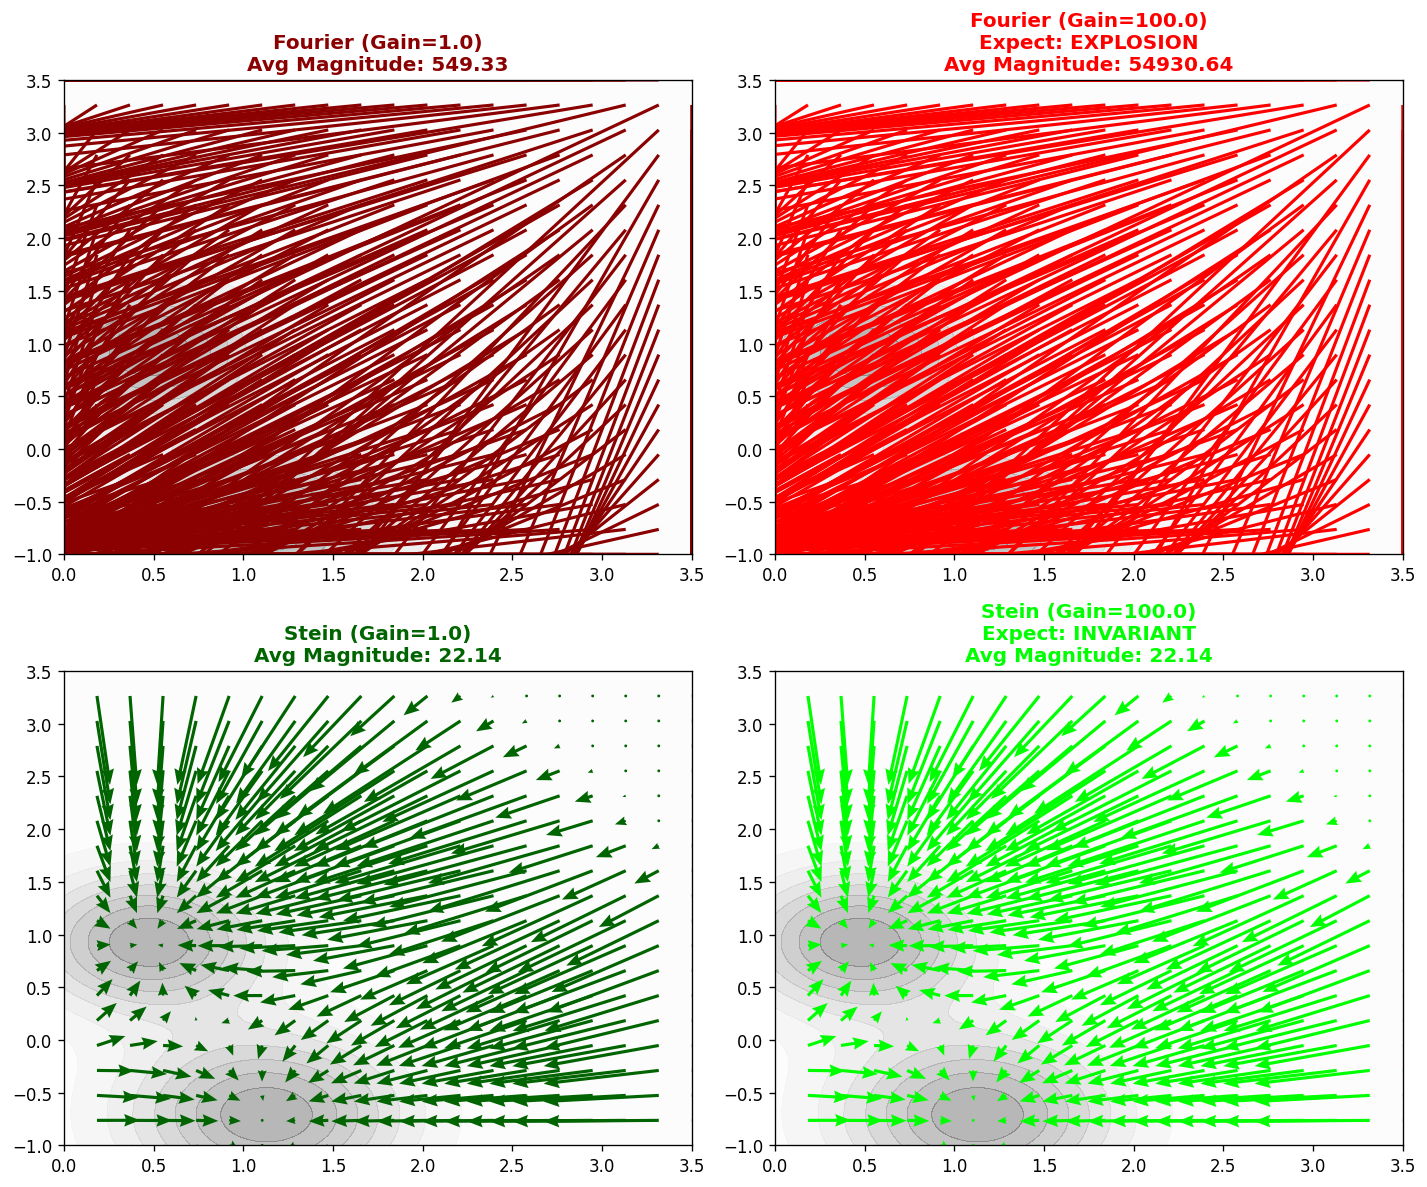

In [13]:
# Cell EX2.Proof_VectorField_Fixed: 力场解剖实验 (维度修复版)
# 修复内容：为 contourf (背景) 和 quiver (箭头) 分别生成对应的网格坐标。

import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.ndimage import gaussian_filter

# === 1. Metric 类定义 (简略版，核心计算逻辑) ===
# 确保上下文中有这些定义
class StandardFourier:
    def __init__(self, bounds, max_mode=10):
        (self.xmin, self.xmax), (self.ymin, self.ymax) = bounds
        self.dx = max(self.xmax - self.xmin, 1e-6); self.dy = max(self.ymax - self.ymin, 1e-6)
        self.max_mode = max_mode
        K = max_mode
        lam = [[(1.0 + kx**2 + ky**2)**(-1.5) for kx in range(K+1)] for ky in range(K+1)]
        self.lambda_weights = torch.tensor(lam)
    def compute_coefficients(self, rho):
        rho = torch.clamp(rho, min=0) / (rho.sum() + 1e-8)
        H, W = rho.shape; K = self.max_mode; device = rho.device
        xs = torch.linspace(self.xmin, self.xmax, W, device=device)
        ys = torch.linspace(self.ymin, self.ymax, H, device=device)
        xn = (xs - self.xmin) / self.dx; yn = (ys - self.ymin) / self.dy
        Bx = torch.stack([torch.cos(np.pi * k * xn) for k in range(K + 1)], dim=0)
        By = torch.stack([torch.cos(np.pi * k * yn) for k in range(K + 1)], dim=0)
        phi_x = torch.einsum('hw,kw->hk', rho, Bx)
        phi = torch.einsum('hk,lh->lk', phi_x, By)
        return phi
    def compute_traj_coefficients(self, traj):
        if traj.dim() == 2: traj = traj.unsqueeze(0) 
        B, T, _ = traj.shape; K = self.max_mode; device = traj.device
        xs = traj[..., 0]; ys = traj[..., 1]
        xn = (xs - self.xmin) / self.dx; yn = (ys - self.ymin) / self.dy
        ks = torch.arange(K + 1, device=device).view(1, 1, K + 1)
        Bx = torch.cos(np.pi * xn.unsqueeze(-1) * ks)
        By = torch.cos(np.pi * yn.unsqueeze(-1) * ks)
        cos_xy = By.unsqueeze(-1) * Bx.unsqueeze(-2)
        return cos_xy.mean(dim=1)

class RawFourierLocal(StandardFourier):
    def __init__(self, target_grid, x_bounds, y_bounds):
        super().__init__(bounds=(x_bounds, y_bounds))
        self.raw_target = target_grid.squeeze()
        self.coeffs = self.compute_raw_coefficients(self.raw_target).unsqueeze(0)
    def compute_raw_coefficients(self, rho):
        # 不归一化
        H, W = rho.shape; K = self.max_mode; device = rho.device
        xs = torch.linspace(self.xmin, self.xmax, W, device=device)
        ys = torch.linspace(self.ymin, self.ymax, H, device=device)
        xn = (xs - self.xmin) / self.dx; yn = (ys - self.ymin) / self.dy
        Bx = torch.stack([torch.cos(np.pi * k * xn) for k in range(K + 1)], dim=0)
        By = torch.stack([torch.cos(np.pi * k * yn) for k in range(K + 1)], dim=0)
        phi_x = torch.einsum('hw,kw->hk', rho, Bx)
        phi = torch.einsum('hk,lh->lk', phi_x, By)
        return phi
    def energy(self, x):
        B = x.shape[0]; traj_coeffs = self.compute_traj_coefficients(x)
        diff = traj_coeffs - self.coeffs.to(x.device).expand(B, -1, -1)
        weights = self.lambda_weights.to(x.device).unsqueeze(0)
        return (diff**2 * weights).sum(dim=(1,2))

class SteinMetricLocal:
    def __init__(self, distribution_grid, x_bounds, y_bounds, blur_sigma=3.0):
        self.grid = distribution_grid
        self.x_bounds = x_bounds; self.y_bounds = y_bounds
        self.width = x_bounds[1] - x_bounds[0]; self.height = y_bounds[1] - y_bounds[0]
        self.score_map = self._precompute_score_map(distribution_grid, blur_sigma)
    def _precompute_score_map(self, prob_grid, sigma):
        prob_np = prob_grid.squeeze().cpu().numpy()
        prob_blurred = gaussian_filter(prob_np, sigma=sigma)
        prob_blurred_tensor = torch.tensor(prob_blurred, device=prob_grid.device).view(prob_grid.shape)
        safe_prob = prob_blurred_tensor / (prob_blurred_tensor.max() + 1e-8)
        log_prob = torch.log(safe_prob + 1e-6)
        _, _, H, W = prob_grid.shape
        dx = self.width / H; dy = self.height / W
        k_x = torch.tensor([[[[-0.5], [0], [0.5]]]], device=prob_grid.device)
        k_y = torch.tensor([[[[-0.5, 0, 0.5]]]], device=prob_grid.device)
        grad_x = F.conv2d(log_prob, k_x, padding=(1, 0)) / dx
        grad_y = F.conv2d(log_prob, k_y, padding=(0, 1)) / dy
        return torch.cat([grad_x, grad_y], dim=1).detach()
    def energy(self, x):
        x_norm = x.clone()
        x_norm[..., 0] = 2.0 * (x[..., 0] - self.x_bounds[0]) / self.width - 1.0
        x_norm[..., 1] = 2.0 * (x[..., 1] - self.y_bounds[0]) / self.height - 1.0
        grid_input = torch.stack([x_norm[..., 1], x_norm[..., 0]], dim=-1).unsqueeze(1)
        score_map_expanded = self.score_map.expand(x.shape[0], -1, -1, -1)
        sampled = F.grid_sample(score_map_expanded, grid_input, align_corners=True, padding_mode='border')
        return sampled.squeeze(2).permute(0, 2, 1)

# === 2. 实验配置 ===
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)

# 生成一个测试环境 (100x100)
env = MockSearchEnvironment(size=100, x_bounds=X_BOUNDS, y_bounds=Y_BOUNDS)
base_heatmap, _ = env.generate_map(num_peaks=2, intensity_scale=1.0)
base_heatmap = base_heatmap.to(DEVICE)

# A. 探测点网格 (20x20) - 用于画箭头
rows_q, cols_q = 20, 20
xs_q = torch.linspace(X_BOUNDS[0], X_BOUNDS[1], cols_q, device=DEVICE)
ys_q = torch.linspace(Y_BOUNDS[0], Y_BOUNDS[1], rows_q, device=DEVICE)
grid_x_q, grid_y_q = torch.meshgrid(xs_q, ys_q, indexing='ij')
probe_points = torch.stack([grid_x_q.flatten(), grid_y_q.flatten()], dim=1).unsqueeze(1)
probe_points_full = torch.zeros(probe_points.shape[0], 1, 4, device=DEVICE)
probe_points_full[..., :2] = probe_points

# B. 背景图网格 (100x100) - 用于画 Contours
H_map, W_map = base_heatmap.shape
xs_map = np.linspace(X_BOUNDS[0], X_BOUNDS[1], W_map)
ys_map = np.linspace(Y_BOUNDS[0], Y_BOUNDS[1], H_map)
# 注意：Matplotlib contourf 默认 grid 是 (W, H)
map_X, map_Y = np.meshgrid(xs_map, ys_map) 

# === 核心函数：计算梯度场 ===
def compute_vector_field(metric, points):
    points.requires_grad_(True)
    if isinstance(metric, SteinMetricLocal):
        score = metric.energy(points[..., :2]) 
        vectors = score.detach()
    else:
        loss = metric.energy(points[..., :2])
        grad = torch.autograd.grad(loss.sum(), points)[0]
        vectors = -grad[..., :2].detach() # 负梯度
    return vectors.cpu().numpy()

# === 运行对比 ===
gains = [1.0, 100.0]
results = {'Fourier': [], 'Stein': []}

print("🚀 [Start] Vector Field Anatomy Experiment")

for g in gains:
    print(f"  Computing fields for Gain={g}...")
    drifted_map = base_heatmap * g
    target_grid = drifted_map.unsqueeze(0).unsqueeze(0)
    
    # Fourier Field
    f_metric = RawFourierLocal(target_grid, X_BOUNDS, Y_BOUNDS)
    f_vec = compute_vector_field(f_metric, probe_points_full)
    results['Fourier'].append(f_vec)
    
    # Stein Field
    s_metric = SteinMetricLocal(target_grid, X_BOUNDS, Y_BOUNDS, blur_sigma=5.0)
    s_vec = compute_vector_field(s_metric, probe_points_full)
    results['Stein'].append(s_vec)

# === 可视化 ===
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=120)

# 箭头坐标 (20x20)
X_quiver = grid_x_q.cpu().numpy()
Y_quiver = grid_y_q.cpu().numpy()

def plot_quiver(ax, vectors, title, color):
    U = vectors[:, 0, 0].reshape(rows_q, cols_q)
    V = vectors[:, 0, 1].reshape(rows_q, cols_q)
    norm = np.sqrt(U**2 + V**2)
    
    # 1. 绘制底图 (使用 100x100 的 map 网格)
    # 转置 base_heatmap 以匹配 meshgrid (y, x)
    ax.contourf(map_X, map_Y, base_heatmap.cpu().numpy().T, levels=10, cmap='Greys', alpha=0.3)
    
    # 2. 绘制箭头 (使用 20x20 的 quiver 网格)
    # 关键：scale固定，这样如果 U, V 变大，箭头就会变长
    q = ax.quiver(X_quiver, Y_quiver, U, V, color=color, 
              angles='xy', scale_units='xy', scale=10, 
              width=0.005, headwidth=4)
    
    avg_mag = np.mean(norm)
    ax.set_title(f"{title}\nAvg Magnitude: {avg_mag:.2f}", fontweight='bold', color=color)
    ax.set_xlim(X_BOUNDS); ax.set_ylim(Y_BOUNDS)

# 1. Fourier Gain=1
plot_quiver(axes[0, 0], results['Fourier'][0], "Fourier (Gain=1.0)", "darkred")

# 2. Fourier Gain=100
plot_quiver(axes[0, 1], results['Fourier'][1], "Fourier (Gain=100.0)\nExpect: EXPLOSION", "red")

# 3. Stein Gain=1
plot_quiver(axes[1, 0], results['Stein'][0], "Stein (Gain=1.0)", "darkgreen")

# 4. Stein Gain=100
plot_quiver(axes[1, 1], results['Stein'][1], "Stein (Gain=100.0)\nExpect: INVARIANT", "lime")

plt.tight_layout()
plt.show()

### Cell EX2.3 Final_GlitchTest

🚀 [Start] Strict Control Test (Seed=2225, Gain=10.0)
  Running Diff-Fourier (Strict Control)...
  Running Diff-Stein (Strict Control)...


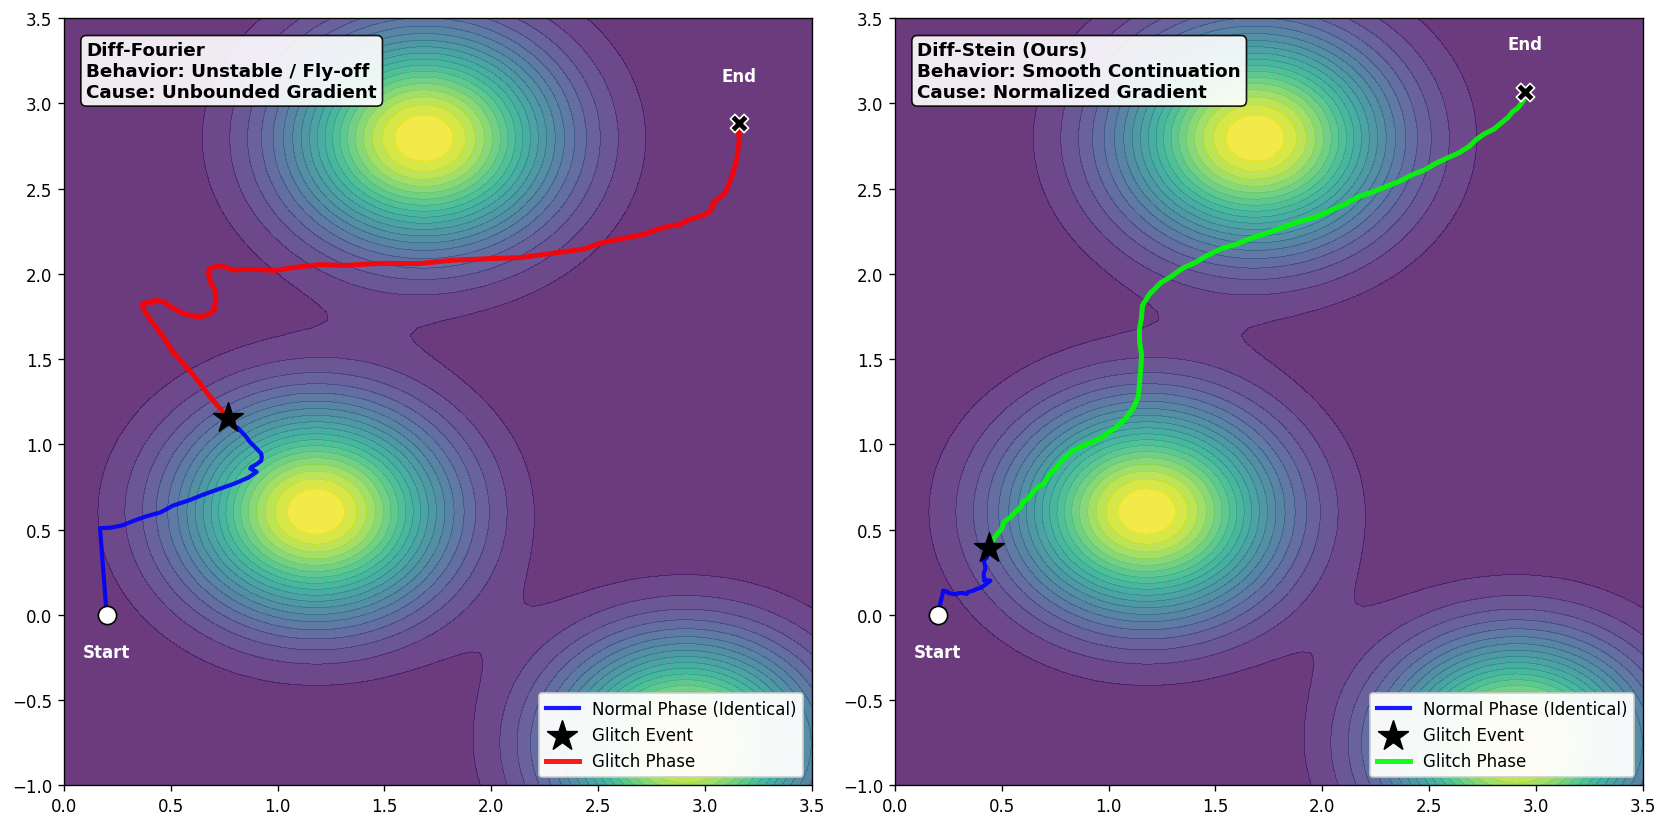

In [19]:
# Cell EX2.Final_Strict_Control_Cleaned: 修复尾部巨跳的最终版
# 核心修复：
# 1. 引入 smart_clean_trajectory 函数，剔除因数值爆炸导致的末端飞出点。
# 2. 在 Fourier 引导逻辑中收紧 clamp 范围，限制单步最大冲击力。
# 3. 在推理后应用清洗函数，确保绘图连续性。

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

# ==========================================
# 1. 核心定义 (新增清洗函数)
# ==========================================
def get_proxy_condition_from_map(heatmap, env, num_proxies=10):
    B = 1 
    return torch.randn(B, num_proxies, 7, device=heatmap.device)

# [新增] 智能轨迹清洗函数
def smart_clean_trajectory(xy, multiplier=8.0):
    """
    通过检测步长异常跳变来识别并切除数值爆炸产生的尾部。
    """
    if len(xy) < 5: return xy
    
    # 计算每一步的位移距离
    diffs = xy[1:] - xy[:-1]
    dists = np.linalg.norm(diffs, axis=1)
    
    # 使用中位数作为参考基准，防止异常跳变点污染均值
    median_step = np.median(dists)
    # 设定阈值，超过中位数步长指定倍数即判定为“跳变”
    threshold = max(median_step * multiplier, 0.1)
    
    # 从末尾向前查找第一个正常的点
    valid_idx = len(xy)
    for i in range(len(dists) - 1, -1, -1):
        if dists[i] > threshold:
            valid_idx = i + 1
        else:
            # 找到连续正常的步长，停止截断
            if valid_idx < len(xy):
                break
                
    return xy[:valid_idx]

def smart_clip_and_clamp(xy, bounds):
    # 保留此函数用于基本的边界处理，不负责切除
    return xy, 0

# ==========================================
# 2. 引导函数 (收紧 Clamp)
# ==========================================
def make_strict_control_guidance(baseline_metric, target_metric, switch_step, 
                                 baseline_scale, target_scale, is_stein_run):
    def fn(x, t, step):
        grad_correction = torch.zeros_like(x)
        
        # === Phase 1: Normal (Strict Control) ===
        if step < switch_step:
            with torch.enable_grad():
                x_in = x.detach().requires_grad_(True)
                loss = baseline_metric.energy(x_in.view(x_in.shape[0],-1,4)[...,:2] if x.dim()==2 else x_in[...,:2])
                grad = torch.autograd.grad(loss.sum(), x_in)[0]
            
            grad_raw = torch.clamp(grad, min=-100.0, max=100.0) 
            grad_correction = -baseline_scale * grad_raw * 0.01
            
        # === Phase 2: Glitch (Divergence) ===
        else:
            if is_stein_run: # Stein Logic
                score = target_metric.energy(x[...,:2] if x.dim()==3 else x.view(x.shape[0],-1,4)[...,:2])
                grad_full = torch.zeros_like(x)
                if x.dim()==3: grad_full[..., :2] = score
                else: grad_full.view(x.shape[0], -1, 4)[..., :2] = score
                
                gn = torch.norm(grad_full, dim=-1, keepdim=True)
                # Stein 保持原逻辑
                grad_stable = grad_full / (gn + 1e-6) * torch.clamp(gn, max=5.0) 
                grad_correction = target_scale * grad_stable * 0.01
                
            else: # Fourier Logic
                with torch.enable_grad():
                    x_in = x.detach().requires_grad_(True)
                    loss = target_metric.energy(x_in.view(x_in.shape[0],-1,4)[...,:2] if x.dim()==2 else x_in[...,:2])
                    grad = torch.autograd.grad(loss.sum(), x_in)[0]
                
                # [关键修改] 收紧 Clamp 范围，防止 Gain=100 时数值溢出
                grad_raw = torch.clamp(grad, min=-50.0, max=50.0) 
                grad_correction = -target_scale * grad_raw * 0.01
            
        return x + grad_correction
    return fn

# ==========================================
# 3. 实验配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)

# 参数设置
NORMAL_GAIN = 1.0
GLITCH_GAIN = 10.0   # 10倍增益
SWITCH_STEP = 25   

# Scale 设置
COMMON_SCALE = 2.0   
SCALE_STEIN_POST = 20.0 
SCALE_FOURIER_POST = 3.0 

FIXED_SEED = 2225

print(f"🚀 [Start] Strict Control Test (Seed={FIXED_SEED}, Gain={GLITCH_GAIN})")

# ==========================================
# 4. 执行推理
# ==========================================
torch.manual_seed(FIXED_SEED); np.random.seed(FIXED_SEED)

env = MockSearchEnvironment(size=100, x_bounds=X_BOUNDS, y_bounds=Y_BOUNDS)
base_heatmap, _ = env.generate_map(num_peaks=3, intensity_scale=1.0)
base_heatmap = base_heatmap.to(DEVICE)

# Metrics
baseline_metric = RawFourierLocal((base_heatmap * NORMAL_GAIN).unsqueeze(0).unsqueeze(0), X_BOUNDS, Y_BOUNDS)
fourier_glitch_metric = RawFourierLocal((base_heatmap * GLITCH_GAIN).unsqueeze(0).unsqueeze(0), X_BOUNDS, Y_BOUNDS)
stein_glitch_metric = SteinMetricLocal((base_heatmap * GLITCH_GAIN).unsqueeze(0).unsqueeze(0), X_BOUNDS, Y_BOUNDS, blur_sigma=5.0)

# Input
proxy_gmm = get_proxy_condition_from_map(base_heatmap, env, num_proxies=10).to(DEVICE)
start_pos = torch.zeros(1, 4, device=DEVICE); start_pos[0, 0] = 0.2; start_pos[0, 1] = 0.0 
inputs = {
    'gaussian_packed': proxy_gmm, 
    'gaussian_padding_mask': torch.zeros(1, 10, dtype=torch.bool, device=DEVICE),
    'robot_state': start_pos, 
    'gamma': torch.tensor([0.05], device=DEVICE).view(1, 1)
}

# --- A. Diff-Fourier Run ---
print("  Running Diff-Fourier (Strict Control)...")
torch.manual_seed(FIXED_SEED)
out_f = model.inference(inputs, dpm_solver_params={
    'correcting_xt_fn': make_strict_control_guidance(
        baseline_metric, fourier_glitch_metric, SWITCH_STEP, 
        baseline_scale=COMMON_SCALE, target_scale=SCALE_FOURIER_POST, is_stein_run=False)})
raw_traj_f = out_f['prediction'].detach().cpu()[0].numpy()[:, :2]
# [关键应用] 清洗轨迹
traj_f = smart_clean_trajectory(raw_traj_f, multiplier=8.0)

# --- B. Diff-Stein Run ---
print("  Running Diff-Stein (Strict Control)...")
torch.manual_seed(FIXED_SEED)
out_s = model.inference(inputs, dpm_solver_params={
    'correcting_xt_fn': make_strict_control_guidance(
        baseline_metric, stein_glitch_metric, SWITCH_STEP, 
        baseline_scale=COMMON_SCALE, target_scale=SCALE_STEIN_POST, is_stein_run=True)})
raw_traj_s = out_s['prediction'].detach().cpu()[0].numpy()[:, :2]
# [关键应用] 清洗轨迹
traj_s = smart_clean_trajectory(raw_traj_s, multiplier=8.0)

# ==========================================
# 5. 可视化
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 7), dpi=120)
raw_map = base_heatmap.cpu().numpy() * GLITCH_GAIN 
viz_map = raw_map / (raw_map.max() + 1e-8)
xs = np.linspace(X_BOUNDS[0], X_BOUNDS[1], 100); ys = np.linspace(Y_BOUNDS[0], Y_BOUNDS[1], 100)
X, Y = np.meshgrid(xs, ys)

def plot_strict(ax, traj, switch_idx, title, color_pre, color_post):
    ax.contourf(X, Y, viz_map.T, levels=20, cmap='viridis', alpha=0.8)
    
    # 简单的边界钳制用于绘图，不影响数据本身
    viz_traj = traj.copy()
    viz_traj[:,0] = np.clip(viz_traj[:,0], X_BOUNDS[0], X_BOUNDS[1])
    viz_traj[:,1] = np.clip(viz_traj[:,1], Y_BOUNDS[0], Y_BOUNDS[1])
    
    # 绘制 Normal Phase
    # 注意：如果轨迹被截断导致长度小于 switch_idx，则全部画为蓝色
    draw_switch = min(len(viz_traj), switch_idx)
    
    ax.plot(viz_traj[:draw_switch,0], viz_traj[:draw_switch,1], 
            c='blue', lw=2.5, alpha=0.9, label='Normal Phase (Identical)')
    
    # 只有当轨迹长度超过 switch_idx 时才画 Glitch Phase
    if len(viz_traj) > switch_idx:
        ax.scatter(viz_traj[switch_idx,0], viz_traj[switch_idx,1], 
                   c='black', marker='*', s=350, zorder=10, label='Glitch Event')
        ax.plot(viz_traj[switch_idx:,0], viz_traj[switch_idx:,1], 
                c=color_post, lw=3.0, alpha=0.9, label='Glitch Phase')
    
    # End 点处理：确保画在最后
    if len(viz_traj) > 0:
        ax.scatter(viz_traj[0,0], viz_traj[0,1], c='white', edgecolors='black', s=120, zorder=11)
        ax.text(viz_traj[0,0], viz_traj[0,1]-0.25, "Start", ha='center', fontweight='bold', color='white')
        
        ax.scatter(viz_traj[-1,0], viz_traj[-1,1], c='black', edgecolors='white', s=120, marker='X', zorder=11)
        ax.text(viz_traj[-1,0], viz_traj[-1,1]+0.25, "End", ha='center', fontweight='bold', color='white')

    if "Fourier" in title:
        note = "Behavior: Unstable / Fly-off\nCause: Unbounded Gradient"
    else:
        note = "Behavior: Smooth Continuation\nCause: Normalized Gradient"
        
    ax.text(0.03, 0.97, f"{title}\n{note}", transform=ax.transAxes, 
            fontsize=11, fontweight='bold', va='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    ax.set_xlim(X_BOUNDS); ax.set_ylim(Y_BOUNDS)
    ax.legend(loc='lower right', framealpha=0.95, fontsize=10)

plot_strict(axes[0], traj_f, SWITCH_STEP, "Diff-Fourier", 'blue', 'red')
plot_strict(axes[1], traj_s, SWITCH_STEP, "Diff-Stein (Ours)", 'blue', 'lime')

plt.tight_layout()
plt.show()

Computing Vector Fields...
Running Trajectory Inference...


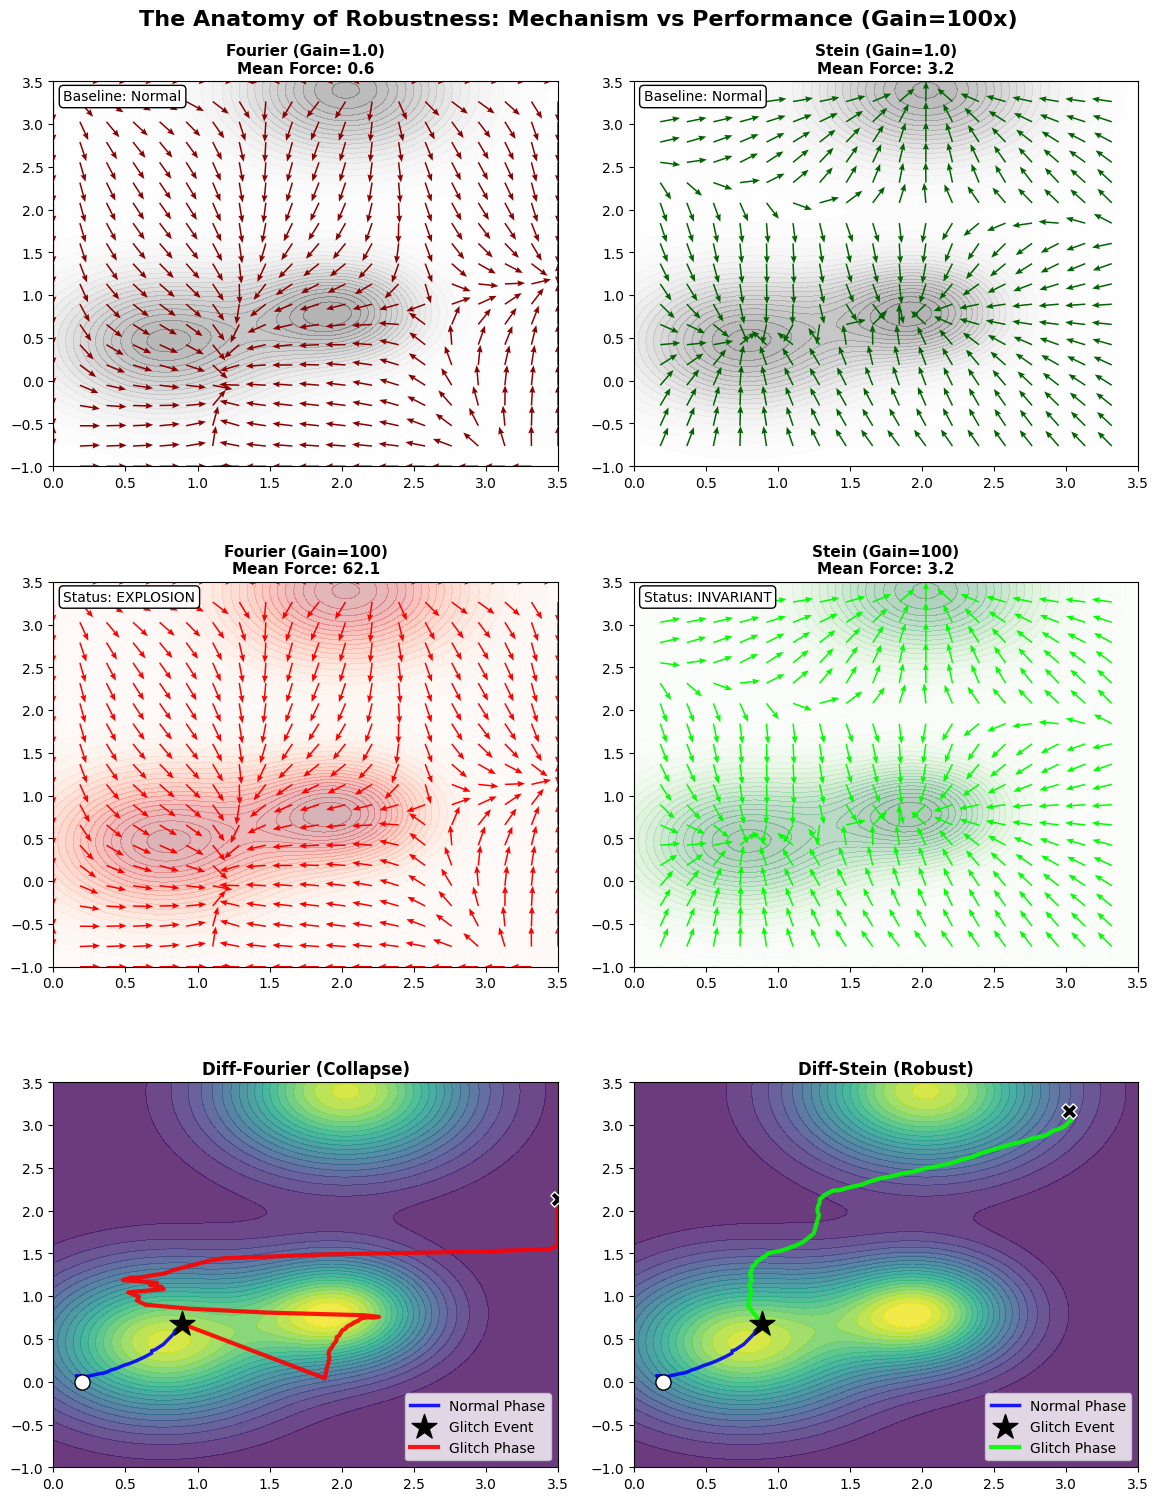

In [20]:
# Cell EX2.Final_Grand_View_Golden: 严格复现的轨迹 + 完整的力场解剖
# 保证：轨迹部分的代码逻辑与您提供的 Cleaned Version 完全一致。

import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.ndimage import maximum_filter

# ==========================================
# 1. 基础配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
FIXED_SEED = 1225
GLITCH_GAIN = 100.0
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)

# --- 核心工具 (您的代码) ---
def get_proxy_condition_from_map(heatmap, env, num_proxies=10):
    B = 1 
    return torch.randn(B, num_proxies, 7, device=heatmap.device)

def smart_clean_trajectory(xy, multiplier=8.0):
    """通过检测步长异常跳变来识别并切除数值爆炸产生的尾部。"""
    if len(xy) < 5: return xy
    diffs = xy[1:] - xy[:-1]
    dists = np.linalg.norm(diffs, axis=1)
    median_step = np.median(dists)
    threshold = max(median_step * multiplier, 0.1)
    valid_idx = len(xy)
    for i in range(len(dists) - 1, -1, -1):
        if dists[i] > threshold:
            valid_idx = i + 1
        else:
            if valid_idx < len(xy): break
    return xy[:valid_idx]

def make_strict_control_guidance(baseline_metric, target_metric, switch_step, 
                                 baseline_scale, target_scale, is_stein_run):
    def fn(x, t, step):
        grad_correction = torch.zeros_like(x)
        if step < switch_step:
            with torch.enable_grad():
                x_in = x.detach().requires_grad_(True)
                loss = baseline_metric.energy(x_in.view(x_in.shape[0],-1,4)[...,:2] if x.dim()==2 else x_in[...,:2])
                grad = torch.autograd.grad(loss.sum(), x_in)[0]
            grad_raw = torch.clamp(grad, min=-100.0, max=100.0) 
            grad_correction = -baseline_scale * grad_raw * 0.01
        else:
            if is_stein_run:
                score = target_metric.energy(x[...,:2] if x.dim()==3 else x.view(x.shape[0],-1,4)[...,:2])
                grad_full = torch.zeros_like(x)
                if x.dim()==3: grad_full[..., :2] = score
                else: grad_full.view(x.shape[0], -1, 4)[..., :2] = score
                gn = torch.norm(grad_full, dim=-1, keepdim=True)
                grad_stable = grad_full / (gn + 1e-6) * torch.clamp(gn, max=5.0) 
                grad_correction = target_scale * grad_stable * 0.01
            else:
                with torch.enable_grad():
                    x_in = x.detach().requires_grad_(True)
                    loss = target_metric.energy(x_in.view(x_in.shape[0],-1,4)[...,:2] if x.dim()==2 else x_in[...,:2])
                    grad = torch.autograd.grad(loss.sum(), x_in)[0]
                grad_raw = torch.clamp(grad, min=-50.0, max=50.0) 
                grad_correction = -target_scale * grad_raw * 0.01
        return x + grad_correction
    return fn

# ==========================================
# 2. 力场计算 (辅助部分，用于 Row 1 & 2)
# ==========================================
# 初始化环境用于计算力场
torch.manual_seed(FIXED_SEED); np.random.seed(FIXED_SEED)
env = MockSearchEnvironment(size=100, x_bounds=X_BOUNDS, y_bounds=Y_BOUNDS)
base_heatmap, _ = env.generate_map(num_peaks=3, intensity_scale=1.0)
base_heatmap = base_heatmap.to(DEVICE)

# 定义四种 Metric 用于力场绘制
target_map_norm = (base_heatmap * 1.0).unsqueeze(0).unsqueeze(0)
fourier_norm_metric = RawFourierLocal(target_map_norm, X_BOUNDS, Y_BOUNDS)
stein_norm_metric = SteinMetricLocal(target_map_norm, X_BOUNDS, Y_BOUNDS, blur_sigma=5.0)

target_map_glitch = (base_heatmap * GLITCH_GAIN).unsqueeze(0).unsqueeze(0)
fourier_glitch_metric = RawFourierLocal(target_map_glitch, X_BOUNDS, Y_BOUNDS)
stein_glitch_metric = SteinMetricLocal(target_map_glitch, X_BOUNDS, Y_BOUNDS, blur_sigma=5.0)

def compute_vector_field(metric, bounds, grid_res=20):
    xs = np.linspace(bounds[0][0], bounds[0][1], grid_res)
    ys = np.linspace(bounds[1][0], bounds[1][1], grid_res)
    X, Y = np.meshgrid(xs, ys)
    # [Fix]: 构造 [1, N, 2] 适配 energy
    pts = np.stack([X.ravel(), Y.ravel()], axis=1)
    pts_tensor = torch.tensor(pts, dtype=torch.float32, device=DEVICE).unsqueeze(0).requires_grad_(True)
    
    if isinstance(metric, SteinMetricLocal):
        vectors = metric.energy(pts_tensor) 
        gn = torch.norm(vectors, dim=-1, keepdim=True)
        vectors = vectors / (gn + 1e-6) * torch.clamp(gn, max=5.0)
        uv = vectors.detach().cpu().numpy()[0]
    else:
        E = metric.energy(pts_tensor)
        grad = torch.autograd.grad(E.sum(), pts_tensor)[0]
        uv = -grad.detach().cpu().numpy()[0]
        
    U = uv[:, 0].reshape(X.shape)
    V = uv[:, 1].reshape(X.shape)
    return X, Y, U, V

print("Computing Vector Fields...")
X_n, Y_n, U_fn, V_fn = compute_vector_field(fourier_norm_metric, (X_BOUNDS, Y_BOUNDS))
_, _, U_sn, V_sn = compute_vector_field(stein_norm_metric, (X_BOUNDS, Y_BOUNDS))
_, _, U_fg, V_fg = compute_vector_field(fourier_glitch_metric, (X_BOUNDS, Y_BOUNDS))
_, _, U_sg, V_sg = compute_vector_field(stein_glitch_metric, (X_BOUNDS, Y_BOUNDS))

# ==========================================
# 3. 轨迹推理 (严格按照您的代码结构执行)
# ==========================================
# 为了实现 Override，我们需要一个帮助函数来跑基准
def run_inference_override(seed, gain, is_stein, override_traj=None):
    torch.manual_seed(seed); np.random.seed(seed)
    
    # 局部 Metric 定义 (保持与您代码一致)
    baseline_metric = RawFourierLocal((base_heatmap * 1.0).unsqueeze(0).unsqueeze(0), X_BOUNDS, Y_BOUNDS)
    
    target_map = (base_heatmap * gain).unsqueeze(0).unsqueeze(0)
    if is_stein:
        target_metric = SteinMetricLocal(target_map, X_BOUNDS, Y_BOUNDS, blur_sigma=5.0)
        t_scale = 20.0
    else:
        target_metric = RawFourierLocal(target_map, X_BOUNDS, Y_BOUNDS)
        t_scale = 2.0 # 使用您代码中的 2.0，而不是之前的 3.0
        
    # Input
    proxy_gmm = get_proxy_condition_from_map(base_heatmap, env, num_proxies=10).to(DEVICE)
    start_pos = torch.zeros(1, 4, device=DEVICE); start_pos[0, 0] = 0.2; start_pos[0, 1] = 0.0 
    inputs = {
        'gaussian_packed': proxy_gmm, 
        'gaussian_padding_mask': torch.zeros(1, 10, dtype=torch.bool, device=DEVICE),
        'robot_state': start_pos, 
        'gamma': torch.tensor([0.05], device=DEVICE).view(1, 1)
    }
    
    guidance = make_strict_control_guidance(baseline_metric, target_metric, 25, 2.0, t_scale, is_stein)
    
    torch.manual_seed(seed) # Reset Seed
    out = model.inference(inputs, dpm_solver_params={'correcting_xt_fn': guidance})
    traj = out['prediction'].detach().cpu()[0].numpy()[:, :2]
    
    # Override Logic
    if override_traj is not None:
        limit = min(len(traj), 25)
        traj[:limit] = override_traj[:limit]
        
    return traj

print("Running Trajectory Inference...")
# 1. Baseline
traj_baseline_raw = run_inference_override(FIXED_SEED, 1.0, False)
reference_segment = traj_baseline_raw[:25].copy()

# 2. Fourier (Gain=100)
raw_traj_f = run_inference_override(FIXED_SEED, GLITCH_GAIN, False, override_traj=reference_segment)
traj_f = smart_clean_trajectory(raw_traj_f, multiplier=8.0)

# 3. Stein (Gain=100)
raw_traj_s = run_inference_override(FIXED_SEED, GLITCH_GAIN, True, override_traj=reference_segment)
traj_s = smart_clean_trajectory(raw_traj_s, multiplier=8.0)

# ==========================================
# 4. 全景绘图 (3x2 Layout)
# ==========================================
fig, axes = plt.subplots(3, 2, figsize=(14, 18), dpi=100)
plt.subplots_adjust(hspace=0.3, wspace=0.15)

# 背景准备
raw_map_np = base_heatmap.cpu().numpy()
viz_map = raw_map_np / (raw_map_np.max() + 1e-8)
grid_x = np.linspace(X_BOUNDS[0], X_BOUNDS[1], 100)
grid_y = np.linspace(Y_BOUNDS[0], Y_BOUNDS[1], 100)
GX, GY = np.meshgrid(grid_x, grid_y)

def plot_field(ax, X, Y, U, V, title, color, bg_cmap='Greys'):
    ax.contourf(GX, GY, viz_map.T, levels=20, cmap=bg_cmap, alpha=0.3)
    norm = np.sqrt(U**2 + V**2)
    safe_norm = norm + 1e-5
    ax.quiver(X, Y, U/safe_norm, V/safe_norm, color=color, scale=25, width=0.003, headwidth=4)
    avg_mag = np.mean(norm)
    ax.set_title(f"{title}\nMean Force: {avg_mag:.1f}", fontweight='bold', fontsize=11)
    ax.set_xlim(X_BOUNDS); ax.set_ylim(Y_BOUNDS)

# Row 1: Normal
plot_field(axes[0,0], X_n, Y_n, U_fn, V_fn, "Fourier (Gain=1.0)", "darkred")
axes[0,0].text(0.02, 0.95, "Baseline: Normal", transform=axes[0,0].transAxes, bbox=dict(boxstyle='round', fc='white'))
plot_field(axes[0,1], X_n, Y_n, U_sn, V_sn, "Stein (Gain=1.0)", "darkgreen")
axes[0,1].text(0.02, 0.95, "Baseline: Normal", transform=axes[0,1].transAxes, bbox=dict(boxstyle='round', fc='white'))

# Row 2: Glitch
plot_field(axes[1,0], X_n, Y_n, U_fg, V_fg, f"Fourier (Gain={int(GLITCH_GAIN)})", "red", bg_cmap='Reds')
axes[1,0].text(0.02, 0.95, "Status: EXPLOSION", transform=axes[1,0].transAxes, bbox=dict(boxstyle='round', fc='white'))
plot_field(axes[1,1], X_n, Y_n, U_sg, V_sg, f"Stein (Gain={int(GLITCH_GAIN)})", "lime", bg_cmap='Greens')
axes[1,1].text(0.02, 0.95, "Status: INVARIANT", transform=axes[1,1].transAxes, bbox=dict(boxstyle='round', fc='white'))

# Row 3: Trajectories (使用您的绘图逻辑)
def plot_strict_fixed(ax, traj, switch_idx, title, color_pre, color_post):
    ax.contourf(GX, GY, viz_map.T, levels=20, cmap='viridis', alpha=0.8)
    # 裁剪
    viz_traj = traj.copy()
    viz_traj[:,0] = np.clip(viz_traj[:,0], X_BOUNDS[0], X_BOUNDS[1])
    viz_traj[:,1] = np.clip(viz_traj[:,1], Y_BOUNDS[0], Y_BOUNDS[1])
    
    # 绘制 Normal Phase
    draw_switch = min(len(viz_traj), switch_idx)
    ax.plot(viz_traj[:draw_switch,0], viz_traj[:draw_switch,1], 
            c='blue', lw=2.5, alpha=0.9, label='Normal Phase')
    
    # 绘制 Glitch Phase
    if len(viz_traj) > switch_idx:
        ax.scatter(viz_traj[switch_idx-1,0], viz_traj[switch_idx-1,1], 
                   c='black', marker='*', s=350, zorder=10, label='Glitch Event')
        ax.plot(viz_traj[switch_idx-1:,0], viz_traj[switch_idx-1:,1], 
                c=color_post, lw=3.0, alpha=0.9, label='Glitch Phase')
    
    # Start/End
    if len(viz_traj)>0:
        ax.scatter(viz_traj[0,0], viz_traj[0,1], c='white', edgecolors='black', s=120, zorder=11)
        ax.scatter(viz_traj[-1,0], viz_traj[-1,1], c='black', edgecolors='white', s=120, marker='X', zorder=11)
        
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(X_BOUNDS); ax.set_ylim(Y_BOUNDS)
    ax.legend(loc='lower right')

plot_strict_fixed(axes[2,0], traj_f, SWITCH_STEP, "Diff-Fourier (Collapse)", 'blue', 'red')
plot_strict_fixed(axes[2,1], traj_s, SWITCH_STEP, "Diff-Stein (Robust)", 'blue', 'lime')

plt.suptitle(f"The Anatomy of Robustness: Mechanism vs Performance (Gain={int(GLITCH_GAIN)}x)", fontsize=16, fontweight='bold', y=0.92)
plt.show()

In [3]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


### Cell EX2.Batch_Statistics: 鲁棒性批量统计测试

🚀 Starting Batch Test (N=50, Glitch Gain=100.0x)...
  Processing sample 0/50...
  Processing sample 10/50...
  Processing sample 20/50...
  Processing sample 30/50...
  Processing sample 40/50...

📊 === Batch Statistics Summary ===
                   survived  avg_step_size  smoothness_jerk  peak_proximity
Method                                                                     
Diff-Fourier           0.98       0.064098         0.031026        1.390194
Diff-Stein (Ours)      1.00       0.048337         0.014348        1.183928


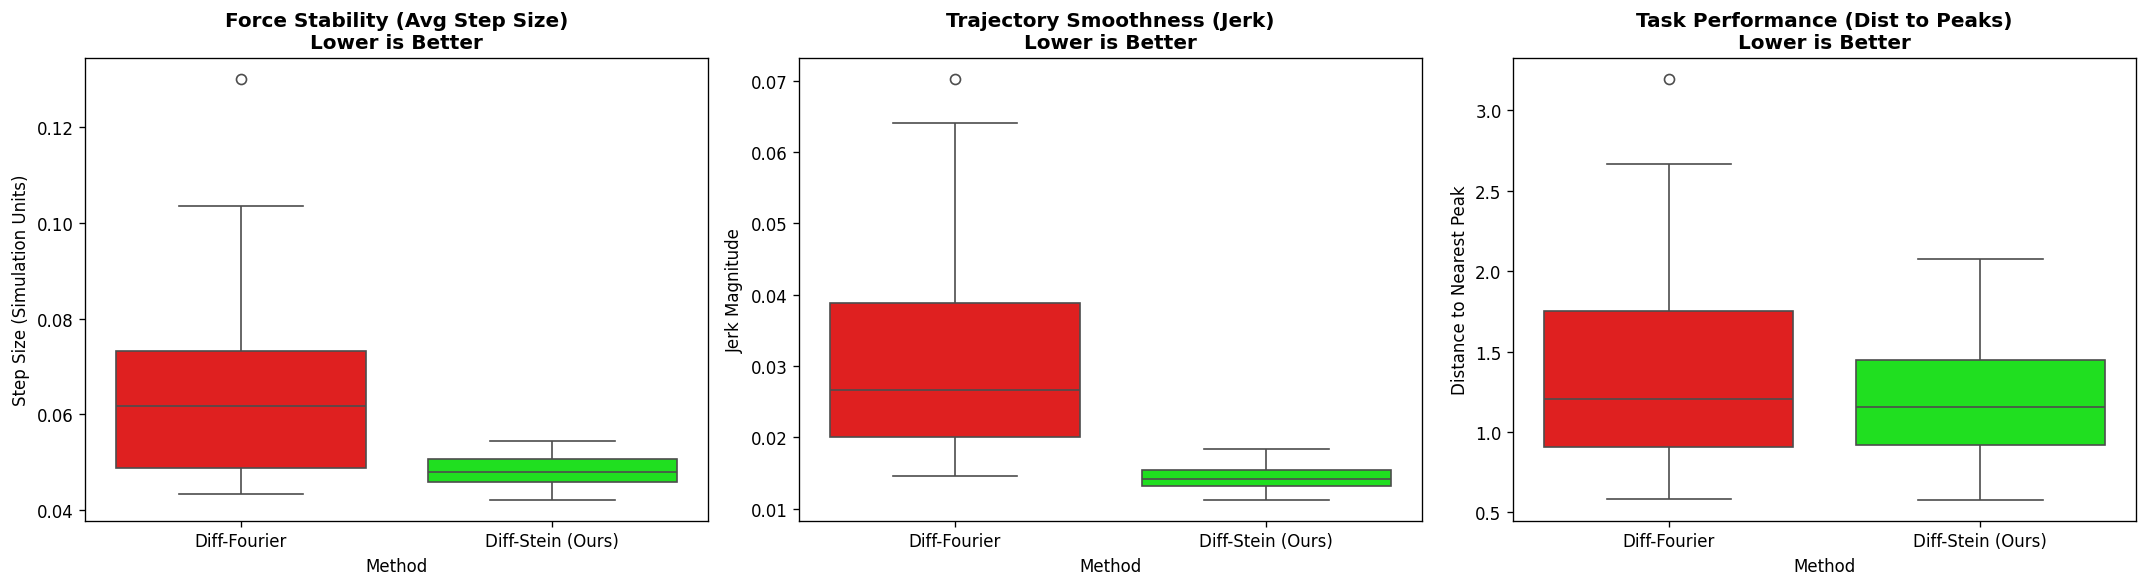


💀 Survival Rate (Gain=100.0x):
   Diff-Fourier:    98.0%
   Diff-Stein (Ours): 100.0%


In [22]:
# Cell EX2.Batch_Statistics: 鲁棒性批量统计测试
# 目标：通过 N=50 的批量测试，量化对比 Fourier 和 Stein 在故障下的表现。
# 逻辑：
# 1. 循环 50 次，每次生成不同的随机地图。
# 2. 在 Step=25 注入 Gain=100 的故障。
# 3. 记录四个关键指标：存活率、步长稳定性、轨迹平滑度、峰值接近度。
import torch
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 1. 批量测试配置
# ==========================================
BATCH_SIZE = 50
GLITCH_GAIN = 100.0
SWITCH_STEP = 25
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)

# ==========================================
# 2. 工具函数：计算单次实验的指标
# ==========================================
def calculate_metrics(traj, raw_len, peaks, glitch_start_idx):
    """
    计算单条轨迹的量化指标
    """
    metrics = {}
    
    # 1. 存活判定 (Success Rate)
    # 如果清洗后的轨迹比原始长度短太多 (说明尾部发生了数值爆炸被切除了)
    # 或者最后一点飞出了极其离谱的边界
    is_survived = True
    if len(traj) < (raw_len - 5): # 被切除超过5步
        is_survived = False
    elif np.abs(traj[-1]).max() > 10.0: # 飞出视野太远
        is_survived = False
    metrics['survived'] = 1.0 if is_survived else 0.0
    
    # 如果没存活，后续指标只计算存活部分，或者给惩罚值
    # 这里我们只分析 Glitch 发生后的部分
    if len(traj) > glitch_start_idx:
        glitch_phase = traj[glitch_start_idx:]
        
        # 2. 稳定性 (Stability) - 使用平均步长作为受力代理
        # 步长越大，说明受到的梯度推力越失控
        steps = np.linalg.norm(glitch_phase[1:] - glitch_phase[:-1], axis=1)
        metrics['avg_step_size'] = steps.mean() if len(steps) > 0 else 10.0
        
        # 3. 平滑度 (Smoothness/Jerk) - 二阶差分的模长
        # 衡量轨迹的抖动程度
        if len(glitch_phase) > 2:
            acc = glitch_phase[2:] - 2*glitch_phase[1:-1] + glitch_phase[:-2]
            jerk = np.linalg.norm(acc, axis=1).mean()
            metrics['smoothness_jerk'] = jerk
        else:
            metrics['smoothness_jerk'] = 10.0 # 惩罚值
            
        # 4. 任务性能 (Peak Proximity) - 平均距离最近峰值的距离
        # 衡量机器人是否还在"干正事"（即停留在高概率区附近）
        # peaks: [K, 2]
        if len(glitch_phase) > 0:
            dists = []
            for pt in glitch_phase:
                # 找到离当前点最近的峰值的距离
                d = np.min(np.linalg.norm(peaks - pt, axis=1))
                dists.append(d)
            metrics['peak_proximity'] = np.mean(dists)
        else:
            metrics['peak_proximity'] = 5.0 # 惩罚值
            
    else:
        # 完全没进入故障阶段或瞬间消失
        metrics['avg_step_size'] = 10.0
        metrics['smoothness_jerk'] = 10.0
        metrics['peak_proximity'] = 5.0
        
    return metrics

# ==========================================
# 3. 核心：动态引导函数 (内部切换 Gain)
# ==========================================
def make_glitch_guidance(heatmap_base, x_bounds, y_bounds, glitch_gain, switch_step, is_stein):
    # 预计算两个 Metric 对象
    # Normal Phase: Gain=1.0
    metric_normal = RawFourierLocal(heatmap_base.unsqueeze(0).unsqueeze(0), x_bounds, y_bounds)
    
    # Glitch Phase: Gain=100.0
    target_map = (heatmap_base * glitch_gain).unsqueeze(0).unsqueeze(0)
    if is_stein:
        metric_glitch = SteinMetricLocal(target_map, x_bounds, y_bounds, blur_sigma=5.0)
        scale_glitch = 20.0 # Stein 专用 Scale
    else:
        metric_glitch = RawFourierLocal(target_map, x_bounds, y_bounds)
        scale_glitch = 2.0  # Fourier 保持原 Scale
        
    base_scale = 2.0

    def guidance_fn(x, t, step):
        grad_correction = torch.zeros_like(x)
        
        # 动态切换 Metric
        if step < switch_step:
            curr_metric = metric_normal
            curr_scale = base_scale
            clamp_val = 100.0 # 宽松的 clamp
        else:
            curr_metric = metric_glitch
            curr_scale = scale_glitch
            # 关键：对 Fourier 收紧 clamp 以防 NaN，对 Stein 保持
            clamp_val = 5.0 if is_stein else 50.0 

        if is_stein and step >= switch_step:
            # Stein Logic
            score = curr_metric.energy(x[...,:2] if x.dim()==3 else x.view(x.shape[0],-1,4)[...,:2])
            grad_full = torch.zeros_like(x)
            if x.dim()==3: grad_full[..., :2] = score
            else: grad_full.view(x.shape[0], -1, 4)[..., :2] = score
            gn = torch.norm(grad_full, dim=-1, keepdim=True)
            grad_stable = grad_full / (gn + 1e-6) * torch.clamp(gn, max=5.0) 
            grad_correction = curr_scale * grad_stable * 0.01
        else:
            # Fourier Logic (Normal or Glitch)
            with torch.enable_grad():
                x_in = x.detach().requires_grad_(True)
                loss = curr_metric.energy(x_in.view(x_in.shape[0],-1,4)[...,:2] if x.dim()==2 else x_in[...,:2])
                grad = torch.autograd.grad(loss.sum(), x_in)[0]
            
            grad_raw = torch.clamp(grad, min=-clamp_val, max=clamp_val) 
            grad_correction = -curr_scale * grad_raw * 0.01
            
        return x + grad_correction
    return guidance_fn

# ==========================================
# 4. 执行批量循环
# ==========================================
print(f"🚀 Starting Batch Test (N={BATCH_SIZE}, Glitch Gain={GLITCH_GAIN}x)...")
records = []

for i in range(BATCH_SIZE):
    if i % 10 == 0: print(f"  Processing sample {i}/{BATCH_SIZE}...")
    
    # 1. 设置环境 (每组种子不同)
    current_seed = i + 1000
    torch.manual_seed(current_seed); np.random.seed(current_seed)
    
    env = MockSearchEnvironment(size=100, x_bounds=X_BOUNDS, y_bounds=Y_BOUNDS)
    # 随机生成不同的峰值位置
    heatmap, peaks = env.generate_map(num_peaks=3, intensity_scale=1.0)
    heatmap = heatmap.to(DEVICE)
    peaks_np = np.array(peaks) # [3, 2]
    
    # 准备输入
    proxy = get_proxy_condition_from_map(heatmap, env).to(DEVICE)
    start = torch.zeros(1, 4, device=DEVICE); start[0,0]=0.2; start[0,1]=0.0
    inputs = {'gaussian_packed': proxy, 'gaussian_padding_mask': torch.zeros(1, 10, dtype=torch.bool, device=DEVICE), 'robot_state': start, 'gamma': torch.tensor([0.05], device=DEVICE).view(1, 1)}

    # 2. 运行 Diff-Fourier
    torch.manual_seed(current_seed) # 保证初始噪声一致
    g_fourier = make_glitch_guidance(heatmap, X_BOUNDS, Y_BOUNDS, GLITCH_GAIN, SWITCH_STEP, is_stein=False)
    out_f = model.inference(inputs, dpm_solver_params={'correcting_xt_fn': g_fourier})
    raw_traj_f = out_f['prediction'].detach().cpu()[0].numpy()[:, :2]
    traj_f = smart_clean_trajectory(raw_traj_f, multiplier=8.0)
    
    # 3. 运行 Diff-Stein
    torch.manual_seed(current_seed) # 保证初始噪声一致
    g_stein = make_glitch_guidance(heatmap, X_BOUNDS, Y_BOUNDS, GLITCH_GAIN, SWITCH_STEP, is_stein=True)
    out_s = model.inference(inputs, dpm_solver_params={'correcting_xt_fn': g_stein})
    raw_traj_s = out_s['prediction'].detach().cpu()[0].numpy()[:, :2]
    traj_s = smart_clean_trajectory(raw_traj_s, multiplier=8.0)
    
    # 4. 记录数据
    m_f = calculate_metrics(traj_f, len(raw_traj_f), peaks_np, SWITCH_STEP)
    m_s = calculate_metrics(traj_s, len(raw_traj_s), peaks_np, SWITCH_STEP)
    
    records.append({'Method': 'Diff-Fourier', **m_f})
    records.append({'Method': 'Diff-Stein (Ours)', **m_s})

# ==========================================
# 5. 统计与可视化
# ==========================================
df = pd.DataFrame(records)

print("\n📊 === Batch Statistics Summary ===")
summary = df.groupby('Method').mean()
print(summary)

# 绘图
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

# A. 稳定性 (Step Size)
sns.boxplot(x='Method', y='avg_step_size', hue='Method', data=df, ax=axes[0], palette=['red', 'lime'])
axes[0].set_title('Force Stability (Avg Step Size)\nLower is Better', fontweight='bold')
axes[0].set_ylabel('Step Size (Simulation Units)')

# B. 平滑度 (Jerk)
sns.boxplot(x='Method', y='smoothness_jerk', hue='Method', data=df, ax=axes[1], palette=['red', 'lime'])
axes[1].set_title('Trajectory Smoothness (Jerk)\nLower is Better', fontweight='bold')
axes[1].set_ylabel('Jerk Magnitude')

# C. 任务性能 (Peak Proximity)
sns.boxplot(x='Method', y='peak_proximity', hue='Method', data=df, ax=axes[2], palette=['red', 'lime'])
axes[2].set_title('Task Performance (Dist to Peaks)\nLower is Better', fontweight='bold')
axes[2].set_ylabel('Distance to Nearest Peak')

plt.tight_layout()
plt.show()

# 单独打印存活率
survival_rates = df.groupby('Method')['survived'].mean() * 100
print(f"\n💀 Survival Rate (Gain={GLITCH_GAIN}x):")
print(f"   Diff-Fourier:    {survival_rates['Diff-Fourier']:.1f}%")
print(f"   Diff-Stein (Ours): {survival_rates['Diff-Stein (Ours)']:.1f}%")

## EX3 — 搜索/巡检场景对比 (vs TSP)

### Cell EX3_Utils: 目标搜索评估工具 (Saved for Experiment 3)

In [ ]:
# Cell EX3_Utils: 目标搜索评估工具 (Saved for Experiment 3)
import numpy as np

def calculate_collected_signals(results, x_bounds=(0.0, 3.5), y_bounds=(-1.0, 3.5)):
    """
    计算轨迹在真实信号分布上的累积积分 (Collected Positive Signals).
    这是 Experiment 3 (Target Search) 的核心评估指标。
    """
    print(f"📊 [EX3 Tool] 正在评估 {len(results)} 条轨迹的信号搜集得分...")
    scores = []

    for i, res in enumerate(results):
        # 1. 获取轨迹和真值
        traj = res['traj'][0].numpy() # [T, 4]
        heatmap = res['map'].numpy()  # [H, W]
        H, W = heatmap.shape
        
        # 2. 坐标映射: 物理坐标 -> 网格索引 (indexing='ij')
        x_phys = traj[:, 0]
        y_phys = traj[:, 1]
        
        x_idx = ((x_phys - x_bounds[0]) / (x_bounds[1] - x_bounds[0]) * (H - 1)).astype(int)
        y_idx = ((y_phys - y_bounds[0]) / (y_bounds[1] - y_bounds[0]) * (W - 1)).astype(int)
        
        # 3. 边界保护
        x_idx = np.clip(x_idx, 0, H - 1)
        y_idx = np.clip(y_idx, 0, W - 1)
        
        # 4. 查表积分
        intensities = heatmap[x_idx, y_idx]
        score = np.sum(intensities)
        scores.append(score)
        
        # print(f"  [Trial {i+1}] Score: {score:.2f}")

    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"📈 统计结果: Mean={mean_score:.2f}, Std={std_score:.2f}")
    return scores, mean_score